# Entrenamiento y Evaluación de Clasificadores

In [220]:
import os
import sys
import io
import base64
import ast
import random
import warnings
import multiprocessing
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import gc
import joblib

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from IPython.display import HTML, display

warnings.filterwarnings('ignore')

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

ROOT_DIR = Path.cwd()

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.models import get_model
from src.models.classificationScorer import ClassificationScorer
from src.models.evaluator import Evaluator
from src.models.trainer import Trainer

METADATA_DIR = ROOT_DIR / "TUSZ_DataLake" / "02_Metadata"
DATA_DIR = ROOT_DIR / "TUSZ_DataLake" / "04_TUSZ_Features_ML" / "version=v2_augmented_labels"

df_patients = pd.read_parquet(METADATA_DIR / "metadata_patients.parquet")

In [217]:
def load_eval_data(path, key_name):
    if path.exists():
        eval_memory[key_name] = pd.read_csv(path)
        print(f"[CARGADO] {key_name:25} | Registros: {len(eval_memory[key_name])}")
    else:
        print(f"[ERROR] No se encontró: {path.name}")


In [226]:
import pandas as pd
import numpy as np
from IPython.display import HTML, display
import warnings
import gc

def summarize_performance(model_csv_paths, scorer, thresholds_dict, 
                          metrics_to_show=None, sort_by='F2-Score', decimals=2):
    """
    Evalúa modelos desde CSVs usando sus umbrales específicos pasados mediante un diccionario.
    Devuelve una tabla donde los modelos son las filas (ordenadas) y las métricas las columnas.
    
    metrics_to_show: list -> Lista con los nombres limpios de las métricas a mostrar.
                             Ej: ['Accuracy', 'F2-Score', 'G-Index']
    """
    warnings.filterwarnings("ignore")

    def get_predictions(y_prob, t1, t2):
        p_focal, p_gen = y_prob[:, 1], y_prob[:, 2]
        v_focal, v_gen = p_focal >= t1, p_gen >= t2
        
        y_new = np.zeros(len(y_prob), dtype=int)
        both = v_focal & v_gen
        y_new[both] = np.where(p_focal[both] > p_gen[both], 1, 2)
        
        y_new[v_focal & ~v_gen] = 1
        y_new[v_gen & ~v_focal] = 2
        return y_new

    # Mapeo maestro de métricas
    metric_map = [
        ('accuracy', 'Accuracy'),
        ('precision', 'Precision'),
        ('sensitivity', 'Recall'),
        ('specificity', 'Specificity'),
        ('g_index', 'G-Index'),
        ('f1_score', 'F1-Score'),
        ('f2_score', 'F2-Score'),
        ('roc_auc', 'ROC-AUC'),
        ('pr_auc', 'PR-AUC')
    ]

    # Filtro dinámico de métricas a mostrar
    if metrics_to_show is not None:
        metric_map = [(raw, clean) for raw, clean in metric_map if clean in metrics_to_show]

    data_rows = []

    for model_name, csv_path in model_csv_paths.items():
        try:
            # 1. Extraer el umbral específico del diccionario
            thresh = thresholds_dict.get(model_name, 'argmax') 
            
            if isinstance(thresh, str) and thresh.lower() == 'argmax':
                t1, t2 = 0.5, 0.5
            elif isinstance(thresh, tuple):
                t1, t2 = thresh
            else:
                t1, t2 = 0.5, 0.5

            # 2. Carga y Evaluación
            df = pd.read_csv(csv_path)
            y_true = df['target_real'].values
            y_prob = df[['prob_background', 'prob_focal', 'prob_generalized']].values
            
            y_pred = get_predictions(y_prob, t1, t2)
            metrics = scorer.get_all_metrics(y_true, y_pred, y_prob=y_prob)

            # 3. Construir la fila para el modelo
            row_dict = {'Modelo': model_name}
            for raw_key, clean_name in metric_map:
                row_dict[clean_name] = metrics.get(raw_key, 0.0)
                
            data_rows.append(row_dict)
            
            del df, y_true, y_prob, y_pred, metrics
            gc.collect()

        except Exception as e:
            print(f"[ERROR] Fallo al procesar '{model_name}': {e}")
            continue

    if not data_rows:
        print("No se consolidaron datos.")
        return None

    # 4. Crear DataFrame y Ordenar
    df_final = pd.DataFrame(data_rows)
    
    if sort_by in df_final.columns:
        df_final = df_final.sort_values(by=sort_by, ascending=False).reset_index(drop=True)
    elif sort_by is not None:
        print(f"[WARN] La métrica '{sort_by}' no está en 'metrics_to_show'. Se omite el ordenamiento.")

    # 5. Renderizado HTML
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), 
                                   ("width", "auto"), ("border-collapse", "collapse")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), 
                                     ("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), 
                                     ("text-align", "center")]},
    ]

    # Formateo dinámico basado en el parámetro `decimals`
    format_str = f'{{:.{decimals}f}}'
    metric_cols = [clean_name for _, clean_name in metric_map]
    format_dict = {col: format_str for col in metric_cols}

    styled = (df_final.style.hide(axis="index")
              .format(format_dict)
              .set_table_styles(_TABLE_STYLES))

    html_out = f"<div style='text-align: center; width: 100%; margin-top: 10px;'>{styled.to_html()}</div>"
    display(HTML(html_out))
    
    return df_final

In [3]:
import io
import base64
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def plot_balancing_comparison_dual(df, metric_cols, metric_labels, y_lim=(0.20, 0.65)):
    """
    Genera un boxplot agrupado para comparar dos métricas simultáneamente.
    Se adapta dinámicamente a las estrategias de balanceo presentes en los datos.
    """
    # 1. Configuración estética global
    plt.rcParams.update({
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.5,
        'font.family': 'sans-serif'
    })
    sns.set_style("white")
    
    # 2. Preparación y transformación de datos
    df_plot = df.copy()
    if 'balancing' in df_plot.columns:
        df_plot['balancing'] = df_plot['balancing'].replace({'weight_balanced': 'weight'})
        
    # --- FILTRADO DINÁMICO DEL ORDEN ---
    # Definimos el orden maestro
    master_order = ['none', 'weight', 'SMOTE', 'ADASYN']
    # Filtramos para que solo incluya lo que realmente existe en los datos
    metodos_presentes = df_plot['balancing'].unique()
    orden = [b for b in master_order if b in metodos_presentes]
        
    # Transformamos a formato largo para el 'hue' de seaborn
    df_melt = df_plot[['balancing'] + metric_cols].melt(
        id_vars='balancing',
        value_vars=metric_cols,
        var_name='Métrica_Orig',
        value_name='Valor'
    )
    
    # Mapeamos los nombres de las columnas a etiquetas legibles
    metric_map = dict(zip(metric_cols, metric_labels))
    df_melt['Métrica'] = df_melt['Métrica_Orig'].map(metric_map)
    
    # 3. Creación de la figura
    fig, ax = plt.subplots(figsize=(11, 6))
    
    # 4. Boxplot Agrupado
    sns.boxplot(
        data=df_melt, 
        x='balancing', 
        y='Valor', 
        hue='Métrica',
        order=orden,
        palette=['#3b528b', '#21918c'], 
        width=0.7,
        showmeans=False, 
        linewidth=1.5,
        ax=ax
    )
    
    # 5. Personalización de ejes y grilla
    ax.set_xlabel('Estrategia de Balanceo', fontsize=14, fontweight='bold', labelpad=13)
    ax.set_ylabel('Magnitud de la Métrica', fontsize=14, fontweight='bold', labelpad=13)
    
    # Etiquetas de los ejes
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=12)
    
    ax.set_ylim(y_lim)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    
    # Visibilidad de bordes
    for spine in ax.spines.values():
        spine.set_visible(True)
        
    # Ajuste de la leyenda (Superior izquierda y sin marco)
    ax.legend(title='Métrica', loc='upper left', frameon=False, fontsize=12, title_fontsize=13)

    plt.tight_layout()
    
    # 6. Exportación HTML / Base64
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    plt.close(fig)
    data = base64.b64encode(buf.getbuffer()).decode("ascii")

    display(HTML(f"""
    <div style="text-align: center; width: 100%; margin-top: 20px;">
        <img src="data:image/png;base64,{data}" style="border: 1px solid #ddd; padding: 5px; border-radius: 5px;">
    </div>
    """))

In [4]:
def profile_patient_labels_fast(patient_path):
    # Diccionario para acumular conteos globales del paciente
    patient_counts = {'bckg': 0, 'focal': 0, 'generalized': 0}
    
    # Mapeo de sub-clínicas a macro-clases
    mapping = {
        'bckg': 'bckg', 'background': 'bckg',
        'fnsz': 'focal', 'cpsz': 'focal', 'spsz': 'focal', 'focal': 'focal',
        'gnsz': 'generalized', 'absz': 'generalized', 'tcsz': 'generalized', 
        'mysz': 'generalized', 'tnsz': 'generalized', 'generalized': 'generalized'
    }

    try:
        sessions = list(patient_path.glob("*.parquet"))
        for session_file in sessions:
            # 1. Leemos la columna completa directamente a una Serie de Pandas
            # 'label' es el nombre de la columna en tus parquets
            labels_series = pd.read_parquet(session_file, columns=['label'])['label']
            
            # 2. Obtenemos el resumen de conteos (value_counts) de la sesión completa
            counts = labels_series.str.lower().str.strip().value_counts()
            
            # 3. Mapeamos y sumamos al acumulador del paciente
            for lab, val in counts.items():
                macro = mapping.get(lab)
                if macro:
                    patient_counts[macro] += val
        
        return [patient_counts['bckg'], patient_counts['focal'], patient_counts['generalized']]
    
    except Exception as e:
        print(f"Error en {patient_path.name}: {e}")
        return [0, 0, 0]

def get_strat_label(row):
    if row['focal_count'] > 0: return 'Focal'
    if row['gen_count'] > 0: return 'Generalizada'
    return 'Solo_Basal'


In [5]:
import pandas as pd
import numpy as np

def greedy_split(df, n_folds=5, seed=42):
    """
    Versión robusta con shuffle inicial y asignación balanceada.
    """
    # 1. Inicialización con estado aleatorio para reproducibilidad
    rng = np.random.default_rng(seed)
    
    # Estructura para monitorear la carga de cada fold
    folds = {i: {'patients': [], 'focal': 0, 'gen': 0, 'bckg': 0} for i in range(n_folds)}
    
    # 2. Shuffle inicial del DataFrame para romper el orden del archivo/hospital
    # Esto asegura que pacientes con conteos idénticos se repartan al azar
    df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # 3. Separación de pools manteniendo el orden descendente (Greedy)
    # Al haber hecho el shuffle antes, el sort_values tratará los empates de forma aleatoria
    focal_pool = df_shuffled[df_shuffled['strat_label'] == 'Focal'].sort_values('focal_count', ascending=False)
    gen_pool = df_shuffled[df_shuffled['strat_label'] == 'Generalizada'].sort_values('gen_count', ascending=False)
    basal_pool = df_shuffled[df_shuffled['strat_label'] == 'Solo_Basal'].sort_values('bckg_count', ascending=False)
    
    # 4. Función de asignación inteligente
    def assign_pool(pool, main_count_key):
        for _, patient in pool.iterrows():
            # Estrategia Multiobjetivo:
            # Intentamos balancear primero por la métrica principal (ej. focal),
            # pero usamos el conteo total como desempate para no sobrecargar un fold.
            best_fold = min(
                folds.keys(), 
                key=lambda i: (folds[i][main_count_key], folds[i]['focal'] + folds[i]['gen'] + folds[i]['bckg'])
            )
            
            # Asignación física
            folds[best_fold]['patients'].append(patient['patient_num_id'])
            folds[best_fold]['focal'] += patient['focal_count']
            folds[best_fold]['gen'] += patient['gen_count']
            folds[best_fold]['bckg'] += patient['bckg_count']
            
    # 5. Reparto por prioridad de rareza (Focal > Gen > Basal)
    assign_pool(focal_pool, 'focal')
    assign_pool(gen_pool, 'gen')
    assign_pool(basal_pool, 'bckg')
            
    return folds

In [6]:
def get_pca_variance(df_map, train_set_paths, feature_cols, target_col, label_mapping, 
                     n_components=150, n_samples=40000, seed=42):
    """
    Genera una tabla detallada de varianza con limpieza estricta de memoria por bloque.
    Sigue la lógica de dejar un pliegue fuera y entrenar con el resto.
    """
    import pandas as pd
    import numpy as np
    import gc
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler
# 
    # 1. Definición de escaladores con parámetros de tu Trainer
    scalers_dict = {
        'Standard': StandardScaler(),
        'Robust': RobustScaler(),
        'Quantile_Uniform': QuantileTransformer(
            n_quantiles=min(1000, n_samples), 
            output_distribution='uniform', 
            random_state=seed
        ),
        'Quantile_Gaussian': QuantileTransformer(
            n_quantiles=min(1000, n_samples), 
            output_distribution='normal', 
            random_state=seed
        )
    }
    
    folds = sorted(df_map['fold_id'].unique())
    raw_results = {name: [] for name in scalers_dict.keys()}
    path_dict = {p.name: p for p in train_set_paths}

    for f_id in folds:
        # --- CARGA DEL BLOQUE (Folds 1-4 si f_id es 5) ---
        train_patients = df_map[df_map['fold_id'] != f_id]['patient_num_id'].unique()
        x_list = []
        np.random.seed(seed)
        
        for p_id in train_patients:
            if p_id in path_dict:
                files = list(path_dict[p_id].glob("*.parquet"))
                if not files: continue
                
                # Carga con filtrado de etiquetas según LABEL_MAPPING
                df_p = pd.concat([pd.read_parquet(f, columns=feature_cols + [target_col]) for f in files])
                df_p[target_col] = df_p[target_col].astype(str).str.lower().str.strip().map(label_mapping)
                df_p = df_p.dropna(subset=[target_col])
                
                if len(df_p) > 0:
                    q = max(1, int(n_samples / len(train_patients)))
                    idx = np.random.choice(len(df_p), size=min(len(df_p), q), replace=False)
                    x_list.append(df_p[feature_cols].values[idx].astype(np.float32))
                del df_p # Liberación inmediata
        
        X_train = np.vstack(x_list)
        del x_list # Liberación de la lista de arrays

        # --- PROCESAMIENTO DE ESCALADORES Y PCA EN EL BLOQUE ---
        for name, scaler in scalers_dict.items():
            X_scaled = scaler.fit_transform(X_train)
            pca = PCA(n_components=n_components, svd_solver='randomized', random_state=seed)
            pca.fit(X_scaled)
            
            # Guardamos la curva y limpiamos objetos temporales
            raw_results[name].append(np.cumsum(pca.explained_variance_ratio_))
            del X_scaled, pca
        
        # --- LIMPIEZA RADICAL DEL BLOQUE ---
        del X_train
        gc.collect() # Forzamos la recolección de basura antes del siguiente fold

    # 2. CONSTRUCCIÓN DE LA TABLA FINAL
    table_rows = []
    for i in range(n_components):
        row = {'Componente': i + 1}
        for name in scalers_dict.keys():
            values_at_i = [fold_curve[i] for fold_curve in raw_results[name]]
            row[f'{name}_Mean'] = np.mean(values_at_i)
            row[f'{name}_Std'] = np.std(values_at_i)
        table_rows.append(row)

    return pd.DataFrame(table_rows)

In [7]:
import io
import base64
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import HTML

def plot_pca_variance_comparison(df_results):
    """
    Genera una visualización de la varianza acumulada en porcentajes,
    siguiendo el estilo técnico y visual de los reportes del EDA.
    """
    # 1. Configuración de estilo (Consistente con EDA y TUSZ Audit)
    plt.rcParams.update({
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.5,
        'font.family': 'sans-serif'
    })
    sns.set_style("white")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Definición de paleta técnica
    scalers_config = [
        ('Standard', '#95a5a6'),        
        ('Robust', '#e74c3c'),          
        ('Quantile_Uniform', '#3498db'), 
        ('Quantile_Gaussian', '#2ecc71') 
    ]

    # 2. Dibujar curvas y bandas de dispersión
    for name, color in scalers_config:
        mean_col = f'{name}_Mean'
        std_col = f'{name}_Std'
        
        ax.plot(df_results['Componente'], df_results[mean_col], 
                label=f'PCA + {name}', color=color, lw=2.5, alpha=0.9)
        
        ax.fill_between(
            df_results['Componente'], 
            df_results[mean_col] - df_results[std_col], 
            df_results[mean_col] + df_results[std_col], 
            color=color, alpha=0.15
        )

    # 3. Ajustes de ejes y formato de PORCENTAJE
    ax.set_xlim(1, df_results['Componente'].max())
    ax.set_ylim(0, 1.05) # Mantenemos el límite en 1.05 para el formateador
    
    # Formateador de porcentaje: escala 1.0 a 100%
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    # Etiquetas y Título
    ax.set_xlabel("Número de Componentes Principales", fontsize=11, fontweight='bold', labelpad=13)
    ax.set_ylabel("Varianza Explicada Acumulada (%)", fontsize=11, fontweight='bold', labelpad=13)

    # Rejilla sutil y leyenda
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right', frameon=False, fontsize=11)

    for spine in ax.spines.values():
        spine.set_visible(True)

    plt.tight_layout()

    # 4. Renderizado a HTML/Base64
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=115)
    plt.close(fig)
    data = base64.b64encode(buf.getbuffer()).decode("ascii")

    return display(HTML(f"""
    <div style="text-align: center; width: 100%; margin-top: 20px;">
        <img src="data:image/png;base64,{data}" style="border: 1px solid #ddd; padding: 5px; border-radius: 5px;">
    </div>
    """))

In [8]:
import pandas as pd
import ast
import warnings
from IPython.display import display, HTML

def display_balancing_comparison(df_input, metric='G', sort_by='SMOTE', rename_cols=None):
    """
    Genera un reporte comparativo robusto.
    Se ha eliminado Mardia y se ha blindado contra la ausencia de la columna 'params'.
    """
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), ("width", "auto")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
    ]

    col_main, col_std = ('g_index_center', 'g_index_spread') if metric.upper() == 'G' else ('primary_center', 'primary_spread')
    metric_label = metric.upper()

    resultados = df_input.copy().reset_index(drop=True)
    
    # --- [FIX PARA EL KEYERROR 'params'] ---
    if 'params' in resultados.columns:
        # Si existe la columna de diccionario, la extraemos
        params_list = [ast.literal_eval(p) if isinstance(p, str) else p for p in resultados['params']]
        df_params = pd.DataFrame(params_list)
    else:
        # Si no existe, buscamos las columnas de sklearn (empiezan con 'param_')
        param_cols = [c for c in resultados.columns if c.startswith('param_')]
        if not param_cols:
            # Fallback: agarramos las columnas que no sean de métricas
            ignore = ['center', 'spread', 'std', 'mean', 'time', 'score', 'split', col_main, col_std]
            param_cols = [c for c in resultados.columns if not any(i in c.lower() for i in ignore)]
            
        df_params = resultados[param_cols].copy()
        # Limpiamos el prefijo 'param_' si existe
        df_params.columns = [col.replace('param_', '') for col in df_params.columns]

    # Limpieza de prefijos (clf__, pca__)
    df_params.columns = [col.split('__')[-1] for col in df_params.columns]
    
    # Limpieza segura de n_components
    if 'n_components' in df_params.columns:
        df_params['n_components'] = df_params['n_components'].apply(
            lambda x: str(int(float(x))) if pd.notna(x) and str(x).lower() not in ['none', 'nan'] else 'None'
        )

    if 'balancing' not in df_params.columns:
        df_params['balancing'] = 'none'

    hparams_cols = [col for col in df_params.columns if col != 'balancing']
    
    # Validamos que las métricas existan para evitar otro error
    if col_main not in resultados.columns:
        print(f"ERROR: No se encontró la métrica '{col_main}' en el DataFrame.")
        print("Asegúrate de estar pasando la tabla detallada (ej. dict_tablas_logit['grid']) y no el resumen global.")
        return None

    # Unimos parámetros y resultados
    cols_to_concat = [col_main, col_std]
    df_reporte = pd.concat([df_params, resultados[cols_to_concat]], axis=1)
    df_reporte['balancing'] = df_reporte['balancing'].replace({'weight_balanced': 'weight'})
    
    index_cols = hparams_cols 
    for col in index_cols:
        df_reporte[col] = df_reporte[col].astype(str)

    df_reporte[metric_label] = df_reporte.apply(
        lambda r: f"{r[col_main]:.3f} ± {r[col_std]:.3f}" if pd.notna(r[col_main]) else "Error", axis=1
    )
    df_reporte[f'{metric_label}_num'] = df_reporte[col_main].round(3)

    orden_balancing = ['none', 'weight', 'SMOTE', 'ADASYN']
    df_reporte['balancing'] = pd.Categorical(df_reporte['balancing'], categories=orden_balancing, ordered=True)

    df_final = df_reporte.pivot_table(
        index=index_cols,
        columns='balancing',
        values=[metric_label, f'{metric_label}_num'],
        aggfunc='first',
        observed=False
    )

    df_final.columns = ['_'.join(col).strip() for col in df_final.columns.values]
    df_final = df_final.reset_index()

    # Ordenamiento de seguridad
    sort_key = sort_by.upper() if sort_by.upper() in ['SMOTE', 'ADASYN'] else sort_by.lower()
    sort_col_internal = f'{metric_label}_num_{sort_key}'
    
    if sort_col_internal in df_final.columns:
        df_final = df_final.sort_values(by=sort_col_internal, ascending=False).head(5)
    elif f'{metric_label}_num_none' in df_final.columns:
        df_final = df_final.sort_values(by=f'{metric_label}_num_none', ascending=False).head(5)

    # Selección final de columnas
    col_existentes = df_final.columns.tolist()
    balancing_presentes = [b for b in orden_balancing if f'{metric_label}_{b}' in col_existentes]
    display_cols = index_cols + [f'{metric_label}_{b}' for b in balancing_presentes]
    df_final = df_final[display_cols]
    
    # Mapeo de nombres
    if rename_cols:
        clean_header = [rename_cols.get(col, col) for col in index_cols]
    else:
        clean_header = [col.replace('n_components', 'PCA (k)').capitalize() for col in index_cols]

    df_final.columns = clean_header + balancing_presentes

    styled = df_final.style.hide(axis="index").set_table_styles(_TABLE_STYLES)
    
    return display(HTML(
        f"<div style='text-align: center; width: 100%; margin-top: 10px;'>"
        f"{styled.to_html()}"
        f"</div>"
    ))

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, levene
from statsmodels.stats.multitest import multipletests
import warnings
import re
from IPython.display import display, HTML

def tabla_posthoc(df_clean, metric_col='primary_center', n_boot=2000):
    warnings.filterwarnings("ignore")
    
    # 1. Detección Dinámica de Grupos
    orden_base = ['none', 'weight', 'SMOTE', 'ADASYN']
    grupos_presentes = df_clean['balancing'].dropna().unique()
    
    # Filtramos manteniendo el orden lógico, descartando los que no existen
    grupos = [g for g in orden_base if g in grupos_presentes]
    
    # Validamos que haya al menos 2 grupos para comparar
    if len(grupos) < 2:
        print("⚠️ No hay suficientes estrategias de balanceo para realizar pruebas post-hoc.")
        return None

    # Extracción segura de datos
    data = {g: df_clean[df_clean['balancing'] == g][metric_col].dropna().values for g in grupos}
    
    resultados_temp = []
    p_values_uncorrected = []
    diferencias_raw = []
    
    # Función de Bootstrapping
    def bootstrap_med_diff(x, y, n_iter):
        diffs = np.zeros(n_iter)
        for i in range(n_iter):
            xb = np.random.choice(x, size=len(x), replace=True)
            yb = np.random.choice(y, size=len(y), replace=True)
            diffs[i] = np.median(xb) - np.median(yb)
        return np.std(diffs), np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

    # Iteración sobre combinaciones únicas reales
    for idx_i in range(len(grupos)):
        for idx_j in range(idx_i + 1, len(grupos)):
            i = grupos[idx_i]
            j = grupos[idx_j]
            
            x, y = data[i], data[j]
            
            # Seguro contra arrays vacíos residuales
            if len(x) == 0 or len(y) == 0:
                continue
                
            diff_mediana = np.median(x) - np.median(y)
            diferencias_raw.append(diff_mediana)
            
            # Prueba U de Mann-Whitney
            stat_u, p_val = mannwhitneyu(x, y, alternative='two-sided')
            p_values_uncorrected.append(p_val)
            
            # Tamaño del efecto (r) y Estadístico Z
            n1, n2 = len(x), len(y)
            mu_u = (n1 * n2) / 2
            sigma_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
            z_score = (stat_u - mu_u) / sigma_u
            effect_size_r = abs(z_score / np.sqrt(n1 + n2))
            
            # Bootstrapping para SE e IC
            se, ci_low, ci_high = bootstrap_med_diff(x, y, n_iter=n_boot)
            
            # Prueba de Levene (Brown-Forsythe centrado en mediana)
            stat_lev, p_val_lev = levene(x, y, center='median')
            estrellas_lev = "***" if p_val_lev < 0.001 else "**" if p_val_lev < 0.01 else "*" if p_val_lev < 0.05 else ""
            
            resultados_temp.append({
                '(I) Estrategia': i,
                '(J) Estrategia': j,
                'Estadístico B-R': f"{stat_lev:.3f}{estrellas_lev}",
                'SE': f"{se:.3f}",
                'Z': f"{z_score:.3f}", 
                'IB': f"{ci_low:.3f}",
                'UB': f"{ci_high:.3f}",
                'r': f"{effect_size_r:.3f}"
            })

    # Corrección de Holm aplicada solo a las comparaciones que realmente se hicieron
    _, pvals_corrected, _, _ = multipletests(p_values_uncorrected, alpha=0.05, method='holm')
    
    resultados_finales = []
    # Formateo final
    for idx, res in enumerate(resultados_temp):
        p_holm = pvals_corrected[idx]
        
        # Estrellas de significancia para el p-valor
        estrellas_p = "***" if p_holm < 0.001 else "**" if p_holm < 0.01 else "*" if p_holm < 0.05 else ""
        
        # Formateo con límite inferior <0.001
        if p_holm < 0.001:
            p_str = f"<0.001{estrellas_p}"
        else:
            p_str = f"{p_holm:.3f}{estrellas_p}"
            
        resultados_finales.append({
            '(I) Estrategia': res['(I) Estrategia'],
            '(J) Estrategia': res['(J) Estrategia'],
            'Estadístico B-R': res['Estadístico B-R'],
            'Diferencia (I-J)': f"{diferencias_raw[idx]:.3f}",
            'SE': res['SE'],     
            'Z': res['Z'],       
            'p': p_str,
            'IB': res['IB'],
            'UB': res['UB'],
            'r': res['r']
        })

    # Creación del DataFrame
    df_res = pd.DataFrame(resultados_finales)
    
    # Ocultar etiquetas duplicadas en (I) para mantener el estilo limpio
    df_res['(I) Estrategia'] = df_res['(I) Estrategia'].where(df_res['(I) Estrategia'] != df_res['(I) Estrategia'].shift(), '')

    # --- APLICACIÓN EXACTA DE FORMATO HTML/CSS ---
    styled_table = df_res.style.hide(axis='index').set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                   ('width', 'auto'), ('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                     ('color', 'black'), ('font-weight', 'bold'),
                                     ('border', '1px solid black'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                     ('padding', '10px')]}
    ])

    # Alineación 
    styled_table = styled_table.set_properties(subset=['(I) Estrategia'], **{'text-align': 'left'})
    cols_center = ['(J) Estrategia', 'Estadístico B-R', 'Diferencia (I-J)', 'SE', 'Z', 'p', 'IB', 'UB', 'r']
    styled_table = styled_table.set_properties(subset=cols_center, **{'text-align': 'center'})

    # Generación del HTML base
    html_raw = styled_table.to_html()
    
    # Fusión de los encabezados (I) y (J) en "Estrategia de Balanceo" con colspan="2"
    html_mod = re.sub(r'<th([^>]*)>\(I\) Estrategia</th>', r'<th\1 colspan="2">Estrategia de Balanceo</th>', html_raw)
    html_mod = re.sub(r'<th[^>]*>\(J\) Estrategia</th>', '', html_mod)

    # Renderizado final
    html_output = f"""
    <div style='text-align: center; width: 100%; font-family: sans-serif; margin-top: 10px;'>
        {html_mod}
    </div>
    """
    
    return display(HTML(html_output))

In [10]:
import pandas as pd
from IPython.display import HTML

def display_optimization_benchmark(df_input):
    """
    Formatea y muestra la tabla de benchmarking de optimización.
    Asegura la presencia de Grid, Random, Optuna y DEAP en ese orden.
    """
    
    # 1. Definición de Estilos
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), ("width", "auto")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
    ]

    df_plot = df_input.copy()

    # 2. Asegurar la presencia de todos los métodos en el orden correcto
    # Mapeo interno a nombres finales
    map_metodos = {
        'grid': 'Grid Search',
        'random': 'Búsqueda Aleatoria',
        'optuna': 'Optuna',
        'genetic': 'DEAP'
    }
    
    # Lista del orden deseado (usando las keys originales del trainer)
    metodos_orden = ['grid', 'random', 'optuna', 'genetic']
    
    # Convertimos la columna de métodos a índice para reindexar fácilmente
    df_plot = df_plot.set_index('optimization_method')
    
    # Reindexamos: si falta un método, lo crea con NaN
    df_plot = df_plot.reindex(metodos_orden)
    df_plot = df_plot.reset_index()

    # Aplicamos la traducción
    df_plot['optimization_method'] = df_plot['optimization_method'].replace(map_metodos)

    # 3. Transformación de Tiempo: Segundos -> HH:MM:SS
    def format_seconds(seconds):
        if pd.isna(seconds): return "---"
        h = int(seconds // 3600)
        m = int((seconds % 3600) // 60)
        s = int(seconds % 60)
        return f"{h:02d}:{m:02d}:{s:02d}"

    if 'execution_time_sec' in df_plot.columns:
        df_plot['execution_time'] = df_plot['execution_time_sec'].apply(format_seconds)
    
    # 4. Limpieza y Reordenamiento de Columnas
    cols_order = ['optimization_method', 'execution_time', 'total_evaluations', 'best_score', 'early_stopped']
    df_plot = df_plot[cols_order]

    # Renombramos encabezados al español
    df_plot.columns = [
        'Método de Optimización', 'Tiempo', 'Evaluaciones Totales', 'Mejor Score (F2)', 'Convergencia'
    ]

    # 5. Formateo de valores: Decimales y Convergencia
    # Formateo seguro para manejar los posibles vacíos del reindex
    df_plot['Mejor Score (F2)'] = df_plot['Mejor Score (F2)'].apply(
        lambda x: f"{x:.3f}" if pd.notna(x) else "---"
    )
    
    df_plot['Evaluaciones Totales'] = df_plot['Evaluaciones Totales'].apply(
        lambda x: f"{int(x)}" if pd.notna(x) else "---"
    )
    
    # Mapeo de convergencia: True -> SI, False -> NO, NaN -> N/A
    df_plot['Convergencia'] = df_plot['Convergencia'].replace({True: 'Sí', False: 'No'}).fillna('---')

    # 6. Generación de la tabla estilizada
    styled = df_plot.style.hide(axis="index").set_table_styles(_TABLE_STYLES)
    
    return display(HTML(
        f"<div style='text-align: center; width: 100%; margin-top: 15px;'>"
        f"{styled.to_html()}"
        f"</div>"
    ))

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_optimization_progress(dict_convergence, title=""):
    """
    Genera un gráfico de línea comparativo del progreso de optimización.
    Calcula automáticamente el máximo acumulado para suavizar la visualización.
    """
    plt.figure(figsize=(11, 6))
    
    colors = {
        'Grid Search': '#2c3e50',
        'Búsqueda Aleatoria': '#e67e22',
        'Optuna': '#2980b9',
        'Algoritmo Genético': '#27ae60'
    }

    for metodo, scores in dict_convergence.items():
        scores_arr = np.array(scores)
        
        # Graficamos los valores crudos
        plt.plot(
            scores_arr, 
            label=metodo, 
            color=colors.get(metodo, None),
            linewidth=1,
            alpha=0.4 # Línea tenue para no saturar
        )
        
        # Agregamos puntos para resaltar las evaluaciones individuales
        plt.scatter(
            range(len(scores_arr)), 
            scores_arr, 
            color=colors.get(metodo, None),
            s=10, 
            alpha=0.6
        )

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Número de Evaluación (Trial)', fontsize=12)
    plt.ylabel('Valor de $F_2$-Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

In [12]:
def display_detailed_metrics(df_input, sort_by='primary_center', rename_cols=None, top_n=5):
    """
    Reporte Detallado Multimodelo (Versión Refinada).
    Limpia el exceso de decimales en hiperparámetros y unifica el estilo visual.
    """
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), ("width", "auto")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
    ]

    df = df_input.copy()

    # 1. Desempaquetado dinámico
    final_hparam_cols = []
    if 'params' in df.columns:
        params_df = df['params'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x).apply(pd.Series)
        params_df.columns = [str(c).split('__')[-1] for c in params_df.columns]
        
        if 'balancing' in params_df.columns:
            params_df = params_df.drop(columns=['balancing'])
            
        final_hparam_cols = list(params_df.columns)
        for col in final_hparam_cols:
            df[col] = params_df[col]

    # 2. Formateo de Métricas (Media ± Desviación)
    center_cols = [c for c in df.columns if c.endswith('_center')]
    final_metric_names = []
    for center_col in center_cols:
        base_name = center_col.replace('_center', '')
        spread_col = f"{base_name}_spread"
        if spread_col in df.columns:
            df[base_name] = df.apply(
                lambda r: f"{r[center_col]:.3f} ± {r[spread_col]:.3f}" if pd.notna(r[center_col]) else "N/A", axis=1
            )
            final_metric_names.append(base_name)

    # 3. Selección y Limpieza
    sort_col = sort_by if sort_by in df.columns else (center_cols[0] if center_cols else df.columns[0])
    df_final = df.sort_values(by=sort_col, ascending=False).head(top_n)
    df_display = df_final[final_hparam_cols + final_metric_names].copy()

    # --- MEJORA: Limpieza de formato para Hiperparámetros ---
    def format_hparams(val):
        if pd.isna(val) or val is None: return "---"
        try:
            num = float(val)
            # Si es entero (ej. 400.0 -> 400)
            if num.is_integer():
                return f"{int(num)}"
            # Si es decimal (ej. 0.800000 -> 0.8)
            return f"{num:g}" # Formato general: elimina ceros insignificantes
        except (ValueError, TypeError):
            return str(val)

    for col in final_hparam_cols:
        df_display[col] = df_display[col].apply(format_hparams)

    # 4. Mapeo Estético y Renderizado
    if rename_cols:
        df_display.rename(columns=rename_cols, inplace=True)

    styled = df_display.style.hide(axis="index").set_table_styles(_TABLE_STYLES)
    
    return display(HTML(
        f"<div style='text-align: center; width: 100%; margin-top: 15px;'>{styled.to_html()}</div>"
    ))

In [13]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML
import warnings
import gc

def compare_models_DeLong(df_m1, df_m2, rename_cols=None, n_boot=1000):
    """
    Compara modelos usando DeLong y Bootstrapping, aplicando corrección de Holm.
    Adaptado para DataFrames y optimizado en tiempos de iteración.
    """
    warnings.filterwarnings("ignore")
    
    # 1. Extracción directa desde DataFrames
    y_true = df_m1['target_real'].values.astype(np.int8)
    prob_cols = ['prob_background', 'prob_focal', 'prob_generalized']
    p1_all = df_m1[prob_cols].values.astype(np.float32)
    p2_all = df_m2[prob_cols].values.astype(np.float32)
    
    class_names = ["Background", "Focal", "Generalizada"]
    
    # 2. Funciones de Cálculo
    def get_delong_metrics(y, prob1, prob2):
        m, n = np.sum(y), len(y) - np.sum(y)
        def structural_comps(p):
            r = stats.rankdata(p)
            v10 = (r[y == 1] - stats.rankdata(p[y == 1])) / n
            v01 = (m - (r[y == 0] - stats.rankdata(p[y == 0]))) / m
            return v10, v01
        
        v10_1, v01_1 = structural_comps(prob1)
        v10_2, v01_2 = structural_comps(prob2)
        
        s10_1, s01_1 = np.var(v10_1, ddof=1), np.var(v01_1, ddof=1)
        s10_2, s01_2 = np.var(v10_2, ddof=1), np.var(v01_2, ddof=1)
        s10_cov, s01_cov = np.cov(v10_1, v10_2)[0, 1], np.cov(v01_1, v01_2)[0, 1]
        
        var_diff = (s10_1/m + s01_1/n) + (s10_2/m + s01_2/n) - 2*(s10_cov/m + s01_cov/n)
        se_delong = np.sqrt(max(var_diff, 1e-12))
        
        diff = roc_auc_score(y, prob1) - roc_auc_score(y, prob2)
        z = diff / se_delong
        return se_delong, z, 2 * (1 - stats.norm.cdf(abs(z)))

    def bootstrap_intervals(y, p1, p2, n_iter):
        diffs = np.zeros(n_iter, dtype=np.float32)
        n_samples = len(y)
        
        for i in range(n_iter):
            # Optimización: randint es sustancialmente más rápido que np.random.choice
            idx = np.random.randint(0, n_samples, size=n_samples)
            yb, p1b, p2b = y[idx], p1[idx], p2[idx]
            diffs[i] = roc_auc_score(yb, p1b) - roc_auc_score(yb, p2b)
            
        return np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)

    # 3. Recolección de Datos Brutos
    temp_results = []
    p_uncorrected = []
    
    for i, name in enumerate(class_names):
        y_bin = (y_true == i).astype(np.int8)
        p1, p2 = p1_all[:, i], p2_all[:, i]
        
        auc1 = roc_auc_score(y_bin, p1)
        auc2 = roc_auc_score(y_bin, p2)
        diff_auc = auc1 - auc2
        
        se_delong, z_score, p_val = get_delong_metrics(y_bin, p1, p2)
        p_uncorrected.append(p_val)
        
        ci_low, ci_high = bootstrap_intervals(y_bin, p1, p2, n_boot)
        
        temp_results.append({
            'Clase': name,
            'Modelo 1': auc1,
            'Modelo 2': auc2,
            'Diferencia': diff_auc,
            'SE': se_delong,
            'Z': z_score,
            'LB': ci_low,
            'UB': ci_high
        })
        gc.collect()

    # 4. Corrección de Holm (Múltiples Comparaciones)
    _, p_corrected, _, _ = multipletests(p_uncorrected, alpha=0.05, method='holm')

    # 5. Formateo Final
    resultados_finales = []
    for idx, res in enumerate(temp_results):
        p_holm = p_corrected[idx]
        sig = "***" if p_holm < 0.001 else "**" if p_holm < 0.01 else "*" if p_holm < 0.05 else ""
        p_str = f"<0.001{sig}" if p_holm < 0.001 else f"{p_holm:.3f}{sig}"
        
        resultados_finales.append({
            'Clase': res['Clase'],
            'Modelo 1': f"{res['Modelo 1']:.3f}",
            'Modelo 2': f"{res['Modelo 2']:.3f}",
            'Diferencia': f"{res['Diferencia']:.3f}",
            'SE': f"{res['SE']:.4f}",
            'Z': f"{res['Z']:.3f}",
            'p': p_str,
            'LB': f"{res['LB']:.3f}",
            'UB': f"{res['UB']:.3f}"
        })

    df_res = pd.DataFrame(resultados_finales)

    # 6. Mapeo Opcional de Encabezados
    if rename_cols:
        df_res.rename(columns=rename_cols, inplace=True)

    # 7. Renderizado Estricto
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), ("width", "auto")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), ("text-align", "center")]},
    ]

    styled_table = (df_res.style.hide(axis='index')
                    .set_table_styles(_TABLE_STYLES)
                    .set_properties(subset=['Clase'] if not rename_cols else [rename_cols.get('Clase', 'Clase')], 
                                    **{'text-align': 'left'}))

    # 8. Retorno exclusivo del display HTML
    return display(HTML(
        f"<div style='text-align: center; width: 100%; margin-top: 10px;'>"
        f"{styled_table.to_html()}"
        f"</div>"
    ))

In [14]:
import io
import base64
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from IPython.display import HTML, display

def plot_roc_comparison(df_m1, df_m2, name_m1="Modelo 1", name_m2="Modelo 2", focus_class=None, figsize=None, legend_size=11):
    """
    Genera comparativa de curvas ROC directamente desde los DataFrames de evaluación.
    No guarda archivos locales, devuelve el renderizado en HTML/Base64.
    """
    # 1. Configuración de estilo técnico
    plt.rcParams.update({
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.5,
        'font.family': 'sans-serif'
    })
    sns.set_style("white")
    
    class_names = ["Background", "Focal", "Generalizada"]
    prob_cols = ['prob_background', 'prob_focal', 'prob_generalized']
    model_colors = {name_m1: '#3498db', name_m2: '#e74c3c'}
    
    # 2. Extracción de vectores desde los DataFrames
    y_test = df_m1['target_real'].values
    p1_test = df_m1[prob_cols].values
    p2_test = df_m2[prob_cols].values

    # 3. Selección de clases a graficar
    if focus_class is None:
        target_classes = [0, 1, 2]
    elif isinstance(focus_class, int):
        target_classes = [focus_class]
    else:
        target_classes = list(focus_class)

    n_plots = len(target_classes)
    
    # 4. Control del tamaño de la figura
    if figsize is None:
        figsize = (6 * n_plots, 6)
        
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, squeeze=False, sharey=True)
    axes = axes.flatten()

    # 5. Construcción de las curvas
    for idx, class_idx in enumerate(target_classes):
        ax = axes[idx]
        name = class_names[class_idx]
        y_bin = (y_test == class_idx).astype(int)
        
        # FIX: Cambiado name_l2 por name_m2
        for m_name, probs, style in [(name_m1, p1_test, '-'), (name_m2, p2_test, '--')]:
            fpr, tpr, _ = roc_curve(y_bin, probs[:, class_idx])
            roc_auc = auc(fpr, tpr)
            
            ax.plot(fpr, tpr, color=model_colors[m_name], lw=3, 
                    linestyle=style, label=f'{m_name} (AUC = {roc_auc:.3f})')
        
        ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.4)

        # 6. Formateo Estético
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.05])
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.set_title(f"Clase: {name}", fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel("FPR (1 - Especificidad)", fontsize=11, fontweight='bold', labelpad=10)
        
        if idx == 0:
            ax.set_ylabel("Sensibilidad (TPR)", fontsize=11, fontweight='bold', labelpad=10)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        else:
            ax.tick_params(labelleft=False)

        ax.yaxis.grid(True, linestyle='--', alpha=0.3)
        ax.legend(loc='lower right', frameon=False, fontsize=legend_size) 
        
        for spine in ax.spines.values():
            spine.set_visible(True)

    plt.tight_layout(w_pad=2.0)

    # 7. Renderizado a memoria (sin grabar disco)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120) 
    plt.close(fig)
    data = base64.b64encode(buf.getbuffer()).decode("ascii")

    return display(HTML(f"""
    <div style="text-align: center; width: 100%; margin-top: 20px;">
        <img src="data:image/png;base64,{data}" style="border: 1px solid #ddd; border-radius: 4px;">
    </div>
    """))

In [32]:
import pandas as pd
import numpy as np
from IPython.display import HTML, display
import warnings

def display_model_summary(df_train, df_test, df_thresholds, model_name, scorer, metric_opt='f2_score', overfit_threshold=0.03):
    """
    Genera una tabla de resumen comparativa completa entre Entrenamiento y Prueba.
    Encabezados en español, nombres de métricas en inglés.
    Soporta metric_opt='argmax' para usar umbrales fijos de 0.5.
    """
    warnings.filterwarnings("ignore")

    # 1. Lógica de Umbrales (Ajustada para Argmax vs Optimizados)
    if metric_opt == 'argmax':
        t1, t2 = 0.5, 0.5
    else:
        try:
            row = df_thresholds[df_thresholds['model'] == model_name].iloc[0]
            if metric_opt == 'f2_score':
                t1, t2 = row['f2_threshold_focal'], row['f2_threshold_generalized']
            else:
                t1, t2 = row['g_index_threshold_focal'], row['g_index_threshold_generalized']
        except IndexError:
            print(f"Error: El modelo '{model_name}' no se encuentra en el DataFrame de umbrales.")
            return None

    # 2. Helper para Predicciones Clínicas
    def get_predictions(y_prob, t1, t2):
        p_focal, p_gen = y_prob[:, 1], y_prob[:, 2]
        v_focal, v_gen = p_focal >= t1, p_gen >= t2
        
        y_new = np.zeros(len(y_prob), dtype=int)
        # Caso donde ambos superan el umbral: se elige la probabilidad más alta
        both = v_focal & v_gen
        y_new[both] = np.where(p_focal[both] > p_gen[both], 1, 2)
        
        # Casos individuales
        y_new[v_focal & ~v_gen] = 1
        y_new[v_gen & ~v_focal] = 2
        return y_new

    # 3. Preparación de datos y delegación al SCORER
    def evaluate_split(df):
        y_true = df['target_real'].values
        y_prob = df[['prob_background', 'prob_focal', 'prob_generalized']].values
        y_pred = get_predictions(y_prob, t1, t2)
        return scorer.get_all_metrics(y_true, y_pred, y_prob=y_prob)

    m_train = evaluate_split(df_train)
    m_test = evaluate_split(df_test)

    # 4. Mapeo de métricas (Nombres en Inglés)
    metric_map = [
        ('accuracy', 'Accuracy'),
        ('precision', 'Precision'),
        ('sensitivity', 'Recall'),
        ('specificity', 'Specificity'),
        ('g_index', 'G-Index'),
        ('f1_score', 'F1-Score'),
        ('f2_score', 'F2-Score'),
        ('roc_auc', 'ROC-AUC'),
        ('pr_auc', 'PR-AUC')
    ]

    data_rows = []
    for key, name in metric_map:
        val_train = m_train.get(key, 0.0)
        val_test = m_test.get(key, 0.0)
        diff = val_train - val_test 
        
        # Marca con † si la diferencia supera el umbral de sobreajuste
        diff_display = f"{abs(diff):.3f}†" if diff > overfit_threshold else f"{abs(diff):.3f}"
        
        data_rows.append({
            'Métrica': name,
            'Entrenamiento': val_train,
            'Prueba': val_test,
            'Diferencia': diff_display
        })

    df_final = pd.DataFrame(data_rows)

    # 5. Renderizado Estético
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), 
                                   ("width", "auto"), ("border-collapse", "collapse")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), 
                                     ("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), 
                                     ("text-align", "center")]},
    ]

    styled = (df_final.style.hide(axis="index")
              .format({'Entrenamiento': '{:.3f}', 'Prueba': '{:.3f}'})
              .set_table_styles(_TABLE_STYLES))

    html_out = f"<div style='text-align: center; width: 100%; margin-top: 10px;'>"
    html_out += styled.to_html()           
    html_out += "</div>"

    return display(HTML(html_out))

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_comparison(df_prob, df_thresholds, model_name, metric_type='f2_score'):
    """
    Panel Comparativo de Matrices de Confusión:
    1. Predicción Estándar (Argmax puro).
    2. Predicción con Umbral Clínico (leído de la tabla de umbrales).
    """
    # 1. Configuración de estilo
    plt.rcParams.update({
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.5,
        'font.family': 'sans-serif'
    })
    sns.set_style("white")
    
    class_names = ["Background", "Focal", "Generalizada"]
    prob_cols = ['prob_background', 'prob_focal', 'prob_generalized']
    
    y_test = df_prob['target_real'].values
    y_prob = df_prob[prob_cols].values
    
    # 2. Obtener Umbrales de la memoria
    row = df_thresholds[df_thresholds['model'] == model_name].iloc[0]
    if metric_type == 'f2_score':
        t1, t2 = row['f2_threshold_focal'], row['f2_threshold_generalized']
    else:
        t1, t2 = row['g_index_threshold_focal'], row['g_index_threshold_generalized']
    
    # --- PROCESO A: Predicción Estándar (Argmax) ---
    y_pred_standard = np.argmax(y_prob, axis=1)

    # --- PROCESO B: Predicción con Umbral Clínico ---
    p_focal, p_gen = y_prob[:, 1], y_prob[:, 2]
    valid_focal = p_focal >= t1
    valid_gen = p_gen >= t2
    
    y_pred_clinical = np.zeros(len(y_prob), dtype=int)
    both = valid_focal & valid_gen
    y_pred_clinical[both] = np.where(p_focal[both] > p_gen[both], 1, 2)
    y_pred_clinical[valid_focal & ~valid_gen] = 1
    y_pred_clinical[valid_gen & ~valid_focal] = 2
    
    # --- 3. Renderizado ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    matrices = [
        (y_pred_standard, "Predicción Estándar (Argmax)", ax1),
        (y_pred_clinical, f"Predicción Optimizada ({metric_type})", ax2)
    ]

    for y_pred, title, ax in matrices:
        cm = confusion_matrix(y_test, y_pred, normalize='true')
        sns.heatmap(cm, annot=True, fmt=".1%", cmap="Blues", ax=ax, cbar=False,
                    annot_kws={"size": 14, "fontweight": "bold"},
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=1, linecolor='black')
        
        ax.set_title(title, fontsize=15, fontweight='bold', pad=18)
        ax.set_xlabel("Etiqueta Predicha", fontsize=13, fontweight='bold', labelpad=11)
        ax.tick_params(axis='both', which='major', labelsize=11)

    ax1.set_ylabel("Etiqueta Real", fontsize=13, fontweight='bold', labelpad=11)
    plt.tight_layout(w_pad=3.0)
    plt.show()

In [183]:
import numpy as np
import pandas as pd
from sklearn.metrics import fbeta_score, recall_score
from IPython.display import HTML, display

def display_clinical_results(df_prob, df_thresholds, model_name):
    """
    Renderiza los resultados clínicos finales en HTML.
    Elimina títulos externos y marca las métricas como máximos encontrados.
    """
    # 1. Extracción de datos
    y_true = df_prob['target_real'].values
    y_prob = df_prob[['prob_background', 'prob_focal', 'prob_generalized']].values
    
    # Filtrar umbrales para el modelo específico
    row = df_thresholds[df_thresholds['model'] == model_name].iloc[0]
    
    # Definir los pares de umbrales a evaluar
    threshold_sets = [
        ('Optimizado para F2', row['f2_threshold_focal'], row['f2_threshold_generalized']),
        ('Optimizado para G-Index', row['g_index_threshold_focal'], row['g_index_threshold_generalized'])
    ]
    
    results = []

    for label, t1, t2 in threshold_sets:
        # 2. Aplicación de lógica de decisión clínica
        p_focal, p_gen = y_prob[:, 1], y_prob[:, 2]
        v_focal, v_gen = p_focal >= t1, p_gen >= t2
        
        y_pred = np.zeros(len(y_true), dtype=int)
        both = v_focal & v_gen
        y_pred[both] = np.where(p_focal[both] > p_gen[both], 1, 2)
        y_pred[v_focal & ~v_gen] = 1
        y_pred[v_gen & ~v_focal] = 2
        
        # 3. Cálculo de métricas
        f2 = fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0)
        recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
        g_index = np.power(np.prod(recalls), 1.0/len(recalls)) if len(recalls) > 0 else 0
        
        results.append({
            'Configuración': label,
            'F2-Score (max)': f2,
            'G-Index (max)': g_index,
            'Tau Focal': t1,
            'Tau Gen': t2
        })

    # 4. Formateo HTML Estético (Sin título de modelo)
    df_res = pd.DataFrame(results)
    
    _TABLE_STYLES = [
        {"selector": "", "props": [("margin-left", "auto"), ("margin-right", "auto"), 
                                   ("width", "auto"), ("border-collapse", "collapse")]},
        {"selector": "th", "props": [("background-color", "#f2f2f2"), ("color", "black"), 
                                     ("border", "1px solid black"), ("padding", "10px"), 
                                     ("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "10px"), 
                                     ("text-align", "center")]},
    ]

    styled = (df_res.style.hide(axis='index')
              .format({
                  'F2-Score (max)': '{:.4f}', 
                  'G-Index (max)': '{:.4f}', 
                  'Tau Focal': '{:.4f}', 
                  'Tau Gen': '{:.4f}'
              })
              .set_table_styles(_TABLE_STYLES))

    return display(HTML(f"<div style='text-align: center; margin-top: 10px;'>{styled.to_html()}</div>"))

In [227]:
import io
import base64
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from IPython.display import HTML, display

def plot_roc_comparison(model_csv_paths, focus_class=None, figsize=None, legend_size=9, label_mapping=None):
    """
    Genera una comparativa de curvas ROC multiclase para múltiples modelos en paralelo.
    Carga dinámicamente los CSV, limpia etiquetas y renderiza los resultados en HTML/Base64.
    
    model_csv_paths: dict -> {"Logit": "path/to/logit.csv", "XGB": "path/to/xgb.csv", ...}
    focus_class: int, list o None -> Clases a graficar. [0, 1, 2] por defecto.
    label_mapping: dict -> Mapeo de etiquetas de texto a enteros.
    """
    # 1. Configuración de estilo técnico de publicación
    plt.rcParams.update({
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.5,
        'font.family': 'sans-serif'
    })
    sns.set_style("white")
    
    class_names = ["Background", "Focal", "Generalizada"]
    prob_cols = ['prob_background', 'prob_focal', 'prob_generalized']
    
    # Generar paleta de colores dinámica para N modelos
    num_models = len(model_csv_paths)
    palette = sns.color_palette("tab10", n_colors=num_models)
    model_colors = {model_name: palette[i] for i, model_name in enumerate(model_csv_paths.keys())}
    
    # 2. Selección de clases a graficar
    if focus_class is None:
        target_classes = [0, 1, 2]
    elif isinstance(focus_class, int):
        target_classes = [focus_class]
    else:
        target_classes = list(focus_class)

    n_plots = len(target_classes)
    
    # 3. Control adaptativo del tamaño de la figura
    if figsize is None:
        figsize = (5.5 * n_plots, 5.5)
        
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, squeeze=False, sharey=True)
    axes = axes.flatten()

    # 4. Doble bucle: Clases x Modelos
    for idx, class_idx in enumerate(target_classes):
        ax = axes[idx]
        name = class_names[class_idx]
        
        # Iterar sobre cada modelo registrado en el diccionario
        for model_name, csv_path in model_csv_paths.items():
            try:
                # Carga de datos aislada
                df = pd.read_csv(csv_path)
                
                # Conversión inteligente de etiquetas para evitar desalineación de tipos
                y_numeric = pd.to_numeric(df['target_real'], errors='coerce')
                if y_numeric.isna().sum() > (len(df) * 0.5) and label_mapping:
                    df['target_real'] = df['target_real'].astype(str).str.lower().str.strip().map(label_mapping)
                else:
                    df['target_real'] = y_numeric
                
                df = df.dropna(subset=['target_real'])
                
                if df.empty:
                    continue
                    
                y_test = df['target_real'].values.astype(int)
                probs = df[prob_cols].values
                
                # Binarización Uno vs Resto (OvR) para la clase actual
                y_bin = (y_test == class_idx).astype(int)
                
                # Cálculo de la curva ROC
                fpr, tpr, _ = roc_curve(y_bin, probs[:, class_idx])
                roc_auc = auc(fpr, tpr)
                
                # Pintar la curva del modelo actual en el eje de la clase
                ax.plot(fpr, tpr, color=model_colors[model_name], lw=2.5, 
                        linestyle='-', label=f'{model_name} (AUC = {roc_auc:.3f})')
                
                del df, y_test, probs, y_bin, fpr, tpr
                gc.collect()
                
            except Exception as e:
                print(f"[ERROR] No se pudo graficar ROC para '{model_name}': {e}")
                continue
        
        # Línea de referencia del clasificador aleatorio (diagonal de no-discriminación)
        ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.4)

        # 5. Formateo de Ejes e Identidad Visual del Proyecto
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.05])
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.set_title(f"Clase: {name}", fontsize=12, fontweight='bold', pad=15)
        ax.set_xlabel("FPR (1 - Especificidad)", fontsize=10, fontweight='bold', labelpad=10)
        
        if idx == 0:
            ax.set_ylabel("Sensibilidad (TPR)", fontsize=10, fontweight='bold', labelpad=10)
            ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        else:
            ax.tick_params(labelleft=False)

        ax.yaxis.grid(True, linestyle='--', alpha=0.3)
        ax.legend(loc='lower right', frameon=False, fontsize=legend_size) 
        
        for spine in ax.spines.values():
            spine.set_visible(True)

    plt.tight_layout(w_pad=2.0)

    # 6. Renderizado directo a memoria RAM (Evita escrituras en disco)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=130) 
    plt.close(fig)
    data = base64.b64encode(buf.getbuffer()).decode("ascii")

    return display(HTML(f"""
    <div style="text-align: center; width: 100%; margin-top: 20px;">
        <img src="data:image/png;base64,{data}" style="border: 1px solid #ddd; border-radius: 4px; max-width: 100%;">
    </div>
    """))

# Introducción

Esta fase de modelado se fundamenta en el uso del Temple University Hospital EEG Seizure Corpus (TUSZ), un recurso crítico para la detección automatizada de crisis epilépticas en entornos clínicos no controlados. Para abordar la variabilidad inter-sujeto y asegurar la robustez de los modelos, se implementa una estrategia de validación Group Stratified K-Fold. Este enfoque garantiza el aislamiento estricto de los registros por paciente, evitando la filtración de información entre los conjuntos de entrenamiento y prueba, mientras mantiene una distribución de clases proporcional y estadísticamente representativa en cada partición.

Con base en el marcado desbalance detectado durante el análisis exploratorio (EDA), el pipeline integra técnicas de mitigación orientadas a preservar la integridad de la señal, priorizando el uso de pesos balanceados en la función de costo. Finalmente, se desarrolla un benchmarking integral que evalúa el rendimiento de los hiperparámetros mediante métodos de optimización exhaustivos, estocásticos, bayesianos con Optuna y evolutivos con DEAP. Este proceso busca maximizar el F2-Score, estableciendo un marco de comparación riguroso entre la eficiencia computacional y la precisión diagnóstica necesaria para el monitoreo de la epilepsia.

:::{admonition} Nota Metodológica: Marco Evaluativo y F2-Score:class: note

En el contexto de la detección de crisis epilépticas sobre el corpus TUSZ, la métrica primaria de este marco evaluativo se define formalmente mediante la familia de puntuaciones $F_\beta$:

$$F_\beta = (1 + \beta^2) \frac{\text{Precisión} \cdot \text{Sensibilidad}}{(\beta^2 \cdot \text{Precisión}) + \text{Sensibilidad}}$$

Donde el parámetro $\beta$ determina el peso relativo otorgado a la sensibilidad frente a la precisión. Para esta investigación, se ha seleccionado un valor de $\beta = 2$, lo que define el $F_2$-Score. Esta elección responde a una prioridad clínica fundamental en el monitoreo de pacientes con epilepsia: el costo de omitir una crisis (falso negativo) es significativamente mayor que el de generar una falsa alarma (falso positivo). Al asignar $\beta = 2$, se otorga el doble de importancia a la capacidad del modelo para capturar eventos ictales, asegurando un sistema más robusto desde la perspectiva de la seguridad del paciente y la integridad diagnóstica.
:::

## Partición de Datos y Estrategia de Validación

A diferencia de gran parte de la literatura previa, donde no siempre se utiliza al paciente como unidad de agrupación, en este proyecto se agrupan los registros en bloques por sujeto para evitar la fuga de información (*data leakage*). Este enfoque es necesario debido a que las peculiaridades neurofisiológicas de cada individuo pueden sesgar el modelo si sus señales aparecen simultáneamente en los conjuntos de entrenamiento y evaluación.

Para iniciar este proceso, se define una distribución de pacientes siguiendo la regla 70/30, donde el 70% de los sujetos se asigna al conjunto de entrenamiento y el 30% restante al conjunto de prueba. Esta partición inicial asegura que el modelo sea evaluado con individuos completamente desconocidos para el sistema, garantizando la robustez de los resultados en un entorno clínico real.

In [184]:
split_map = {0: "Entrenamiento", 1: "Prueba", -1: "Excluido"}
split_counts = df_patients['split_final'].value_counts()
split_percentages = df_patients['split_final'].value_counts(normalize=True) * 100

resumen_split = pd.DataFrame({
    'Conjunto': [split_map.get(idx, "Desconocido") for idx in split_counts.index],
    'Pacientes': split_counts.values,
    'Porcentaje (%)': split_percentages.values
})

format_dict_split = {
    "Pacientes": lambda x: f"{x:,.0f}",
    "Porcentaje (%)": lambda x: f"{x:.2f}%"
}

styled_split = resumen_split.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                 ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                   ('color', 'black'), ('font-weight', 'bold'),
                                   ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                   ('padding', '10px')]}
])


styled_split = styled_split.set_properties(subset=['Pacientes', 'Porcentaje (%)'], **{'text-align': 'center'})
styled_split = styled_split.set_properties(subset=['Conjunto'], **{'text-align': 'left'})
styled_split = styled_split.format(format_dict_split)
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_split.to_html() + "</div>"))

Conjunto,Pacientes,Porcentaje (%)
Entrenamiento,471,69.78%
Prueba,203,30.07%
Excluido,1,0.15%


Debido a la variabilidad en la cantidad de registros por paciente y al desbalance en la duración de los eventos clínicos en el corpus TUSZ, es indispensable utilizar una estrategia de asignación que considere tanto la identidad del sujeto como el volumen de datos disponible por clase. Para lograr una distribución proporcional, se realiza un perfilamiento que cuantifica el número exacto de ventanas de EEG (focal, generalizada y basal) para cada individuo. Esta caracterización permite que las particiones posteriores mantengan un equilibrio en la representación de los eventos ictales, evitando que la disparidad en la duración de los registros afecte la estabilidad del entrenamiento o la capacidad de generalización del modelo.

In [185]:
train_patient_ids = df_patients[df_patients['split_final'] == 0]['patient_num_id'].unique().tolist()
test_patient_ids = df_patients[df_patients['split_final'] == 1]['patient_num_id'].unique().tolist()
overlap = set(train_patient_ids).intersection(set(test_patient_ids))

if not DATA_DIR.exists():
    raise FileNotFoundError(f"La ruta de features no existe: {DATA_DIR}")

all_patient_folders = [f for f in DATA_DIR.iterdir() if f.is_dir()]
train_ids_str = set(map(str, train_patient_ids))
test_ids_str = set(map(str, test_patient_ids))

train_set_paths = [p for p in all_patient_folders if p.name in train_ids_str]
test_set_paths = [p for p in all_patient_folders if p.name in test_ids_str]

train_profiles = []
for p_path in tqdm(train_set_paths, 
                  desc="Perfilando Entrenamiento", 
                  file=sys.stdout, 
                  bar_format="{l_bar}{bar:30}{r_bar}"):
    counts = profile_patient_labels_fast(p_path)
    train_profiles.append({
        'patient_num_id': p_path.name,
        'bckg_count': counts[0],
        'focal_count': counts[1],
        'gen_count': counts[2],
        'total_rows': sum(counts)
    })

df_train_profiles = pd.DataFrame(train_profiles)
df_train_profiles['strat_label'] = df_train_profiles.apply(get_strat_label, axis=1)

Perfilando Entrenamiento:   0%|                              | 0/471 [00:00<?, ?it/s]

A pesar de que `Sklearn` es el estándar industrial, su implementación de `StratifiedGroupKFold` está diseñada para etiquetas categóricas únicas por grupo. En el desarrollo de pipelines para la clasificación de crisis en el corpus TUSZ, cada paciente (grupo) aporta una cantidad variable de ventanas pertenecientes a distintas clases. Esto transforma el problema en una variante del Problema de Partición de Conjuntos (*Multi-way Number Partitioning*), donde se busca balancear múltiples conteos de forma simultánea mientras se respeta la integridad del paciente. Para solucionar este inconveniente, se diseñó la función `greedy_split`, la cual garantiza una distribución proporcional y balanceada de los datos en cada partición.

In [186]:
final_folds = greedy_split(df_train_profiles, n_folds=5, seed=42)

audit_list = []
g_patients = 0
g_focal = 0
g_gen = 0
g_basal = 0

for fold_id, metrics in final_folds.items():
    f, g, b = metrics['focal'], metrics['gen'], metrics['bckg']
    t = f + g + b
    n_p = len(metrics['patients'])
    
    g_patients += n_p
    g_focal += f
    g_gen += g
    g_basal += b
    
    audit_list.append({
        'Pliegue': f"Fold {fold_id + 1}",
        'Pacientes': n_p,
        'Ventanas Focal': f"{f:,} ({(f/t*100):.2f}%)",
        'Ventanas Gen': f"{g:,} ({(g/t*100):.2f}%)",
        'Ventanas Basal': f"{b:,} ({(b/t*100):.2f}%)",
        'Total Ventanas': f"{t:,}"
    })

g_total = g_focal + g_gen + g_basal
audit_list.append({
    'Pliegue': 'Total Global',
    'Pacientes': g_patients,
    'Ventanas Focal': f"{g_focal:,} ({(g_focal/g_total*100):.2f}%)",
    'Ventanas Gen': f"{g_gen:,} ({(g_gen/g_total*100):.2f}%)",
    'Ventanas Basal': f"{g_basal:,} ({(g_basal/g_total*100):.2f}%)",
    'Total Ventanas': f"{g_total:,}"
})

df_audit = pd.DataFrame(audit_list)

styled_audit = df_audit.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                 ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                   ('color', 'black'), ('font-weight', 'bold'),
                                   ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                   ('padding', '10px')]}
])

styled_audit = styled_audit.set_properties(
    subset=pd.IndexSlice[df_audit.index[-1], :], 
    **{'font-weight': 'bold', 'background-color': '#fafafa'}
)

styled_audit = styled_audit.set_properties(subset=['Pliegue'], **{'text-align': 'left'})
cols_centro = ['Pacientes', 'Ventanas Focal', 'Ventanas Gen', 'Ventanas Basal', 'Total Ventanas']
styled_audit = styled_audit.set_properties(subset=cols_centro, **{'text-align': 'center'})

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_audit.to_html() + "</div>"))

Pliegue,Pacientes,Ventanas Focal,Ventanas Gen,Ventanas Basal,Total Ventanas
Fold 1,101,"21,608 (12.57%)","10,019 (5.83%)","140,216 (81.60%)","171,843"
Fold 2,97,"21,610 (12.59%)","10,017 (5.83%)","140,060 (81.58%)","171,687"
Fold 3,85,"21,608 (12.31%)","13,784 (7.85%)","140,180 (79.84%)","175,572"
Fold 4,85,"21,608 (12.57%)","10,024 (5.83%)","140,203 (81.59%)","171,835"
Fold 5,103,"21,607 (12.58%)","10,011 (5.83%)","140,182 (81.60%)","171,800"
Total Global,471,"108,041 (12.52%)","53,855 (6.24%)","700,841 (81.23%)","862,737"


El método de asignación `greedy_split` cumplió con el esquema de **Stratified Group K-Fold**, al lograr un equilibrio entre la representatividad de las clases clínicas y el aislamiento estricto de los sujetos. Se observó una tendencia de alta estabilidad en la clase Focal a través de todas las particiones, lo que garantizó una distribución uniforme de la patología de mayor interés para el modelo. De igual manera, la clase Basal mantuvo una proporción constante en cada pliegue, asegurando que el fondo neurofisiológico no presentara variaciones significativas que pudieran sesgar el entrenamiento. Aunque se registró una ligera fluctuación en la concentración de eventos generalizados en una de las particiones, el volumen total de ventanas permaneció homogéneo en todo el conjunto, facilitando una carga computacional equilibrada. Finalmente, el algoritmo preservó la integridad de los grupos al evitar el solapamiento de pacientes entre los pliegues, validando la robustez de la validación cruzada para el corpus TUSZ.


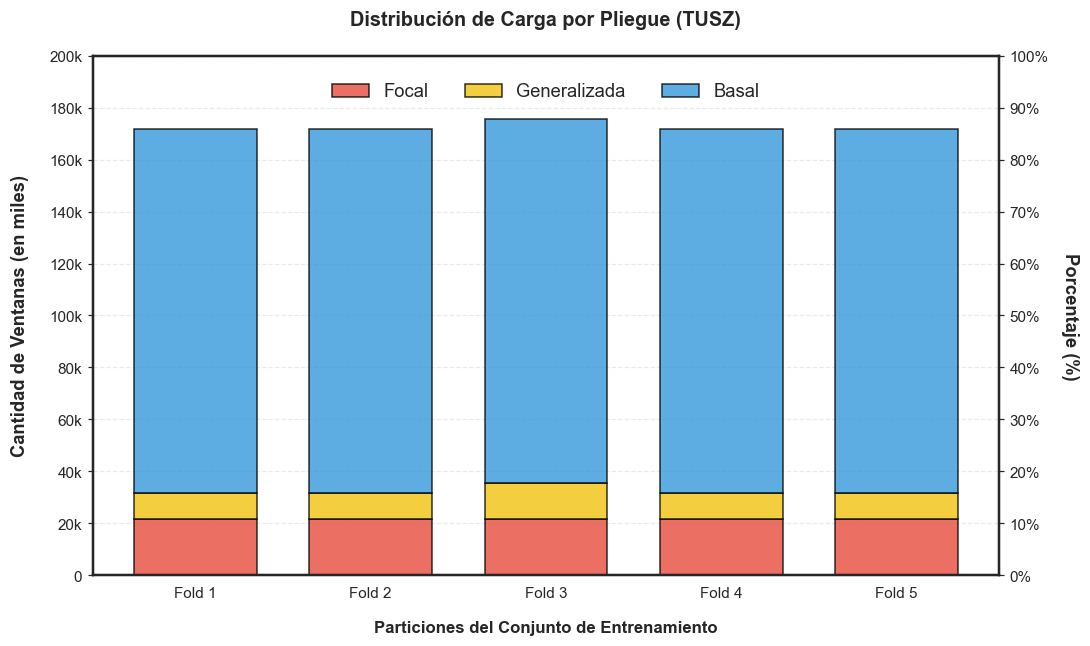

In [187]:
plt.rcParams.update({
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'font.family': 'sans-serif'
})
sns.set_style("white")

df_plot = df_audit[df_audit['Pliegue'] != 'Total Global'].copy()

def extract_count(val):
    if isinstance(val, str):
        return int(val.split(' ')[0].replace(',', ''))
    return val

focal_vals = df_plot['Ventanas Focal'].apply(extract_count).values
gen_vals = df_plot['Ventanas Gen'].apply(extract_count).values
basal_vals = df_plot['Ventanas Basal'].apply(extract_count).values
folds = df_plot['Pliegue'].values

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx() 

colors_c = ['#e74c3c', '#f1c40f', '#3498db']
y_limit = 200000 

# Dibujar barras apiladas
ax.bar(folds, focal_vals, label='Focal', color=colors_c[0], edgecolor='black', alpha=0.8, width=0.7)
ax.bar(folds, gen_vals, bottom=focal_vals, label='Generalizada', color=colors_c[1], edgecolor='black', alpha=0.8, width=0.7)
ax.bar(folds, basal_vals, bottom=focal_vals + gen_vals, label='Basal', color=colors_c[2], edgecolor='black', alpha=0.8, width=0.7)

ax.set_ylim(0, y_limit)
ax.set_yticks(np.arange(0, 200001, 25000))
ax.set_yticks(np.arange(0, 200001, 20000)) 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}k' if x != 0 else '0'))
ax.set_ylabel("Cantidad de Ventanas (en miles)", fontsize=12, fontweight='bold', labelpad = 13)
ax.set_xlabel("Particiones del Conjunto de Entrenamiento", fontsize=11, fontweight='bold', labelpad=13)

ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
ax2.set_ylabel("Porcentaje (%)", fontsize=12, fontweight='bold', rotation=270, labelpad=20)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

ax.set_title("Distribución de Carga por Pliegue (TUSZ)", fontsize=13, fontweight='bold', pad=20)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False, fontsize=12)

for spine in ax.spines.values():
    spine.set_visible(True)
ax2.spines['right'].set_visible(True)
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
plt.close(fig)
data = base64.b64encode(buf.getbuffer()).decode("ascii")

display(HTML(f"""
<div style="text-align: center; width: 100%; margin-top: 20px;">
    <img src="data:image/png;base64,{data}" style="border: 1px solid #ddd; padding: 5px; border-radius: 5px;">
</div>
"""))

## Diseño de Muestreo Estratificado

Experiencias previas en el procesamiento del corpus TUSZ evidenciaron que el uso de la totalidad de las ventanas por pliegue generaba una carga computacional excesiva y degradaba el rendimiento de los modelos debido a la redundancia informativa. Por consiguiente, con el fin de viabilizar los experimentos computacionales dentro del desarrollo del pipeline de clasificación de crisis, se determinó realizar un submuestreo de $n \approx 40,000$ unidades por partición. Esta cifra, basada en la heurística de Harrell, permitió alcanzar un ratio de 37 observaciones por predictor para un espacio de 1,087 características, lo que facilitó la convergencia algorítmica con un margen de error proyectado inferior al 1% de la desviación estándar de los descriptores.

La ejecución de este esquema se realizó mediante un muestreo estratificado anidado por paciente para asegurar la preservación de la integridad clínica y mitigar el riesgo de sesgo por información compartida (*data leakage*). Esta reducción se aplicó exclusivamente en la fase de entrenamiento de cada pliegue, mientras que la validación final y la evaluación del desempeño se efectuaron sobre el conjunto de prueba íntegro. De este modo, el submuestreo operó como una estrategia de eficiencia estadística que facilitó la exploración de diversas arquitecturas sin comprometer la representatividad de los resultados obtenidos en el proyecto.

:::{admonition} Nota Metodológica: Error de Muestreo y Representatividad:class: note
Considerando cada pliegue de entrenamiento como una población finita de $N \approx 515,400$ unidades, el margen de error ($E$) se calcula mediante la fórmula de error estándar con factor de corrección:

$$E = z \cdot \frac{\sigma}{\sqrt{n}} \cdot \sqrt{\frac{N - n}{N - 1}} \approx 0.0094 \cdot \sigma$$

Bajo esta formulación ($z = 1.96$), el margen de error representa menos del 1% de la desviación estándar ($\sigma$) de cualquier variable, lo que permite capturar la varianza de los descriptores independientemente de su escala original. Dado el volumen de $n$, la distribución muestral de los estimadores se aproxima a la distribución gaussiana, lo que valida el uso de estas aproximaciones estadísticas para representar el comportamiento global del pliegue de entrenamiento sin comprometer la integridad de la señal.:::

## Reducción de Dimensionalidad y Preprocesamiento

Complementariamente al submuestreo, la gestión de la dimensionalidad resulta un factor crítico para el desarrollo del pipeline de clasificación del corpus TUSZ, debido a que algoritmos como k-NN, la regresión logística y el clasificador bayesiano presentan una alta sensibilidad al volumen de características consideradas. Al procesar un espacio de 1,083 variables, la inclusión del Análisis de Componentes Principales (PCA) se establece como una estrategia necesaria para filtrar el ruido de los descriptores neurofisiológicos y mitigar el costo computacional del entrenamiento. 

En los modelos donde se implementa el PCA (con excepción de los modelos basados en arboles), la ventaja de esta técnica se valida experimentalmente al tratar el número de componentes principales como un hiperparámetro optimizable dentro del flujo de trabajo de aprendizaje automático. Este proceso se complementa con el uso de escaladores que normalizan las magnitudes de los descriptores, asegurando que la reducción dimensional capture la varianza más significativa de la señal de EEG.

Un estudio del comportamiento del PCA en cada uno de los pliegues en función del escalador reveló que el RobustScaler presentó una eficiencia de compresión de varianza inconsistente para el corpus TUSZ. Aunque este método explicó rápidamente una mayor proporción de la varianza acumulada, su elevada desviación estándar empírica demostró una inestabilidad técnica que dependió del muestreo específico de cada pliegue. Por el contrario, el StandardScaler se caracterizó por una alta estabilidad pero fue insensible a la estructura de información de la señal, debido a que los valores extremos de voltaje inflaron la desviación estándar global y comprimieron la varianza útil observada en los registros neurofisiológicos.

In [188]:
random_patient = random.choice(train_set_paths)
random_file = random.choice(list(random_patient.glob("*.parquet")))
schema = pq.read_schema(random_file)
all_columns = schema.names
TARGET_COL = 'label'
FEATURE_COLS = [col for col in all_columns if col != TARGET_COL and col not in ['patient_id', 'timestamp', 'partition_id', 'win_start_sec']]

filas_mapa = []
for fold_id, datos_fold in final_folds.items():
    for patient_id in datos_fold['patients']:
        filas_mapa.append({
            'fold_id': fold_id,
            'patient_num_id': str(patient_id)
        })

df_map_fold = pd.DataFrame(filas_mapa)

sample_df = pd.read_parquet(list(train_set_paths[0].glob("*.parquet"))[0])
    

df_numeric = sample_df.select_dtypes(include=[np.number])
cols_ignorar = ['target', 'patient_num_id', 'split_final', 'label', 'win_start_sec']
FEATURE_COLS_CLEAN = [c for c in df_numeric.columns if c not in cols_ignorar]

LABEL_MAPPING = {
    'bckg': 0, 'background': 0,
    'fnsz': 1, 'cpsz': 1, 'spsz': 1, 'focal': 1,
    'gnsz': 2, 'absz': 2, 'tcsz': 2, 'mysz': 2, 'tnsz': 2, 'generalized': 2
}


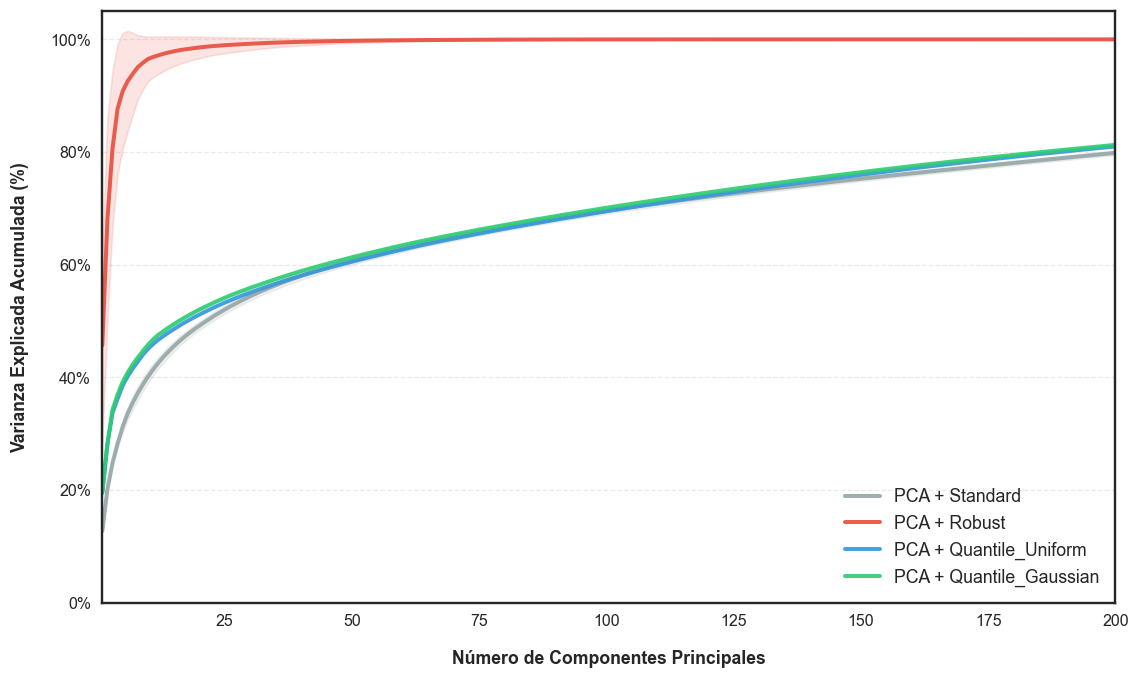

In [22]:
df_pca = get_pca_variance(
    df_map=df_map_fold,
    train_set_paths=train_set_paths,
    feature_cols=FEATURE_COLS_CLEAN, 
    target_col=TARGET_COL,          
    label_mapping=LABEL_MAPPING,    
    n_components=200,
    n_samples=40000,
    seed=42
)

plot_pca_variance_comparison(df_pca)

En este contexto, las variantes del `QuantileTransformer`, tanto uniforme como gaussiana, se identificaron como las técnicas más adecuadas para el pipeline de clasificación de crisis epilépticas. Estos escaladores lograron una mayor captura de varianza en los primeros componentes en comparación con el método estándar, manteniendo una variabilidad mínima entre las particiones de datos. Mientras que el mapeo uniforme permitió neutralizar las asimetrías de los 1,083 descriptores originales mediante un análisis basado en rangos, el mapeo gaussiano resultó particularmente relevante para asegurar la compatibilidad con el clasificador de Bayes integrado en el flujo de trabajo. Ambas configuraciones proporcionaron un hiperespacio de características constante para los modelos de clasificación, garantizando que el rendimiento del sistema fuera independiente de las fluctuaciones individuales de los registros procesados.

Además del impacto de los métodos de escalado, el análisis de la varianza acumulada permitió identificar que el rango óptimo para la hiperparametrización de los componentes del PCA se sitúa entre 100 y 200. Se estableció un límite inferior de 100 componentes para garantizar la captura de al menos el 70% de la varianza total en el procesamiento de las señales EEG, dado que los escaladores basados en cuantiles alcanzan este nivel informativo alrededor de dicha dimensión. Si bien el número definitivo de componentes se ajustará de manera empírica durante la validación del modelo, este intervalo asegura una reducción de dimensionalidad que preserva la integridad de los patrones neurofisiológicos necesarios para la clasificación de crisis.

In [23]:
thresholds = [0.20, 0.40, 0.50, 0.70, 0.80]
scalers = ['Standard', 'Robust', 'Quantile_Uniform', 'Quantile_Gaussian']
summary_data = []

for t in thresholds:
    row = {'Varianza Objetivo': f'{int(t*100)}%'}
    for s in scalers:
        # Buscamos el primer componente que alcance el umbral
        val = df_pca[df_pca[f'{s}_Mean'] >= t]['Componente'].min()
        row[s] = int(val) if pd.notna(val) else ">200"
    summary_data.append(row)

df_thresholds = pd.DataFrame(summary_data)

# 2. Aplicación del estilo solicitado
styled_thresholds = df_thresholds.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                 ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                   ('color', 'black'), ('font-weight', 'bold'),
                                   ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                   ('padding', '10px')]}
])

# Alineación específica
styled_thresholds = styled_thresholds.set_properties(subset=['Varianza Objetivo'], **{'text-align': 'left'})
cols_scalers = ['Standard', 'Robust', 'Quantile_Uniform', 'Quantile_Gaussian']
styled_thresholds = styled_thresholds.set_properties(subset=cols_scalers, **{'text-align': 'center'})

# Renderizado
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_thresholds.to_html() + "</div>"))

Varianza Objetivo,Standard,Robust,Quantile_Uniform,Quantile_Gaussian
20%,2,1,2,2
40%,10,1,6,6
50%,22,2,18,17
70%,104,3,104,100
80%,>200,3,190,186


::: {admonition} Nota Metodológica: Transformación por Cuantiles y su Relación con Spearman:class: note

La transformación por cuantiles es un mapeo no lineal que utiliza la función de distribución acumulada (CDF) para transformar las características originales hacia una distribución objetivo. Para una variable aleatoria $X$ con CDF $F_X(x)$, la transformación se define mediante el método de la transformada inversa:

$$U = F_X(X)$$

En su versión uniforme, el `QuantileTransformer` asigna a cada observación su rango relativo dentro de la muestra, de modo que $U \sim \text{Unif}(0, 1)$. Matemáticamente, para una muestra de tamaño $n$, el valor transformado $x_i$ se aproxima a:

$$\hat{F}_X(x_i) = \frac{\text{rank}(x_i)}{n}$$

Esta técnica establece una conexión directa con la estadística no paramétrica, específicamente con el coeficiente de correlación de rangos de Spearman ($\rho$). Dado que $\rho$ se define como la correlación de Pearson calculada sobre los rangos de las variables, aplicar un PCA sobre datos con escalado uniforme equivale a realizar una descomposición basada en la estructura de covarianza de Spearman. Esto permite capturar relaciones monótonas entre los 1,083 descriptores de la señal EEG sin que la magnitud de los valores extremos o la asimetría de la distribución original, identificadas en el estudio del corpus TUSZ, distorsionen la proyección del hiperespacio.
:::

# Entrenamiento

Una vez definidas la estrategia de segmentación y la técnica de escalado más adecuada para el procesamiento de las señales, se procede a la fase de entrenamiento de los modelos de clasificación. Este proceso se estructura en tres hitos fundamentales: la determinación de la estrategia de balanceo, el estudio comparativo de los marcos de optimización de parámetros y la evaluación final de los modelos. En la primera fase, el objetivo central es identificar el método óptimo para mitigar el marcado desbalance de clases característico del corpus TUSZ. Para ello, se comparará el rendimiento de los modelos mediante el ajuste de pesos en la función de pérdida y el uso de técnicas de sobremuestreo sintético como SMOTE o ADASYN, evaluando su eficacia según la naturaleza de cada algoritmo.

En este proceso, se ha establecido la métrica $F_2$-Score como el eje principal de optimización, una decisión fundamentada en la necesidad crítica de reducir los falsos negativos. En un entorno clínico de monitorización de crisis epilépticas, la omisión de un evento ictal representa un riesgo significativamente mayor para el paciente que la ocurrencia de una falsa alarma. Al seleccionar un valor de $\beta = 2$, se otorga matemáticamente un peso cuatro veces mayor ($\beta^2 = 4$) a la sensibilidad respecto a la precisión, garantizando que el modelo priorice la captura de episodios ictales en escenarios de alta incertidumbre. Complementariamente, se calculará el Índice G como métrica de control, lo que permitirá evaluar el equilibrio global del clasificador frente al desbalance severo de la muestra.

Adicionalmente, se analizará el impacto de diferentes metodologías de optimización de hiperparámetros, incluyendo búsquedas exhaustivas (*Grid Search*), aleatorias (*Random Search*), optimización bayesiana a través de Optuna y algoritmos genéticos mediante DEAP. Dado el considerable volumen de datos manejado en el desarrollo de este pipeline para señales de EEG, la ejecución de estos procesos de manera paralela resulta computacionalmente inviable. Por lo tanto, se ha adoptado un esquema de optimización secuencial: primero se determinará el método más robusto para tratar el desbalance de los datos, posteriormente se procederá con el estudio comparativo de los marcos de optimización y, finalmente, se realizará la evaluación del modelo sobre una muestra independiente de prueba para verificar su capacidad de generalización y robustez final ante la variabilidad biológica de sujetos no observados.

## Modelo logístico

Como primer componente del pipeline de clasificación, se implementa la regresión logística con el fin de establecer un *benchmark* lineal sobre el espacio de características del corpus TUSZ. Este modelo actúa como una referencia de base que permite cuantificar el grado de separabilidad inicial entre los estados clínicos definidos, facilitando la identificación de solapamientos críticos en las densidades de probabilidad de la señal procesada. Su ejecución resulta imperativa para diagnosticar si la estructura del problema admite fronteras de decisión simples antes de transitar hacia arquitecturas de mayor complejidad técnica o capacidad de modelado no lineal. De esta manera, el rendimiento obtenido por este clasificador define el umbral mínimo de eficacia que cualquier modelo posterior de mayor sofisticación debe superar.

In [32]:
scorer = ClassificationScorer(num_classes=3)
metrica_optimizacion = scorer.get_fbeta_score 
metricas_secundarias = {
    'f1_score': lambda y_t, y_p: scorer.get_fbeta_score(y_t, y_p, beta=1),
    'g_index': scorer.get_g_index
}

modelo_logit = get_model(
    'logit', 
    tol=1e-4, 
    max_iter=2000
)

Para la configuración de este modelo inicial, se definió una malla de búsqueda con rangos de PCA desde los $100$ componentes, nivel que captura aproximadamente el $70\%$ de la varianza en los pliegues, hasta el espacio original. Asimismo, la variación del parámetro $C$ y las penalizaciones $L_1$ y $L_2$ permiten explorar distintos grados de regularización y dispersión en los coeficientes, buscando identificar si el control de la complejidad favorece la segregación de la clase ictal ante la alta dimensionalidad del corpus.

In [ ]:
espacios_de_busqueda = {
    'grid': {
        'pca__n_components': [None, 100, 200, 350, 450],
        'clf__C': [0.01, 0.1, 1.0, 5.0],
        'clf__penalty': ['l1', 'l2'],
        'balancing': ['none', 'weight_balanced', 'SMOTE', 'ADASYN']
    }
}

trainer = Trainer(
    df_map=df_map_fold,          
    train_set_paths=train_set_paths, 
    estimator=modelo_logit, 
    scoring_func=metrica_optimizacion,
    secondary_scoring_funcs=metricas_secundarias,
    feature_cols=FEATURE_COLS_CLEAN,
    target_col=TARGET_COL, 
    label_mapping=LABEL_MAPPING
)

dict_tablas, df_bench, dict_conv = trainer.fit(
    methods=['grid'], 
    spaces=espacios_de_busqueda,
    n_trials=20,            
    samples_per_fold=40000, 
    scaler_type='quantile_uniform',
    seed=42
)

In [22]:
RESULTS_PATH = ROOT_DIR / "results" / "logit" / "balancing_analysis" /"logit_balancing_results.csv"

if RESULTS_PATH.exists():
    df_logit_results = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

La evaluación descriptiva de las métricas $F_2$ a través de las diferentes configuraciones de hiperparámetros evidenció marcadas variaciones según la estrategia de balanceo implementada. El clasificador sin técnica de mitigación obtuvo consistentemente los resultados más bajos ($F_2 \approx 0.48$), mientras que la penalización algorítmica mediante pesos logró un incremento notable en el desempeño general ($F_2 \approx 0.52$). Respecto a los métodos de sobremuestreo sintético, ADASYN presentó un rendimiento inferior en comparación con SMOTE, el cual registró sistemáticamente los valores más altos en todas las combinaciones evaluadas ($F_2 \approx 0.54$ en sus mejores puntos). Este comportamiento descriptivo perfila a SMOTE como la estrategia óptima para el manejo del desbalance en este benchmark inicial.

In [20]:
display_balancing_comparison(df_logit_results, metric='F2', sort_by='SMOTE', rename_cols = {'C': 'C',
    'penalty': 'Penalización', 'n_components': 'PCA'})

C,Penalización,PCA,none,weight,SMOTE,ADASYN
0.01,l1,None,0.404 ± 0.027,0.517 ± 0.034,0.544 ± 0.036,0.504 ± 0.029
0.1,l1,None,0.498 ± 0.049,0.506 ± 0.039,0.540 ± 0.033,0.510 ± 0.022
0.01,l2,None,0.495 ± 0.046,0.529 ± 0.033,0.537 ± 0.035,0.509 ± 0.023
0.1,l2,None,0.498 ± 0.045,0.543 ± 0.041,0.535 ± 0.033,0.506 ± 0.023
1.0,l1,None,0.496 ± 0.046,0.499 ± 0.037,0.530 ± 0.034,0.502 ± 0.022


Con el propósito de validar estadísticamente las hipótesis derivadas del análisis descriptivo, se ejecutó una prueba ómnibus de Kruskal-Wallis ($H = 79.070$, $p < 0.001$), revelando un efecto global de gran magnitud sobre el rendimiento del modelo ($\varepsilon^2 = 0.488$). Crucialmente, la prueba de Brown-Forsythe corroboró el cumplimiento del supuesto de homocedasticidad entre los grupos evaluados ($p < 0.001$). De modo que, que las diferencias encontradas pueden interpretarse  inequívocamente como una diferencia real en el parámetro de localización de las distribuciones (en este caso, la mediana de la métrica $F_2$).

Tras confirmar este desplazamiento en las distribuciones, se examinaron las discrepancias específicas mediante comparaciones múltiples post-hoc. El análisis reveló que, si bien la estrategia SMOTE fue estadísticamente superior al ajuste de pesos en la función de costo ($p = 0.008$), la magnitud de esta diferencia se clasifica como un efecto moderado ($r = 0.323$), situándose apenas sobre el umbral de relevancia empírica. Por otro lado, aunque la técnica ADASYN logró superar estadísticamente al modelo base sin mitigación ($p = 0.025$), la magnitud de dicha mejora es marginal ($r = 0.251$), lo que sugiere una eficacia limitada para este clasificador lineal. En contraste, la superioridad de SMOTE frente a ADASYN resultó ser la más robusta de todo el experimento ($r = 0.777$), consolidando a SMOTE como la técnica con mayor capacidad para desplazar positivamente el parámetro de localización de la métrica $F_2$. Estos resultados confirman que, para la arquitectura de regresión logística, la interpolación sintética equilibrada ofrece una ventaja estadística sistemática sobre los métodos de adaptación adaptativa o el simple ajuste de pesos.

In [23]:
df_clean = df_logit_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

Aunque el análisis del $F_2$-score demostró la superioridad estadística de SMOTE, el tamaño del efecto reportado ($r = 0.323$) advirtió que su ventaja empírica sobre el ajuste algorítmico (*weight*) fue moderada. Considerando el sustancial costo computacional y de memoria que exige el sobremuestreo sintético en espacios de alta dimensionalidad frente a la alta eficiencia matemática de la penalización por pesos, resultó necesario evaluar si existía evidencia suficiente que justificara esta carga adicional en el pipeline. Con este propósito, se procedió a examinar el comportamiento del estadístico del Índice G.

La exploración descriptiva de las métricas del Índice G a través de las distintas configuraciones de hiperparámetros reveló un panorama sumamente competitivo. Como era previsible, la configuración base arrojó los valores más deficientes y con la mayor dispersión ($G \approx 0.335$). Asimismo, ADASYN mantuvo un rendimiento inferior y estancado ($G \approx 0.534$). Sin embargo, la convergencia más notable se observó entre la penalización por pesos y SMOTE. A diferencia de la clara ventaja vista en el $F_2$-score, en la evaluación del Índice G ambas técnicas mostraron un desempeño casi equivalente; si bien SMOTE alcanzó el valor máximo absoluto del experimento ($G = 0.580$), el ajuste por pesos exhibió una competitividad constante, situándose en un promedio de $G \approx 0.560$ y superando a SMOTE en estabilidad en algunas celdas. Esta paridad sugiere que la ganancia real de SMOTE en términos de equilibrio global de clases es marginal frente a la simplicidad del ajuste de pesos.

In [26]:
display_balancing_comparison(df_logit_results, metric='G', sort_by='SMOTE', rename_cols = {'C': 'C',
    'penalty': 'Penalización', 'n_components': 'PCA'})

C,Penalización,PCA,none,weight,SMOTE,ADASYN
0.01,l1,None,0.223 ± 0.053,0.557 ± 0.045,0.580 ± 0.051,0.548 ± 0.036
0.01,l2,None,0.376 ± 0.073,0.564 ± 0.047,0.565 ± 0.049,0.549 ± 0.029
0.01,l2,450,0.378 ± 0.070,0.561 ± 0.047,0.563 ± 0.048,0.529 ± 0.031
0.01,l1,350,0.311 ± 0.057,0.552 ± 0.049,0.561 ± 0.046,0.514 ± 0.040
0.1,l2,450,0.387 ± 0.068,0.560 ± 0.047,0.560 ± 0.047,0.529 ± 0.030


Tal como en el caso anterior, la prueba ómnibus de Kruskal-Wallis reveló la existencia de diferencias globales altamente significativas en el rendimiento del Índice G según la estrategia de balanceo evaluada ($H = 124.676$, $p < 0.001$), con un tamaño del efecto de gran magnitud ($\varepsilon^2 = 0.780$). Sin embargo, a diferencia del análisis del $F_2$-score, la prueba de Brown-Forsythe indicó el incumplimiento del supuesto de homocedasticidad ($p = 0.002$). Esta falta de homogeneidad en las varianzas implica que el efecto global detectado refleja una dominancia estocástica entre las distribuciones; por lo tanto, no es posible asegurar que todas las discrepancias se deban de forma exclusiva a desplazamientos en el parámetro de localización.

Al examinar los resultados post-hoc, los datos revelan que la diferencia de rendimiento entre la penalización por pesos y SMOTE no fue estadísticamente significativa ($p = 0.516$), presentando un tamaño del efecto prácticamente nulo ($r = 0.073$). Esta equivalencia estadística directa contrasta con la ventaja que SMOTE exhibió previamente y se explica por el rigor del Índice G, el cual exige un equilibrio multiplicativo entre sensibilidad y especificidad. Mientras que SMOTE empuja agresivamente la frontera de decisión para maximizar el Recall (favoreciendo el $F_2$), dicha ganancia se ve neutralizada en el Índice G por el incremento proporcional de falsos positivos. En consecuencia, se concluye que la complejidad computacional del sobremuestreo sintético no ofrece una mejora sustancial en el equilibrio global de las clases frente a la eficiencia del ajuste de pesos para este clasificador base.

In [28]:
tabla_posthoc(df_clean, metric_col='g_index_center')

En general, los resultados demostraron que tanto la penalización por pesos como la generación sintética mediante SMOTE constituyen estrategias altamente competitivas para el manejo del desbalance en este benchmark. Al inspeccionar la distribución del $F_2$-score, se observó que, si bien la dispersión intercuartílica de ambas técnicas es comparable, SMOTE registró un rendimiento superior y estadísticamente significativo. Aunque el ajuste de pesos ofrece una eficiencia algorítmica ideal e iguala el equilibrio estructural medido por el Índice G, la necesidad clínica de maximizar la sensibilidad frente a la clase minoritaria justifica priorizar la ventaja demostrada por SMOTE en el $F_2$-score. Dado que el modelo final operará bajo un esquema de inferencia estática sin requerir reentrenamiento continuo, el costo computacional del sobremuestreo se asume como una carga exclusiva y aceptable de la fase de entrenamiento; en consecuencia, se consolida a SMOTE como la estrategia óptima para proceder con la evaluación formal de los esquemas de optimización.


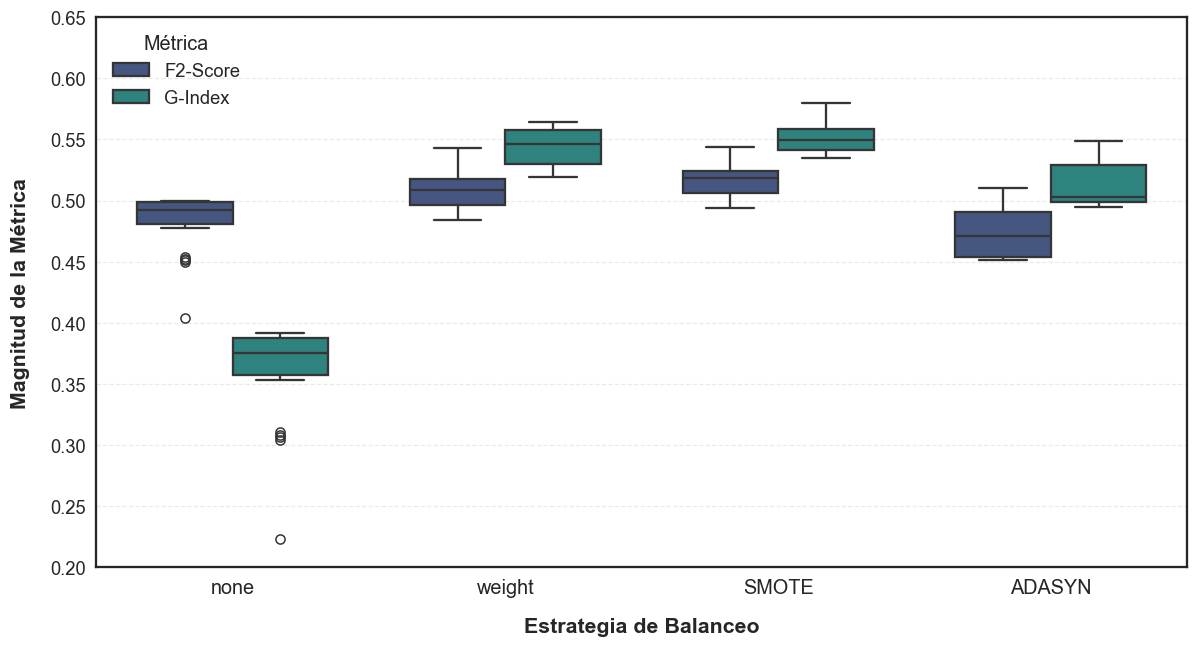

In [29]:
plot_balancing_comparison_dual(
    df=df_logit_results, 
    metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'],           
    y_lim=(0.20, 0.65)                           
)

En esta segunda fase del análisis, se evaluó el impacto de diversos algoritmos de optimización sobre el desempeño del clasificador, con el objetivo de refinar los hiperparámetros identificados en la etapa inicial del estudio. Este proceso de sintonización fina permitió explorar con mayor precisión la superficie de respuesta del modelo, buscando no solo maximizar la sensibilidad clínica medida a través del $F_2$-Score, sino también garantizar un equilibrio robusto frente al desbalance de clases mediante el Índice $G$. Al contrastar métodos exhaustivos como el Grid Search con aproximaciones heurísticas y bayesianas como Optuna, se determinó la configuración que mejor se adapta a la naturaleza estocástica de los registros electroencefalográficos del corpus TUSZ, consolidando así una base técnica sólida para las etapas posteriores del pipeline de detección de eventos ictales.

In [ ]:
modelo_logit = get_model('logit', use_gpu=True, random_state=42, tol=1e-3, max_iter=10000)

espacios_de_busqueda_logit = {
    'grid': {
        'pca__n_components': [None, 50, 100, 300, 600, 800],
        'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'clf__penalty': ['l2', 'l1'],
        'balancing': ['SMOTE']
    },

    'optuna': {
        'pca__n_components': [None, 50, 100, 300, 600, 800],
        'clf__C': (1e-4, 1e2, 'log'),
        'clf__penalty': ['l2', 'l1'],
        'balancing': ['SMOTE']
    }
}

espacios_de_busqueda_logit['random'] = espacios_de_busqueda_logit['optuna']
espacios_de_busqueda_logit['genetic'] = espacios_de_busqueda_logit['optuna']

metodos_a_ejecutar = ['grid', 'optuna', 'random', 'genetic']

trainer_logit = Trainer(
    df_map=df_map_fold,
    train_set_paths=train_set_paths,
    estimator=modelo_logit,
    scoring_func=metrica_optimizacion,
    secondary_scoring_funcs=metricas_secundarias,
    feature_cols=FEATURE_COLS_CLEAN,
    target_col=TARGET_COL,
    label_mapping=LABEL_MAPPING
)

dict_tablas_logit, df_bench_logit, dict_conv_logit = trainer_logit.fit(
    methods=metodos_a_ejecutar,
    spaces=espacios_de_busqueda_logit,
    n_trials=80,
    patience=20,
    tol=1e-3,
    samples_per_fold=40000,
    scaler_type='quantile_uniform',
    seed=42,
    checkpoint_dir=checkpoint_path,
    checkpoint_level='pca'
)


In [30]:
RESULTS_PATH = ROOT_DIR / "results" / "logit" / "optimization_results" / "logit_benchmark_summary.csv"

if RESULTS_PATH.exists():
    df_bench = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

optuna_path = ROOT_DIR / "results" / "logit" / "optimization_results" / "logit_optuna_details.csv"

if optuna_path.exists():
    df_optuna = pd.read_csv(optuna_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {optuna_path}")

grid_path = ROOT_DIR / "results" / "logit" / "optimization_results" / "logit_grid_details.csv"

if grid_path.exists():
    df_grid = pd.read_csv(grid_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {grid_path}")

El análisis de la dinámica de optimización reveló que, si bien Optuna logró identificar el punto de desempeño más alto del experimento ($F_2 = 0.518$), el método Grid Search presentó una superioridad operativa contundente. Esta ventaja en la velocidad de procesamiento se explica por la implementación de una arquitectura de bucle inverso, la cual permitió ajustar múltiples configuraciones del modelo reutilizando el cálculo del PCA en cada bloque de hiperparámetros. Dado que la extracción de componentes principales representó el cuello de botella con mayor carga computacional del pipeline, evitar su recalculo recurrente otorgó una ventaja crítica al método exhaustivo, siendo un $51\%$ más rápido en tiempo total que la optimización bayesiana.

En contraste, la naturaleza secuencial de los optimizadores dirigidos obligó a ejecutar el flujo completo en cada ensayo, lo que incrementó el costo temporal por evaluación. Al analizar la eficacia operativa (definida como la razón entre el tiempo total y el número de evaluaciones), Grid Search resultó ser aproximadamente 2.4 veces más eficiente que Optuna ($7.59$ s/eval frente a $18.30$ s/eval). No obstante, la optimización bayesiana demostró una mayor inteligencia de búsqueda al localizar un máximo que la malla predefinida no alcanzó. Por su parte, el algoritmo genético (DEAP) requirió un $8\%$ más de tiempo total que Optuna sin lograr la convergencia hacia un resultado superior, lo que, sumado a su costo operativo de $12.70$ s/eval, sugiere que su implementación no es recomendable frente a la robustez y precisión de Optuna para este espacio de búsqueda.

In [32]:
df_bench = df_bench.rename(columns={'execution_time_sec': 'execution_time_sec','best_score_center': 'best_score'})
columnas_requeridas = ['optimization_method', 'execution_time_sec', 'total_evaluations', 'best_score', 'early_stopped']
df_bench = df_bench[columnas_requeridas]
display_optimization_benchmark(df_bench)

Método de Optimización,Tiempo,Evaluaciones Totales,Mejor Score (F2),Convergencia
Grid Search,00:37:59,300,0.516,---
Búsqueda Aleatoria,03:10:53,400,0.515,---
Optuna,01:17:47,255,0.518,Sí
DEAP,01:24:39,400,0.515,No


La búsqueda exhaustiva refinada ratificó que el desempeño óptimo ($F_2 = 0.516$; $G = 0.530$) depende de la máxima disponibilidad de información latente, priorizando el uso de 800 componentes de PCA junto a una penalización $l_1$ ($C = 0.1$). Esta configuración de alta dimensionalidad regularizada superó incluso a la omisión de reducción de varianza, lo que sugiere que este nivel de compresión de componentes actúa como el punto de operación ideal para capturar la complejidad de los eventos ictales, permitiendo una sensibilidad clínica superior sin saturar la capacidad de generalización del clasificador.

In [36]:
display_detailed_metrics(df_grid, sort_by='F2', rename_cols = {'C': 'C',
    'penalty': 'Penalización', 'n_components': 'PCA', 'balancing': 'Balanceo',
    'primary': 'F2', 'f1_score': 'F1', 'g_index':'Índice G'})

C,Penalización,PCA,F2,F1,Índice G
0.1,l1,800,0.516 ± 0.030,0.488 ± 0.025,0.530 ± 0.049
1,l1,800,0.514 ± 0.029,0.486 ± 0.023,0.529 ± 0.046
1,l1,---,0.514 ± 0.031,0.482 ± 0.025,0.532 ± 0.049
0.1,l2,800,0.514 ± 0.030,0.485 ± 0.025,0.529 ± 0.049
10,l1,800,0.513 ± 0.029,0.485 ± 0.023,0.528 ± 0.046


Por su parte, la optimización mediante Optuna alcanzó el desempeño más alto registrado en el estudio ($F_2 = 0.518$), convergiendo hacia una solución estructuralmente idéntica a la hallada por la búsqueda exhaustiva. Esta paridad entre ambos métodos es fundamental, ya que ratifica que la superficie de respuesta del clasificador presenta una región de estabilidad claramente definida en torno a los 800 componentes de PCA y la penalización $l_1$. Aunque la optimización bayesiana permite una sintonización más exacta de la magnitud de la penalización al operar en un espacio continuo, el hecho de que ambos enfoques coincidan en situar el valor de $C$ cercano a $0.1$ subraya la solidez de dicha configuración. En última instancia, esta convergencia técnica sugiere que la solución identificada representa un máximo local robusto, validando que la arquitectura final captura propiedades intrínsecas de la dinámica de los eventos ictales de manera consistente, independientemente del algoritmo de búsqueda empleado.

In [34]:
display_detailed_metrics(df_optuna, sort_by='F2', rename_cols = {'C': 'C',
    'penalty': 'Penalización', 'n_components': 'PCA', 'balancing': 'Balanceo'})

PCA,C,Penalización,primary,f1_score,g_index
800,0.160274,l1,0.518 ± 0.030,0.489 ± 0.024,0.533 ± 0.048
800,0.154957,l1,0.518 ± 0.030,0.489 ± 0.024,0.533 ± 0.048
800,0.0887912,l1,0.517 ± 0.030,0.488 ± 0.025,0.532 ± 0.048
800,0.144249,l1,0.517 ± 0.030,0.488 ± 0.024,0.532 ± 0.048
800,0.14298,l1,0.517 ± 0.030,0.488 ± 0.024,0.531 ± 0.048


Con el fin de evaluar la capacidad de generalización de la arquitectura propuesta, se tomó como referencia de comparación la configuración que utiliza el vector de características original sin reducción de dimensionalidad (registrada durante la búsqueda de Optuna). Este contraste resultó fundamental para asegurar que, más allá de la métrica obtenida en el entrenamiento, la inclusión del PCA efectivamente promueve la estabilidad del modelo frente a datos no vistos. Dado el riesgo de sobreajuste inherente a la optimización, se contrastó el rendimiento de ambas configuraciones en el conjunto de prueba independiente. El objetivo no fue seleccionar un modelo superior, sino determinar si la proyección de las features hacia un espacio latente de 800 componentes ofrece una solución más robusta y generalizable para la clasificación de eventos ictales en comparación con el uso del set completo de características.

In [ ]:
modelo_base = get_model('logit', use_gpu=True, random_state=42, tol=1e-3, max_iter=10000)

configs = [
    {
        "name": "Logit_C0.1_PCA800",
        "params": {'pca__n_components': 800, 'model__C': 0.1, 'model__penalty': 'l1', 'balancing': 'SMOTE'},
        "scaler": "quantile_uniform"
    },
    {
        "name": "Logit_C1.0_NoPCA",
        "params": {'pca__n_components': None, 'model__C': 1.0, 'model__penalty': 'l1', 'balancing': 'SMOTE'},
        "scaler": "quantile_uniform"
    }
]

resultados_experimentales = {}

for cfg in configs:
    evaluator = Evaluator(train_set_paths=train_set_paths, test_set_paths=test_set_paths, estimator=modelo_base,
        feature_cols=FEATURE_COLS_CLEAN, target_col=TARGET_COL, label_mapping=LABEL_MAPPING)
    
    evaluator.fit(best_params=cfg['params'], scaler_type=cfg['scaler'], samples_for_train=40000,
                  export_path=f"models/{cfg['name']}.joblib")
    
    train_res = evaluator.get_full_probabilities(evaluator.train_set_paths, "Train Global")
    test_res = evaluator.get_full_probabilities(evaluator.test_set_paths, "Test Global")

    resultados_experimentales[cfg['name']] = {
        'thresholds': evaluator.best_thresholds_,
        'train': train_res,
        'test': test_res
    }

In [35]:
EVAL_PATH = ROOT_DIR / "results" / "logit" / "evaluation"

eval_memory = {}
load_eval_data(EVAL_PATH / "model_thresholds.csv", "thresholds")

evaluation_files = [
    ("prob_pca_train", "prob_Logit_C0.1_PCA800_train.csv"),
    ("prob_pca_test",  "prob_Logit_C0.1_PCA800_test.csv"),
    ("prob_nopca_train", "prob_Logit_C1.0_NoPCA_train.csv"),
    ("prob_nopca_test",  "prob_Logit_C1.0_NoPCA_test.csv")
]

for key, filename in evaluation_files:
    load_eval_data(EVAL_PATH / filename, key)

[CARGADO] thresholds                | Registros: 2
[CARGADO] prob_pca_train            | Registros: 862737
[CARGADO] prob_pca_test             | Registros: 370034
[CARGADO] prob_nopca_train          | Registros: 862737
[CARGADO] prob_nopca_test           | Registros: 370034


Evaluación de Capacidad Discriminativa (Curvas ROC) El análisis del rendimiento en el conjunto de prueba inició con la evaluación de las curvas ROC bajo un esquema One-vs-Rest (OvR). Esta estrategia permitió cuantificar de manera aislada la capacidad de ambos modelos para discriminar cada categoría frente al resto de las señales, proporcionando una métrica de robustez ante el ruido intrínseco del corpus TUSZ. Los resultados revelan una convergencia de desempeño casi absoluta entre ambas configuraciones experimentales ($\Delta AUC = 0.001$). Este hallazgo sugiere que la proyección del espacio de características mediante PCA no aporta una ganancia significativa en la capacidad discriminativa del clasificador. 


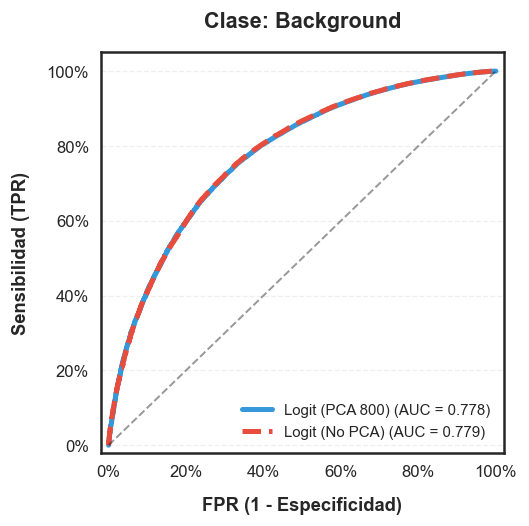

In [56]:
plot_roc_comparison(
    df_m1=eval_memory['prob_pca_test'], 
    df_m2=eval_memory['prob_nopca_test'], 
    name_m1="Logit (PCA 800)", 
    name_m2="Logit (No PCA)", 
    focus_class=[0], 
    figsize=(4.5, 4.5), legend_size=9
)

Este patrón se mantiene consistente al desagregar el análisis por categorías clínicas. Al contrastar el desempeño en la detección de crisis focales ($AUC \approx 0.68$) frente a las generalizadas ($AUC \approx 0.79$), se observa que la jerarquía de discriminación permanece inalterada entre ambas configuraciones. La estabilidad de los valores de AUC a través de las diferentes clases refuerza la hipótesis de que la varianza capturada por el espacio de características original es procesada de forma equivalente por el clasificador, independientemente de la aplicación de una etapa previa de reducción de dimensionalidad.


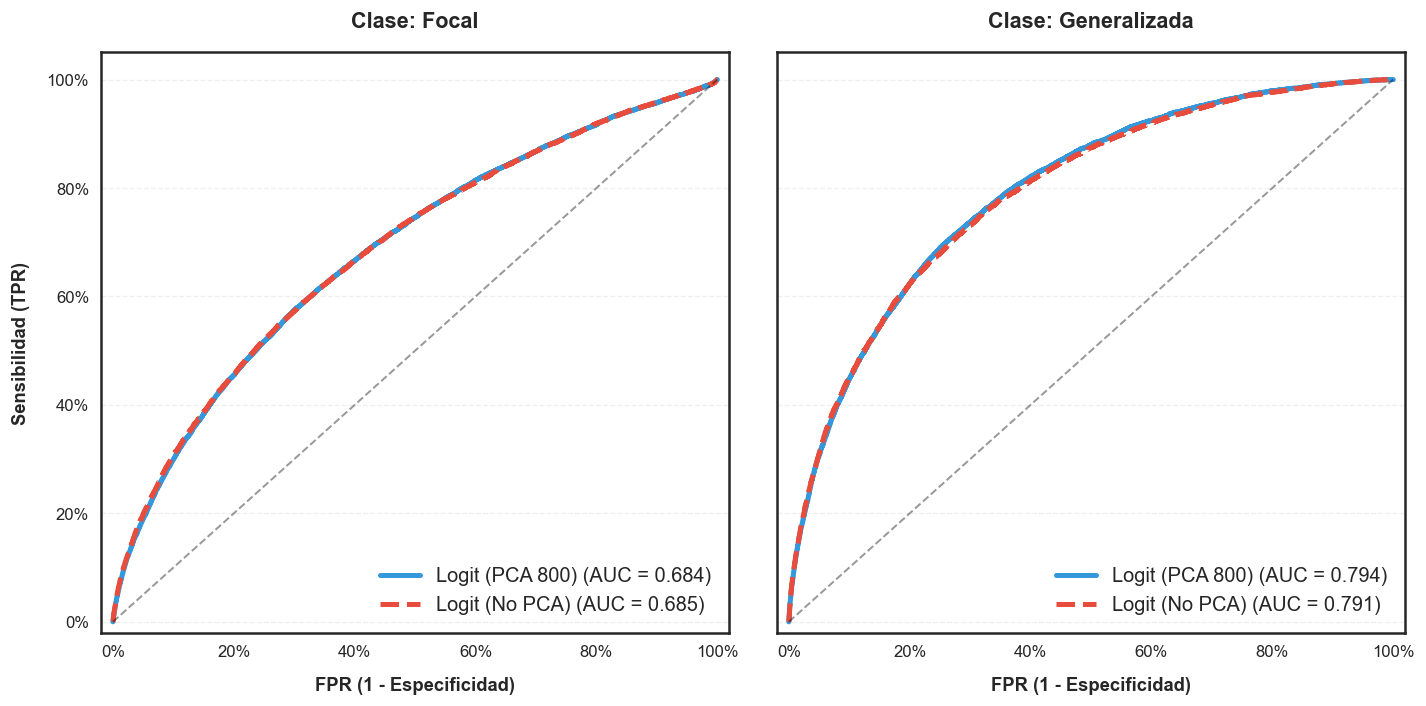

In [59]:
plot_roc_comparison(
    df_m1=eval_memory['prob_pca_test'], 
    df_m2=eval_memory['prob_nopca_test'], 
    name_m1="Logit (PCA 800)", 
    name_m2="Logit (No PCA)", 
    focus_class=[1, 2], 
    figsize=(12, 6), legend_size=12
)

Para someter la hipótesis de equivalencia a comprobación estadística, se aplicó la prueba de DeLong con el objetivo de comparar formalmente las áreas bajo la curva (AUC) de ambas configuraciones. Los resultados revelan un comportamiento heterogéneo: mientras que en la clase Focal no se hallaron diferencias estadísticamente significativas ($p = 0.171$), confirmando una paridad funcional, en las clases Background y Generalizada se observaron discrepancias significativas ($p = 0.030$ y $p < 0.001$, respectivamente).

No obstante, es imperativo matizar estos hallazgos bajo el criterio de parsimonia. Aunque el modelo sin reducción dimensional muestra una ventaja estadística marginal en la detección de fondo ($\Delta AUC = 0.001$) y el modelo con PCA (800) una superioridad similar en crisis generalizadas ($\Delta AUC = 0.003$), estas magnitudes son operativamente irrelevantes. La significancia estadística observada es una consecuencia directa de la alta sensibilidad de la prueba ante el gran volumen de datos del corpus TUSZ, y no refleja una superioridad diagnóstica tangible.

Bajo esta premisa, la decisión final se decanta por la simplicidad del pipeline. Dado que la inclusión de una etapa de PCA no aporta una ganancia en el rendimiento que justifique el aumento en la complejidad del procesamiento y el costo computacional de la transformación, se determina que la arquitectura sin reducción de dimensionalidad es la opción más eficiente y robusta para este clasificador.

In [61]:
compare_models_DeLong(
    df_m1=eval_memory['prob_pca_test'], 
    df_m2=eval_memory['prob_nopca_test'], 
    rename_cols={'Modelo 1': 'Logit (PCA 800)', 'Modelo 2': 'Logit (No PCA)'},
    n_boot=1000
)

Clase,Logit (PCA 800),Logit (No PCA),Diferencia,SE,Z,p,LB,UB
Background,0.778,0.779,-0.001,0.0004,-2.433,0.030*,-0.002,-0.000
Focal,0.684,0.685,-0.001,0.0006,-1.369,0.171,-0.002,0.000
Generalizada,0.794,0.791,0.003,0.0007,3.875,<0.001***,0.001,0.004


Una vez establecida la superioridad de la arquitectura sin reducción de dimensionalidad bajo criterios de parsimonia, el análisis se centró en la calibración clínica del modelo. Es fundamental precisar que dicha calibración se realizó exclusivamente sobre la submuestra de entrenamiento, evitando cualquier fuga de información del conjunto de prueba. Bajo este esquema, se evaluaron dos estrategias de optimización de umbrales: una orientada al balance de precisión y sensibilidad ($F_2$-Score) y otra enfocada en la equidad de detección entre clases (G-Index). Dado que ambas configuraciones presentan métricas de desempeño global similares, resulta imperativo desplazar el análisis hacia las matrices de confusión para determinar el impacto real de cada criterio en la redistribución de los errores de clasificación y en la resolución de la ambigüedad ictal.

In [79]:
display_clinical_results(
    df_prob = eval_memory['prob_nopca_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "Logit_C1.0_NoPCA"
)

Configuración,F2-Score (max),G-Index (max),Tau Focal,Tau Gen
Optimizado para F2,0.4307,0.5039,0.4929,0.5145
Optimizado para G-Index,0.4027,0.5314,0.4264,0.3574


Al analizar la matriz de confusión optimizada bajo el criterio del $F_2$-Score, se identifica un compromiso en la seguridad del clasificador. Dado que la omisión de segmentos con crisis ictales representa un riesgo clínico sustancial, el incremento de los falsos negativos en esta configuración resulta evidente: las crisis focales erróneamente clasificadas como fondo aumentan ($\Delta = +7.3\%$), mientras que en las generalizadas el impacto es aún más marcado ($\Delta = +9.5\%$). Este desplazamiento de las fronteras de decisión sugiere que, a pesar de maximizar el score teórico, el modelo prioriza la especificidad del Background ($\Delta = +5.0\%$) a costa de reducir la sensibilidad ante eventos epilépticos.

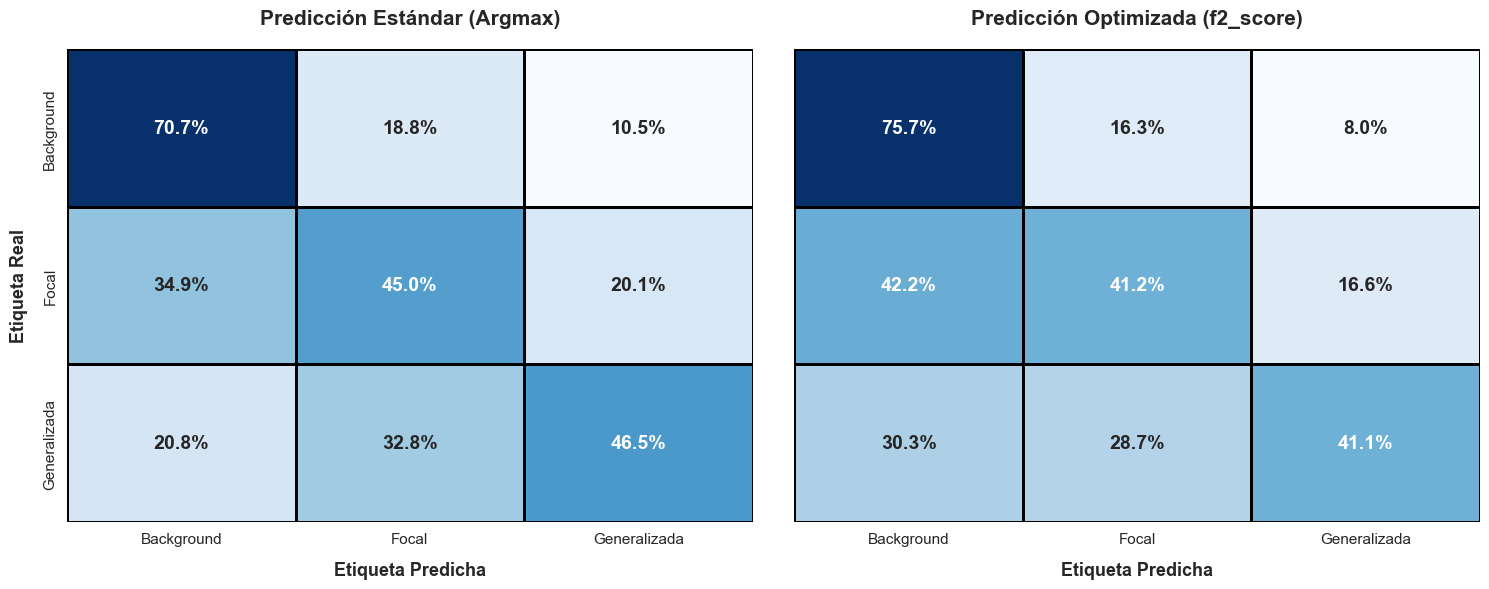

In [25]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_nopca_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "Logit_C1.0_NoPCA",
    metric_type = 'f2_score'
)

Al analizar la matriz de confusión optimizada bajo el criterio del G-Index, se observa un comportamiento mucho más conservador y alineado con los objetivos clínicos. A diferencia de la configuración previa, este ajuste mantiene una estructura similar al Argmax estándar, pero logra una disminución en la tasa de falsos negativos: la clasificación errónea de crisis focales como fondo se reduce ($\Delta=−2.3 \%$), mientras que en las crisis generalizadas la mejora es de ($\Delta=−1.4 \%$). Aunque este avance implica un ligero aumento en los falsos positivos del Background ($\Delta=+3.2 \%$), el G-Index se posiciona como una estrategia de calibración más equilibrada al mejorar la sensibilidad ictal sin comprometer drásticamente la especificidad del modelo.

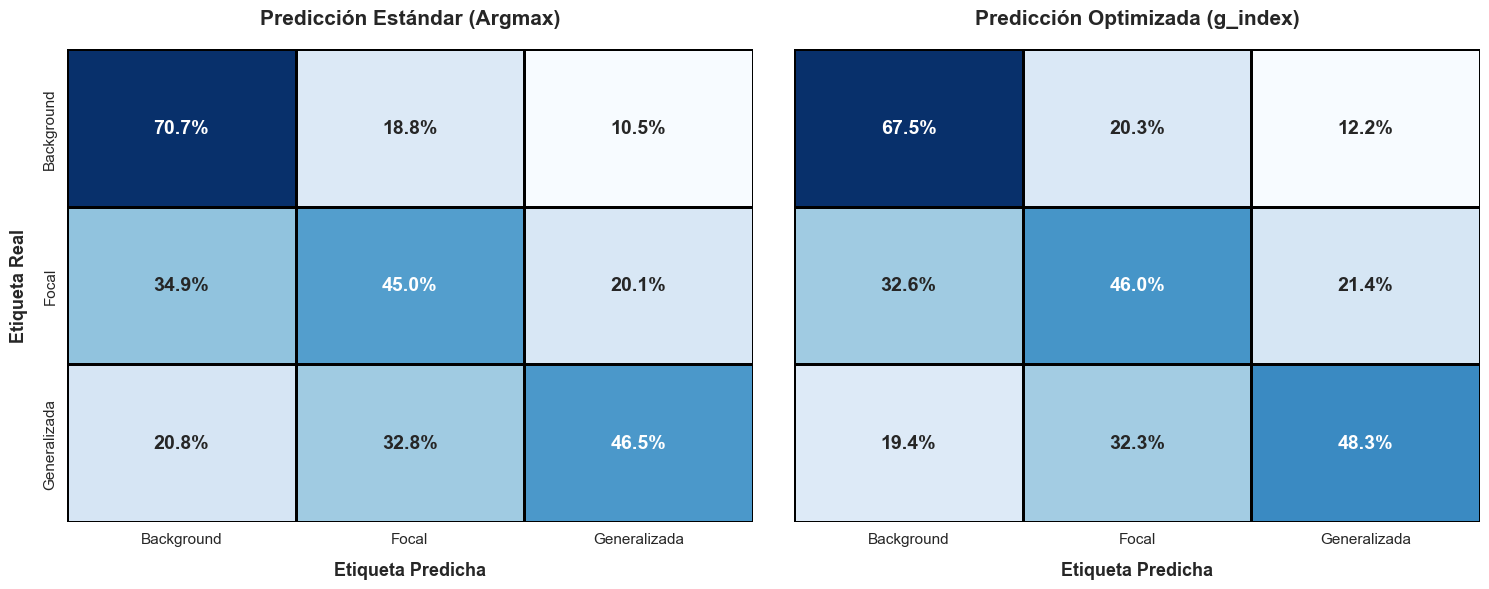

In [24]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_nopca_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "Logit_C1.0_NoPCA",
    metric_type = 'g_index'
)

Al examinar el comportamiento de la arquitectura con regularización $l_1$, se observa un alto rendimiento en la fase de entrenamiento (Accuracy: $0.730$; G-Index: $0.702$), lo que confirma que el modelo logra aprender las estructuras de datos presentes en los pliegues iniciales. Sin embargo, en la fase de prueba se registra una caída marcada en la Sensibilidad ($\Delta = 0.163$) y el F1-Score ($\Delta = 0.217$), mientras que la Especificidad permanece prácticamente inalterada. Esta estabilidad en la especificidad, contrastada con la degradación de la métricas de detección, sugiere que la pérdida de rendimiento no responde a una vulnerabilidad algorítmica por complejidad (sobreajuste clásico), sino a una limitación en la generalización de las firmas neurofisiológicas. La hipótesis planteada es que el clasificador, al enfrentarse a pacientes inéditos en el test, encuentra patrones de señal cuyas manifestaciones ictales difieren de las aprendidas, mientras que la actividad de fondo (background) conserva una estructura más homogénea y reconocible entre sujetos.

In [36]:
display_model_summary(
    df_train = eval_memory['prob_nopca_train'],
    df_test = eval_memory['prob_nopca_test'],
    df_thresholds = eval_memory['thresholds'],
    model_name = "Logit_C1.0_NoPCA",
    scorer = scorer, 
    metric_opt = 'g_index', overfit_threshold=0.1)

Métrica,Entrenamiento,Prueba,Diferencia
Accuracy,0.730,0.663,0.068
Precision,0.543,0.381,0.162†
Recall,0.702,0.539,0.163†
Specificity,0.857,0.799,0.058
G-Index,0.702,0.531,0.170†
F1-Score,0.578,0.360,0.217†
F2-Score,0.634,0.403,0.232†
ROC-AUC,0.872,0.752,0.120†
PR-AUC,0.651,0.395,0.256†


En conclusión, el análisis técnico consolida al modelo con regularización $l_1$ como la configuración óptima. Esta arquitectura destaca por su parsimonia al prescindir de la reducción de dimensionalidad mediante PCA, lo que resulta en un pipeline computacionalmente más ágil sin sacrificar capacidad de generalización. Cabe destacar que tanto la optimización mediante Grid Search como el uso de algoritmos bayesianos vía Optuna convergieron en soluciones equivalentes, validando la estabilidad del espacio de búsqueda para este clasificador.

No obstante, el modelo logístico final muestra un rendimiento aceptable únicamente para la detección general de eventos (crisis vs. fondo). El sistema aún carece de la robustez necesaria para discriminar con precisión entre los subtipos de crisis, lo que limita su utilidad en diagnósticos diferenciales complejos. Esta restricción estructural subraya un margen de mejora considerable y justifica la transición hacia arquitecturas con mayor capacidad para capturar patrones no lineales.

## KNN

Como segundo componente del análisis, se integra el algoritmo de los $k$-vecinos más cercanos ($k$-NN) para explorar la topología geométrica local y las densidades de vecindad dentro del espacio de características. A diferencia del *benchmark* lineal previo, este enfoque no paramétrico permite capturar fronteras de decisión complejas y relaciones no lineales que pueden emerger de la variabilidad morfológica intrínseca de las señales EEG.

La configuración del espacio de búsqueda responde a la necesidad de controlar la dispersión del espacio métrico, factor que afecta directamente la fiabilidad de las medidas de proximidad. Por ello, se evalúa un espectro de reducción de dimensionalidad mediante PCA que varía desde la conservación del espacio original hasta proyecciones de baja dimensión, con el fin de optimizar el contraste entre las distancias de los vecinos más cercanos y los más alejados. La exploración se extiende a diversas métricas de proximidad (Euclidiana, Manhattan y Chebyshev) y esquemas de ponderación por inversa de la distancia, junto con estrategias de decisión basadas en el riesgo esperado y la probabilidad a posteriori (MAP), buscando maximizar la robustez del modelo en la discriminación de los estados clínicos.

In [ ]:
modelo_knn = get_model('knn', use_gpu=True, random_state=42)

espacios_de_busqueda_knn = {
    'grid': {
        'pca__n_components': [None, 50, 100, 400, 600, 800],
        'clf__metric': ['euclidean', 'manhattan', 'chebyshev'],
        'balancing': ['none', 'SMOTE', 'ADASYN'],
        'clf__n_neighbors': [5, 11, 21, 31],
        'clf__voting_weight': ['none', 'inverse_distance'],
        'clf__decision_strategy': ['map', 'expected_risk']
    }
}

trainer_knn = Trainer(
    df_map=df_map_fold,
    train_set_paths=train_set_paths,
    estimator=modelo_knn,
    scoring_func=metrica_optimizacion,
    secondary_scoring_funcs=metricas_secundarias,
    feature_cols=FEATURE_COLS_CLEAN,
    target_col=TARGET_COL,
    label_mapping=LABEL_MAPPING
)

dict_tablas_knn, df_bench_knn, dict_conv_knn = trainer_knn.fit(
    methods=['grid'],
    spaces=espacios_de_busqueda_knn,
    samples_per_fold=40000,
    scaler_type='quantile_uniform',
    seed=42,
    checkpoint_dir=checkpoint_path_knn,
    checkpoint_level='balancing'
)

In [38]:
RESULTS_PATH = ROOT_DIR / "results"/ "knn" / "knn_grid_details_balancing.csv"

if RESULTS_PATH.exists():
    df_knn_results = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

:::{admonition} Nota Metodológica: Ponderación en KNN 
:class: note

A diferencia del modelo de regresión logística, donde el desbalanceo puede mitigarse mediante la asignación de pesos analíticos a la función de pérdida (*class weights*), el algoritmo KNN, por su naturaleza no paramétrica y basada en instancias, no dispone de una métrica de costos integrada en el proceso de entrenamiento. En este modelo, el "aprendizaje" es perezoso (*lazy learning*) y consiste simplemente en el almacenamiento del espacio de características. Por lo tanto, en lugar de ajustar pesos durante un ajuste de parámetros, se evalúa la efectividad de la Ponderación por Inversa de la Distancia (*Distance-Weighted Voting*) durante la fase de inferencia. Bajo este esquema, la influencia de cada vecino en la clasificación final no es uniforme, sino que es inversamente proporcional a su distancia respecto al punto de consulta. Matemáticamente, el peso $w_i$ de un vecino $i$ se define como:

$$w_i = \frac{1}{d(x_q, x_i) + \varepsilon}$$

Donde $d(x_q, x_i)$ representa la distancia entre la consulta y el vecino, y $\epsilon$ es una constante de suavizado para evitar divisiones por cero. Esta estrategia busca que los prototipos de crisis que se encuentran en la vecindad inmediata tengan un impacto superior en la decisión clínica, mitigando la presión estadística de la clase mayoritaria (Basal) cuando esta se encuentra en las periferias del vecindario local.
:::

La evaluación descriptiva de las métricas $F_2$ para el clasificador KNN reveló variaciones significativas en función de la estrategia de balanceo y la configuración de inferencia. El clasificador base registró una alta sensibilidad a la estrategia de decisión; mientras que bajo el enfoque de riesgo esperado sin mitigación el desempeño fue deficiente ($F_2 \approx 0.33$), la implementación de una estrategia Maximum A Posteriori (MAP) con ponderación por inversa de la distancia permitió alcanzar niveles competitivos de eficacia ($F_2 \approx 0.435$). En cuanto a las técnicas de sobremuestreo, ADASYN mostró un rendimiento estable aunque inferior ($F_2 \approx 0.41$), siendo superado de manera sistemática por SMOTE, el cual alcanzó los valores de eficacia más altos del espectro evaluado ($F_2 \approx 0.434$). Este comportamiento sugiere la hipótesis de que, en modelos basados en densidad local, la generación de muestras sintéticas en las fronteras de decisión mediante SMOTE resulta más efectiva que el enfoque de ADASYN, el cual podría estar introduciendo ruido en regiones críticas del espacio de características del corpus TUSZ.

In [39]:
display_balancing_comparison(df_knn_results, metric='F2', sort_by='SMOTE', rename_cols = {'decision_strategy': 'Estrategia',
    'metric': 'Métrica','n_neighbors': 'Vecinos', 'voting_weight': 'Ponderación', 'n_components': 'PCA'})

Estrategia,Métrica,Vecinos,Ponderación,PCA,none,SMOTE,ADASYN
map,euclidean,5,none,50,0.425 ± 0.019,0.434 ± 0.021,0.409 ± 0.017
expected_risk,euclidean,5,none,50,0.332 ± 0.004,0.434 ± 0.021,0.407 ± 0.016
map,euclidean,5,inverse_distance,50,0.435 ± 0.020,0.433 ± 0.020,0.409 ± 0.017
expected_risk,euclidean,5,inverse_distance,50,0.332 ± 0.004,0.433 ± 0.020,0.408 ± 0.016
map,chebyshev,5,none,50,0.404 ± 0.013,0.424 ± 0.021,0.407 ± 0.019


Con el propósito de validar estadísticamente las hipótesis derivadas del análisis descriptivo, se ejecutó una prueba ómnibus de Kruskal-Wallis ($H = 88.939, p < 0.001$), confirmando un efecto global significativo del método de balanceo sobre la distribución de los rangos de desempeño del clasificador $k$-NN ($\varepsilon^2 = 0.101$). Complementariamente, la prueba de Brown-Forsythe reveló la presencia de heterocedasticidad significativa ($p < 0.001$), lo que indica que las estrategias de balanceo no solo desplazan la tendencia central de la métrica $F_2$, sino que también impactan la variabilidad y consistencia del desempeño del modelo ante las diversas morfologías de las señales EEG.

El análisis de las comparaciones múltiples, centrado en la magnitud del efecto, matiza la superioridad de la configuración basal (none) sobre las técnicas de sobremuestreo. Si bien se observó un efecto moderado al contrastar el modelo base con ADASYN ($r = 0.385$), la diferencia frente a SMOTE resultó ser marginal ($r = 0.196$), situándose en un rango de relevancia empírica bajo. Esta proximidad en los tamaños del efecto sugiere que, aunque la preservación de la topología original es estadísticamente preferible, la evidencia no es lo suficientemente contundente para descartar el uso de SMOTE, el cual demostró una ventaja distributiva sobre ADASYN ($r = 0.212$). En conclusión, mientras que ADASYN parece introducir un ruido que compromete la vecindad local, SMOTE se presenta como una alternativa más conservadora que mantiene una competencia estrecha con la configuración basal.

In [40]:
df_clean = df_knn_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

Con el fin de recabar datos adicionales sobre la eficacia de las estrategias frente al desbalanceo, se examinó el comportamiento del Índice G. Al analizar esta métrica, se observa que la brecha de rendimiento entre SMOTE y ADASYN tiende a reducirse, convergiendo en valores cercanos a $0.491$ y $0.466$ respectivamente. Sin embargo, la diferencia respecto al modelo base sin balanceo se acentúa drásticamente, donde configuraciones sin mitigación registran valores críticos cercanos a cero ($G \approx 0.111$). Estos resultados sugieren la hipótesis de que, si bien la elección entre técnicas de sobremuestreo sintético tiene un impacto marginal en la equidad global del modelo $k$-NN, la ausencia de una estrategia de balanceo anula casi por completo la capacidad discriminativa del clasificador entre las distintas clases del corpus TUSZ.

In [41]:
display_balancing_comparison(df_knn_results, metric='G', sort_by='SMOTE', rename_cols = {'decision_strategy': 'Estrategia',
    'metric': 'Métrica','n_neighbors': 'Vecinos', 'voting_weight': 'Ponderación', 'n_components': 'PCA'})

Estrategia,Métrica,Vecinos,Ponderación,PCA,none,SMOTE,ADASYN
map,manhattan,21,none,50,0.183 ± 0.035,0.491 ± 0.031,0.466 ± 0.023
map,manhattan,21,inverse_distance,50,0.193 ± 0.036,0.491 ± 0.031,0.466 ± 0.023
expected_risk,manhattan,21,none,50,0.010 ± 0.005,0.491 ± 0.031,0.464 ± 0.022
map,manhattan,31,none,50,0.163 ± 0.034,0.491 ± 0.030,0.462 ± 0.021
expected_risk,manhattan,21,inverse_distance,50,0.010 ± 0.006,0.491 ± 0.031,0.466 ± 0.023


Al desplazar el análisis hacia el Índice G, la prueba ómnibus de Kruskal-Wallis reveló un efecto global de gran magnitud sobre la distribución del desempeño del modelo ($H = 237.632$, $\varepsilon^2 = 0.274$). Este incremento sustancial en el tamaño del efecto, en comparación con lo observado en la métrica $F_2$, subraya que la estrategia de balanceo actúa como el factor determinante en la capacidad del clasificador para reconocer las clases minoritarias. Asimismo, la prueba de Brown-Forsythe confirmó la presencia de heterocedasticidad significativa ($p < 0.001$), validando que la ausencia de balanceo no solo desplaza la tendencia central, sino que induce una inestabilidad estructural en la equidad predictiva del modelo.

El análisis de las comparaciones múltiples confirmó una superioridad estocástica definitiva de las técnicas de sobremuestreo frente a la configuración basal (none). La magnitud del efecto alcanzó niveles de relevancia elevados tanto para SMOTE ($r = 0.574$) como para ADASYN ($r = 0.506$), evidenciando que la mitigación del desbalanceo transforma radicalmente la estructura de decisión del clasificador. En contraste, al comparar SMOTE frente a ADASYN, la magnitud de la diferencia se redujo a un rango de relevancia marginal ($r = 0.194$). Estos resultados demuestran que para el clasificador $k$-NN, la implementación de cualquiera de estas técnica de sobremuestreo constituye un requisito crítico para garantizar la equidad predictiva, siendo la decisión de mitigar el desbalanceo mucho más impactante que la elección específica del algoritmo de síntesis.

In [42]:
tabla_posthoc(df_clean, metric_col='g_index_center')

En síntesis, los resultados obtenidos para el clasificador KNN demuestran que, aunque el impacto de las estrategias de balanceo sobre la métrica $F_2$ es limitado, su influencia se vuelve crítica al evaluar el Índice $G$, donde el incremento en la equidad predictiva es de gran magnitud. En términos comparativos, tanto ADASYN como SMOTE mostraron un comportamiento general similar en todas las dimensiones analizadas. No obstante, dado que SMOTE alcanzó consistentemente las métricas más elevadas y presenta una complejidad algorítmica menor en comparación con el enfoque de densidad de ADASYN, se selecciona como la estrategia óptima para este componente del pipeline. Esta elección garantiza un equilibrio eficiente entre la robustez estadística y la carga computacional requerida para el procesamiento de las señales del corpus TUSZ


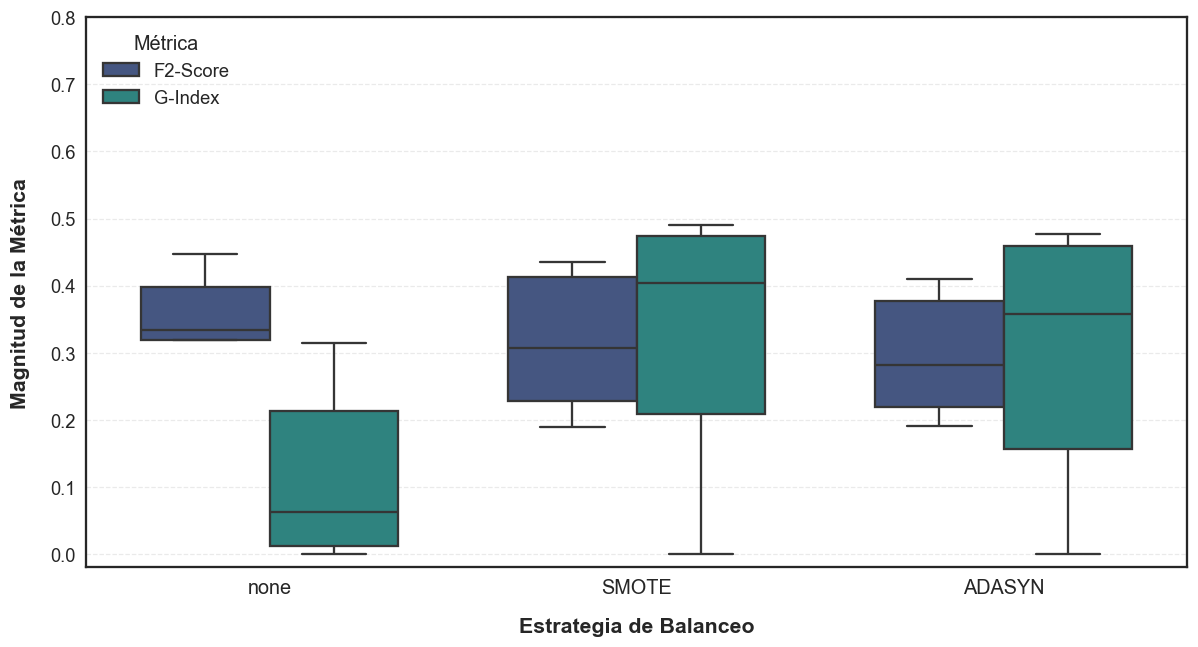

In [46]:
plot_balancing_comparison_dual(df=df_knn_results, metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'], y_lim=(-0.02, 0.8))

In [28]:
RESULTS_PATH = ROOT_DIR / "results" / "knn" / "optimization_results" / "tabla_bench.csv"

if RESULTS_PATH.exists():
    df_bench = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

optuna_path = ROOT_DIR / "results" / "knn" / "optimization_results" / "tabla_global_optuna.csv"

if optuna_path.exists():
    df_optuna = pd.read_csv(optuna_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {optuna_path}")

grid_path = ROOT_DIR / "results" / "knn" / "optimization_results" / "tabla_global_grid.csv"

if grid_path.exists():
    df_grid = pd.read_csv(grid_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {grid_path}")

El análisis de la dinámica de optimización reveló que, si bien el método Grid Search identificó el punto de desempeño más alto del experimento ($F_2 = 0.452$), este presentó una superioridad operativa contundente. Al evitar el recálculo recurrente del PCA, el método exhaustivo registró una eficacia operativa de $5.92$ s/eval, resultando aproximadamente 4 veces más eficiente por unidad de evaluación que la optimización bayesiana de Optuna ($23.81$ s/eval). No obstante, Optuna demostró una mayor inteligencia de búsqueda al localizar un máximo competitivo ($F_2 = 0.449$) requiriendo apenas el 4.4% de las evaluaciones totales realizadas por la malla.

En contraste, la naturaleza secuencial de los optimizadores dirigidos incrementó drásticamente el costo temporal por ensayo. Es notable que el algoritmo genético (DEAP) no solo registró el desempeño más bajo del estudio ($F_2 = 0.439$), sino que su capacidad de exploración fue superada incluso por la Búsqueda Aleatoria, la cual alcanzó un score superior ($F_2 = 0.446$) con el mismo número de evaluaciones. Este estancamiento de DEAP, sumado a una eficacia operativa de $20.65$ s/eval que no condujo a la convergencia, invalida su implementación para este espacio de búsqueda frente a la precisión y ahorro de recursos que ofrece la optimización de Optuna.

In [29]:
df_bench = df_bench.rename(columns={'execution_time_sec': 'execution_time_sec','best_score_center': 'best_score'})
columnas_requeridas = ['optimization_method', 'execution_time_sec', 'total_evaluations', 'best_score', 'early_stopped']
df_bench = df_bench[columnas_requeridas]
display_optimization_benchmark(df_bench)

Método de Optimización,Tiempo,Evaluaciones Totales,Mejor Score (F2),Convergencia
Grid Search,02:57:34,1800,0.452,---
Búsqueda Aleatoria,01:51:28,300,0.446,---
Optuna,00:31:45,80,0.449,Sí
DEAP,01:43:14,300,0.439,No


A pesar de la superioridad operativa de la malla exhaustiva, los hallazgos revelan que la reducción de la dimensionalidad fue el factor crítico para elevar el desempeño del modelo. Mientras que configuraciones con un espacio latente más amplio mostraron rendimientos inferiores, la contracción del espacio a 25 componentes de PCA permitió alcanzar el máximo nominal de $F_2 = 0.452$. Este comportamiento sugiere que una estructura de características más compacta mitiga el ruido intrínseco de las señales EEG, favoreciendo una frontera de decisión más estable. Es notable que este rendimiento óptimo se alcanzó con una configuración de 5 vecinos y distancia Euclidiana, demostrando que, para este volumen de datos, la simplicidad métrica favorece la identificación de patrones locales de crisis.

Por otro lado, se observó que la transición hacia la distancia Manhattan con un aumento a 10 vecinos propició un incremento en el Índice G ($\Delta = +0.016$), alcanzando un valor de $0.488$. Si bien este ajuste registró reducciones marginales en el resto de las métricas ($\Delta F_2 = -0.001$ y $\Delta F_1 = -0.005$), la ganancia en la equidad de la sensibilidad compensa estas pérdidas. Dado que las métricas de la familia $F$ se ven penalizadas por la precisión en un contexto de alto desbalance, el Índice G refleja una capacidad discriminativa más pura entre clases. En consecuencia, se prioriza la configuración con distancia Manhattan por su robustez clínica, garantizando un sistema que, bajo principios de parsimonia, ofrece un desempeño superior y más equilibrado en el reconocimiento de eventos ictales.

In [30]:
display_detailed_metrics(df_grid, sort_by='F2', rename_cols = {'decision_strategy': 'Estrategia',
    'metric': 'Métrica','n_neighbors': 'Vecinos', 'voting_weight': 'Ponderación', 'n_components': 'PCA',
                                                               'primary': 'F2', 'f1_score': 'F1', 'g_index':'Índice G'})

Estrategia,Métrica,Vecinos,Ponderación,PCA,F2,F1,Índice G
map,euclidean,5,none,25,0.452 ± 0.025,0.426 ± 0.018,0.472 ± 0.046
expected_risk,euclidean,5,none,25,0.452 ± 0.025,0.426 ± 0.018,0.472 ± 0.046
map,manhattan,10,none,25,0.451 ± 0.024,0.421 ± 0.018,0.488 ± 0.043
expected_risk,manhattan,10,none,25,0.451 ± 0.024,0.421 ± 0.018,0.488 ± 0.043
expected_risk,euclidean,5,inverse_distance,25,0.451 ± 0.025,0.424 ± 0.018,0.472 ± 0.045


Finalmente, resulta notable la convergencia observada en el proceso de optimización mediante Optuna, la cual identificó una solución altamente competitiva y alineada con los hallazgos del Grid Search. En esta exploración, el algoritmo bayesiano localizó un punto de desempeño con 12 vecinos y distancia Manhattan ($F_2 = 0.449$ e Índice $G = 0.490$), reforzando la validez del espacio de búsqueda seleccionado. No obstante, se confirmó que el incremento adicional en el Índice $G$ bajo esta configuración es marginal y comienza a generar un descenso en la métrica $F_2$, que cae por debajo del máximo nominal de $0.452$. Esta consistencia entre los métodos estocásticos y exhaustivos no solo valida la robustez de los resultados, sino que confirma que el modelo ha alcanzado un límite de optimización donde ganancias adicionales en la equidad predictiva comprometen la estabilidad de la métrica principal en el corpus TUSZ.

In [31]:
display_detailed_metrics(df_optuna, sort_by='F2', rename_cols = {'decision_strategy': 'Estrategia',
    'metric': 'Métrica','n_neighbors': 'Vecinos', 'voting_weight': 'Ponderación', 'n_components': 'PCA',
                                                               'primary': 'F2', 'f1_score': 'F1', 'g_index':'Índice G'})

PCA,Vecinos,Métrica,Ponderación,Estrategia,F2,F1,Índice G
25,12,manhattan,none,map,0.449 ± 0.023,0.418 ± 0.017,0.490 ± 0.042
25,50,manhattan,none,map,0.442 ± 0.022,0.407 ± 0.019,0.507 ± 0.036
25,42,manhattan,none,map,0.441 ± 0.022,0.408 ± 0.019,0.505 ± 0.036
25,48,manhattan,none,map,0.441 ± 0.022,0.407 ± 0.019,0.506 ± 0.036
25,49,manhattan,none,map,0.440 ± 0.022,0.405 ± 0.019,0.506 ± 0.036


En resumen, el análisis detallado de los resultados revela que los diversos métodos de optimización convergieron hacia soluciones significativamente similares, lo que valida la estabilidad del espacio de búsqueda definido y la robustez de los hallazgos. Si bien el Grid Search permitió identificar regiones del hiperespacio que maximizan de forma marginal el $F_2$ ($0.452$), el equilibrio alcanzado mediante el Índice $G$ sugiere una configuración más balanceada y ética para la detección clínica en entornos reales.

En cuanto a la reducción de dimensionalidad, los datos sugieren que, aunque una contracción adicional de los componentes del PCA podría incrementar teóricamente las métricas de desempeño, esto implicaría una pérdida sustancial de la varianza explicada. Priorizar una optimización numérica extrema sobre la riqueza de la señal original comprometería la interpretabilidad del modelo. Dadas las limitaciones estructurales del algoritmo $k$-NN para capturar la complejidad de las crisis en el corpus TUSZ, se optó por fijar el límite en 25 componentes para preservar una representación mínima pero suficiente de la información ictal, garantizando un balance entre parsimonia y fidelidad fisiológica.

In [23]:
modelo_knn = get_model('knn', use_gpu=True, random_state=42)
configs_knn = [
    {
        "name": "KNN_K10_PCA25_Manhattan",
        "params": {
            'pca__n_components': 25,
            'model__n_neighbors': 10,
            'model__metric': 'manhattan',
            'model__weights': 'uniform',
            'model__decision_strategy': 'map',
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_uniform"
    },
    {
        "name": "KNN_K50_PCA25_Manhattan",
        "params": {
            'pca__n_components': 25,
            'model__n_neighbors': 50,
            'model__metric': 'manhattan',
            'model__weights': 'uniform',
            'model__decision_strategy': 'map',
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_uniform"
    }
]

resultados_knn = {}

for cfg in configs_knn:
    evaluator = Evaluator(
        train_set_paths=train_set_paths,
        test_set_paths=test_set_paths,
        estimator=modelo_knn,
        feature_cols=FEATURE_COLS_CLEAN,
        target_col=TARGET_COL,
        label_mapping=LABEL_MAPPING
    )

    evaluator.fit(best_params=cfg['params'], scaler_type=cfg['scaler'],
        samples_for_train=40000, export_path=f"models/{cfg['name']}.joblib")
    
    train_res = evaluator.get_full_probabilities(evaluator.train_set_paths, "Train Global")
    test_res = evaluator.get_full_probabilities(evaluator.test_set_paths, "Test Global")

    resultados_knn[cfg['name']] = {
        'thresholds': evaluator.best_thresholds_,
        'train': train_res,
        'test': test_res
    }

In [38]:
EVAL_PATH = ROOT_DIR / "results" / "knn" / "evaluation"

eval_memory = {}
load_eval_data(EVAL_PATH / "knn_thresholds.csv", "thresholds")

evaluation_files = [
    ("prob_10_train", "prob_KNN_K10_PCA25_Manhattan_train.csv"),
    ("prob_10_test",  "prob_KNN_K10_PCA25_Manhattan_test.csv"),
    ("prob_50_train", "prob_KNN_K50_PCA25_Manhattan_train.csv"),
    ("prob_50_test",  "prob_KNN_K50_PCA25_Manhattan_test.csv")
]

for key, filename in evaluation_files:
    load_eval_data(EVAL_PATH / filename, key)

[CARGADO] thresholds                | Registros: 2
[CARGADO] prob_10_train             | Registros: 862737
[CARGADO] prob_10_test              | Registros: 370034
[CARGADO] prob_50_train             | Registros: 862737
[CARGADO] prob_50_test              | Registros: 370034


Con el objetivo de determinar cuál de las configuraciones obtenidas presentaba la mayor validez externa, se procedió a evaluar su capacidad de discriminación en la muestra de prueba. Al analizar las curvas ROC mediante el esquema One-vs-Rest para la clase Background, se observa que el modelo derivado de Optuna (K=$50$) presentó un incremento en su capacidad de clasificación frente a la configuración de Grid Search (K=$10$), alcanzando un AUC de $0.754$ frente al $0.721$ del modelo base ($\Delta=0.033$).

Este comportamiento sugiere que, al aumentar el número de vecinos, el modelo logra trascender la localidad de ruidos específicos del sujeto para capturar una estructura más global en la distribución de las señales. Esta mayor densidad en la vecindad suaviza las fronteras de decisión, mitigando el impacto de artefactos individuales y permitiendo una mejor discriminación entre los segmentos de crisis y fondo al enfrentarse a la variabilidad biológica de pacientes no observados durante el entrenamiento.


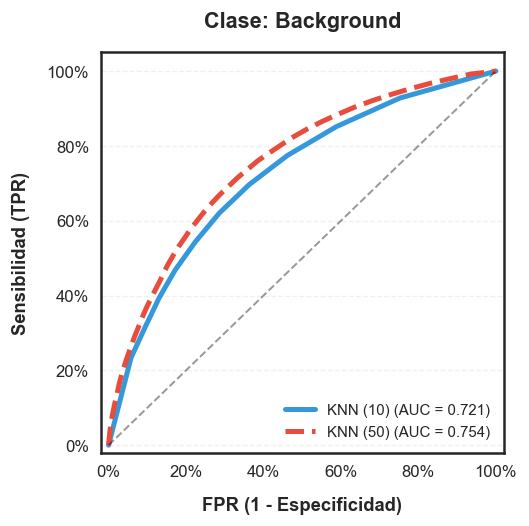

In [20]:
plot_roc_comparison(
    df_m1=eval_memory['prob_10_test'], 
    df_m2=eval_memory['prob_50_test'], 
    name_m1="KNN (10)", 
    name_m2="KNN (50)", 
    focus_class=[0], 
    figsize=(4.5, 4.5), legend_size=9
)

Este patrón de mejora se mantiene al evaluar las curvas asociadas a las crisis de tipo focal y generalizada, donde el incremento en el número de vecinos ratificó una superioridad técnica en la capacidad de discriminación. La configuración con $K=50$ alcanzó un AUC de $0.662$ para crisis focales y un notable $0.771$ para eventos generalizados, superando en ambos casos los rendimientos obtenidos con una vecindad reducida de $K=10$. La mayor ganancia registrada en la clase generalizada ($|\Delta| = 0.043$) sugiere que una vecindad más densa es particularmente eficaz para capturar las dinámicas rítmicas y globales de estos eventos, logrando mitigar con mayor éxito la variabilidad neurofisiológica inter-sujeto característica del corpus TUSZ.


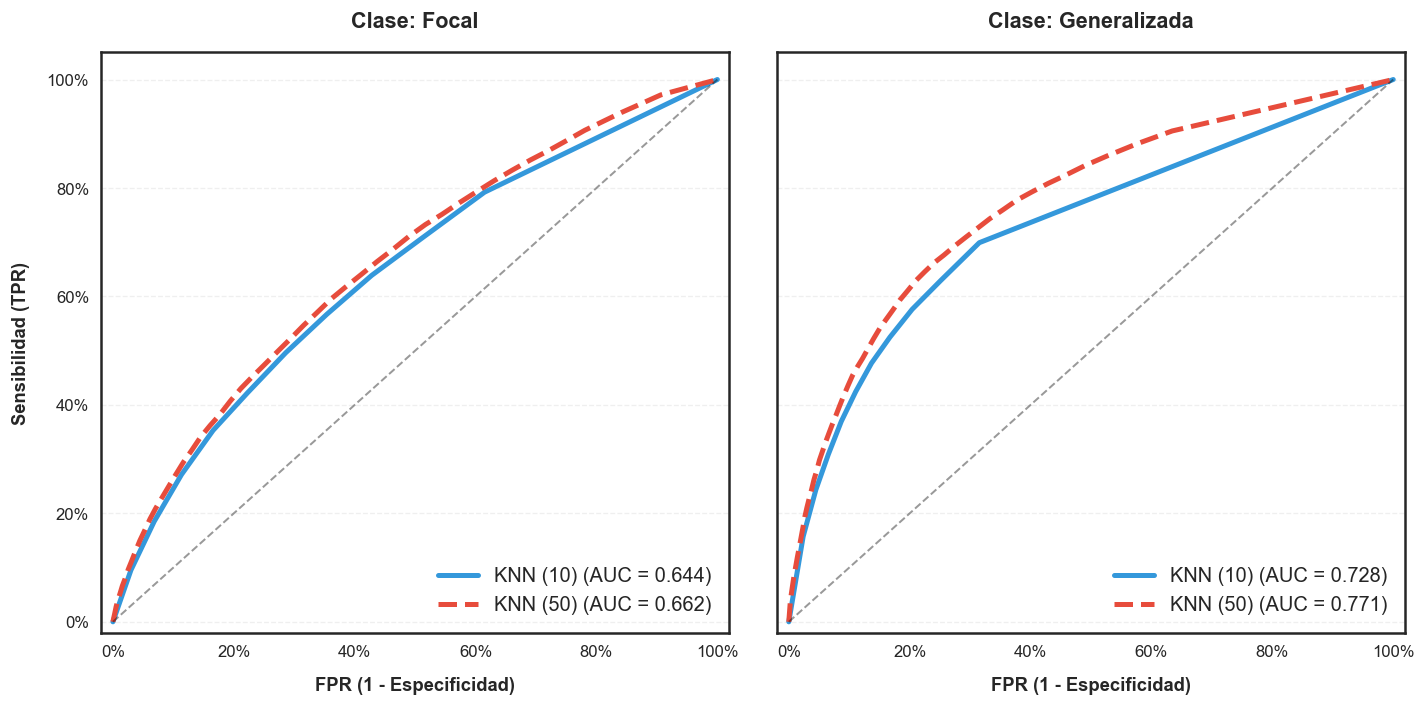

In [21]:
plot_roc_comparison(
    df_m1=eval_memory['prob_10_test'], 
    df_m2=eval_memory['prob_50_test'], 
    name_m1="KNN (10)", 
    name_m2="KNN (50)",
    focus_class=[1, 2], 
    figsize=(12, 6), legend_size=12
)

Los resultados de la prueba de DeLong, confirman que la superioridad del modelo optimizado mediante Optuna no es un artefacto de la muestra, sino una mejora significativa en la capacidad de discriminación. Específicamente, el análisis revela que la configuración con una mayor densidad de vecinos ($K=50$) logra una separación de clases estadísticamente más robusta, consolidándose como el modelo con mayor capacidad de generalización al reducir significativamente la incertidumbre en la clasificación de pacientes nuevos en comparación con el modelo derivado de la busqueda exahustiva.

In [31]:
compare_models_DeLong(
    df_m1=eval_memory['prob_10_test'], 
    df_m2=eval_memory['prob_50_test'], 
    rename_cols={'Modelo 1': 'KNN (10)', 'Modelo 2': 'KNN (50)'},
    n_boot=1000
)

Clase,KNN (10),KNN (50),Diferencia,SE,Z,p,LB,UB
Background,0.721,0.754,-0.033,0.0008,-39.252,<0.001***,-0.035,-0.031
Focal,0.644,0.662,-0.018,0.0013,-13.558,<0.001***,-0.021,-0.016
Generalizada,0.728,0.771,-0.043,0.0016,-26.752,<0.001***,-0.046,-0.040


Tras consolidar la arquitectura del clasificador, se procedió a examinar la sensibilidad del sistema ante variaciones en los umbrales de decisión ($\tau$), observando que mientras el $F_{2}$-Score exhibe una notable estabilidad frente a los cambios de umbral, el Índice $G$ actúa como un regulador crítico de la capacidad discriminativa, logrando un incremento sustancial bajo la segunda configuración. Esta discrepancia sugiere que el Índice $G$ captura matices de la equidad predictiva que el $F_{2}$ tiende a omitir, posicionándose como un criterio de optimización superior para el ajuste fino del modelo. Por consiguiente, se evaluó el impacto de estas configuraciones en la muestra de prueba mediante matrices de confusión, permitiendo determinar cuál de los umbrales potencia de manera efectiva la utilidad diagnóstica y la capacidad de generalización del clasificador en un entorno de detección ictal real.

In [27]:
display_clinical_results(
    df_prob = eval_memory['prob_50_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "KNN_K50_PCA25_Manhattan"
)

Configuración,F2-Score (max),G-Index (max),Tau Focal,Tau Gen
Optimizado para F2,0.4298,0.3934,0.6749,0.7459
Optimizado para G-Index,0.4013,0.5139,0.5515,0.4982


Al analizar la matriz de confusión optimizada bajo el criterio del $F_2$-Score, se identifica un compromiso crítico en la seguridad del clasificador. Dado que la omisión de segmentos con crisis ictales representa un riesgo clínico sustancial, el incremento de los falsos negativos en esta configuración resulta evidente: las crisis focales erróneamente clasificadas como fondo casi se triplican ($\Delta = +41.1\%$), mientras que en las crisis generalizadas el impacto es aún más severo al multiplicarse casi por cuatro la tasa de omisión ($\Delta = +46.6\%$). Este desplazamiento de las fronteras de decisión sugiere que, a pesar de maximizar el score teórico, el modelo prioriza la especificidad del Background ($\Delta = +29.3\%$) a costa de reducir drásticamente la sensibilidad ante eventos epilépticos, lo que invalida su utilidad operativa para el monitoreo de pacientes.

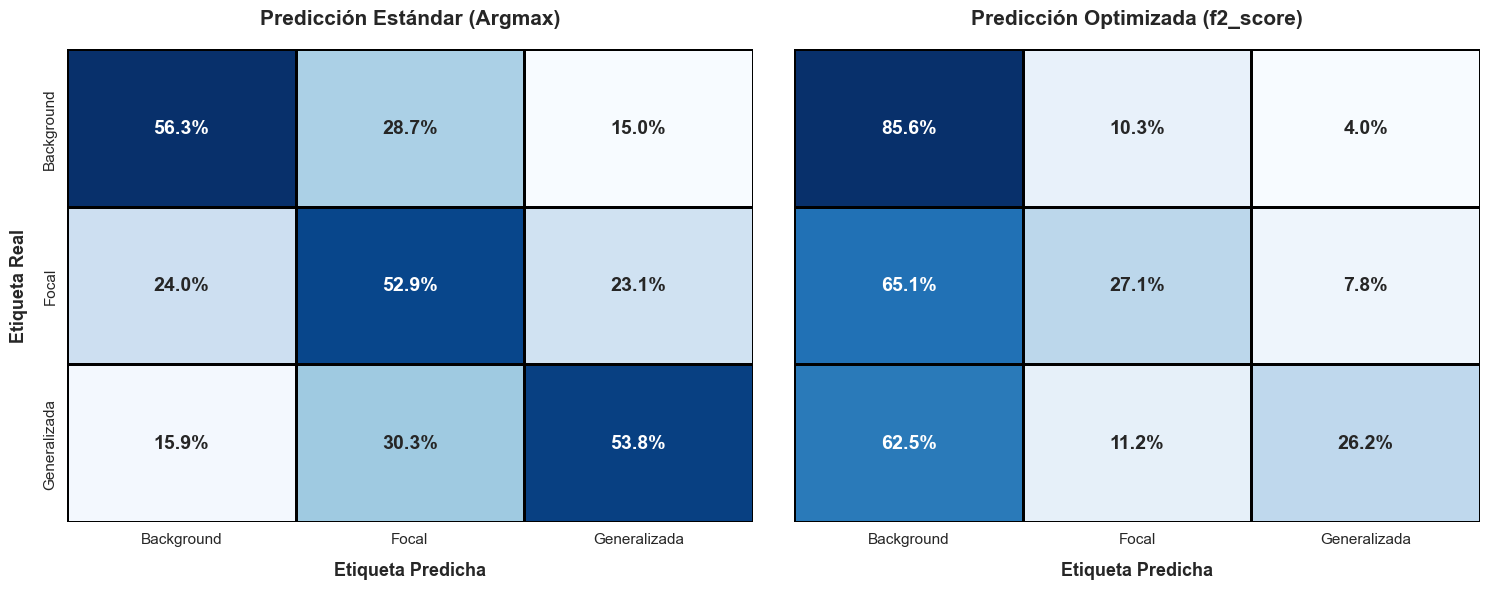

In [28]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_50_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "KNN_K50_PCA25_Manhattan",
    metric_type = 'f2_score'
)

Similarmente, al evaluar la matriz de confusión correspondiente a los umbrales optimizados bajo el Índice G, se observa una degradación de la sensibilidad diagnóstica que, aunque menos severa que la registrada con el $F_2$, continúa comprometiendo la detección de eventos. El incremento de los falsos negativos es consistente en ambas categorías críticas: las crisis focales erróneamente clasificadas como fondo aumentan ($\Delta = +15.8\%$), mientras que en las crisis generalizadas la tasa de omisión se eleva de igual forma ($\Delta = +15.7\%$). Si bien esta configuración logra una ganancia en la especificidad del Background ($\Delta = +12.4\%$), el costo en términos de seguridad clínica resulta injustificado. Dado que la prioridad en el monitoreo de pacientes es minimizar la omisión de episodios ictales, se concluye que el umbral estándar (Argmax) representa la configuración ideal para el modelo $k$-NN, al ofrecer el balance más seguro y robusto sin los niveles de error introducidos por las optimizaciones dirigidas.

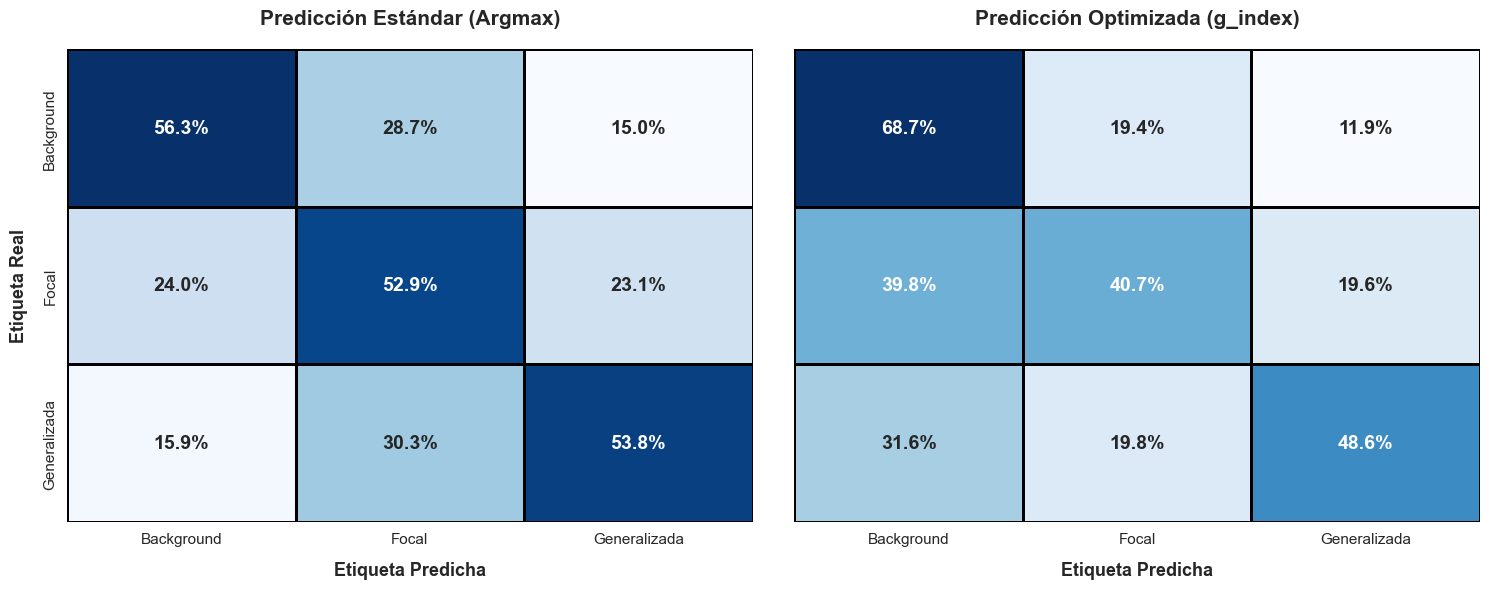

In [29]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_50_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "KNN_K50_PCA25_Manhattan",
    metric_type = 'g_index'
)

Finalmente, para culminar esta sección, se presentan los índices de ajuste obtenidos por el modelo $k$-NN utilizando el umbral estándar (Argmax). Dado que esta configuración demostró ser la más robusta ante la variabilidad de la muestra de prueba y garantizó una mayor seguridad en la detección de eventos ictales, sus métricas finales consolidan la línea base de rendimiento para este clasificador. Este desempeño de referencia permite una comparación directa y rigurosa con las arquitecturas de ensamble evaluadas en las secciones posteriores, estableciendo el estándar mínimo de generalización exigido para el diagnóstico diferencial en el corpus TUSZ.

Al examinar los índices de ajuste globales, se observa una brecha significativa en el rendimiento del modelo al transitar de la muestra de entrenamiento a la de prueba, con discrepancias críticas en métricas como el $F_{2}$-Score ($\Delta = 0.310$) y el PR-AUC ($\Delta = 0.417$). Esta divergencia sugiere que, si bien el algoritmo logra una convergencia óptima en el entrenamiento, su dependencia de la estructura de vecindad local lo hace particularmente vulnerable a la variabilidad inter-sujeto en comparación con modelos paramétricos.

In [39]:
display_model_summary(
    df_train = eval_memory['prob_50_train'], 
    df_test = eval_memory['prob_50_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "KNN_K50_PCA25_Manhattan", 
    scorer = scorer, 
    metric_opt = 'argmax',
    overfit_threshold = 0.1
)

Métrica,Entrenamiento,Prueba,Diferencia
Accuracy,0.732,0.621,0.111†
Precision,0.574,0.376,0.198†
Recall,0.787,0.530,0.257†
Specificity,0.875,0.775,0.101†
G-Index,0.785,0.525,0.259†
F1-Score,0.618,0.345,0.272†
F2-Score,0.694,0.384,0.310†
ROC-AUC,0.925,0.729,0.196†
PR-AUC,0.800,0.384,0.417†


Bajo esta óptica, aunque el desempeño final en la muestra de prueba es marginalmente inferior al de la Regresión Logística (con descensos de $\Delta F_2= -0.019$ y $\Delta AUC = -0.023$), la paridad observada en el Índice $G$ ($\Delta = -0.006$) indica que ambos clasificadores alcanzan un techo de discriminación similar. Estos hallazgos confirman que, a pesar de capturar eficazmente las relaciones locales, el $k$-NN enfrenta limitaciones de generalización comparables ante la singularidad de los perfiles bioeléctricos, lo que consolida la necesidad de explorar arquitecturas jerárquicas capaces de extraer patrones más abstractos y robustos en el corpus TUSZ.

## Gaussian Naive Bayes

Como cuarto modelo de referencia, se incorporó el Clasificador Bayesiano Ingenuo Gaussiano (GNB) con el propósito de evaluar el comportamiento del sistema bajo un marco de probabilidades condicionales explícitas. A diferencia de los modelos previos que requieren transformaciones para la estimación de riesgo, esta aproximación permitió caracterizar la capacidad discriminativa del pipeline asumiendo distribuciones normales en los descriptores de las señales del corpus TUSZ. Con este benchmark, se buscó determinar si el modelado de densidades de probabilidad ofrece una sensibilidad superior en la identificación de eventos ictales frente a las fronteras de decisión geométricas y de vecindad previamente establecidas.

En cuanto a la configuración del espacio de búsqueda, se optó por un diseño que prioriza la estabilidad de las varianzas y la gestión del desbalance de clases. Si bien la aplicación de técnicas de sobremuestreo puede alterar levemente la independencia lineal y la estructura de covarianza lograda mediante el PCA, estas estrategias se mantuvieron con propósitos comparativos para garantizar la equidad operativa frente a los modelos previos. El espacio de búsqueda incluyó una exploración exhaustiva de los componentes principales (hasta 800 componentes) y del parámetro de suavizado de varianza, buscando regularizar las densidades de probabilidad y evitar el sobreajuste ante descriptores con magnitudes heterogéneas. De este modo, el GNB actúa como una referencia de baja complejidad computacional que permite cuantificar la ganancia real de los modelos más sofisticados en el pipeline.

In [ ]:
espacios_de_busqueda_gnb = {
    'grid': {
        'clf__var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3, 1e-2],
        'clf__use_weight_in_fit': [True, False],
        'pca__n_components': [50, 150, 300, 450, 800], 
        'decision_strategy': ['map', 'expected_risk'],
        'balancing': ['none', 'weight_balanced']
    }
}

trainer_gnb = Trainer(
    df_map=df_map_fold,           
    train_set_paths=train_set_paths, 
    estimator=modelo_gnb, 
    scoring_func=metrica_optimizacion,
    secondary_scoring_funcs=metricas_secundarias,
    feature_cols=FEATURE_COLS_CLEAN, 
    target_col=TARGET_COL, 
    label_mapping=LABEL_MAPPING
)

dict_tablas_gnb, df_bench_gnb, dict_conv_gnb = trainer_gnb.fit(
    methods=['grid'], 
    spaces=espacios_de_busqueda_gnb,
    n_trials=20,
    samples_per_fold=40000,
    scaler_type='quantile_gaussian',
    seed=42
)

In [84]:
RESULTS_PATH = ROOT_DIR / "results" / "gnb" / "gnb_tabla_global.csv"

if RESULTS_PATH.exists():
    df_gnb_results = pd.read_csv(RESULTS_PATH)
    df_gnb_results = df_gnb_results.iloc[:, 0:11]
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

La evaluación descriptiva de las métricas $F_2$ para el clasificador Gaussian Naive Bayes reveló una jerarquía de desempeño inesperada en comparación con los modelos previos. A diferencia de lo observado en arquitecturas como KNN, el clasificador base (sin técnica de mitigación) registró los valores de eficacia más altos de la serie ($F_2 \approx 0.455$), lo que sugiere que la distribución teórica del modelo asimila de forma más robusta la prevalencia natural de las clases en el corpus TUSZ. Por el contrario, el empleo de técnicas de sobremuestreo derivó en una degradación sistemática del rendimiento: SMOTE mostró una reducción moderada ($F_2 \approx 0.419$), mientras que ADASYN y el ajuste mediante pesos de clase (weight) presentaron los resultados más deficientes ($F_2 \approx 0.385$ y $0.271$, respectivamente). Estos hallazgos refuerzan la hipótesis de que, en modelos con fuertes supuestos de distribución, la introducción de muestras sintéticas o la alteración de los priors distorsiona las densidades de probabilidad originales, introduciendo un ruido que dificulta la segregación efectiva de los episodios ictales.

In [86]:
display_balancing_comparison(df_gnb_results, metric='F2', sort_by='none')

Use_weight_in_fit,Var_smoothing,Decision_strategy,Pca (k),none,weight,SMOTE,ADASYN
False,0.001,map,50,0.455 ± 0.038,0.259 ± 0.017,0.414 ± 0.027,0.381 ± 0.026
True,0.001,map,50,0.455 ± 0.038,0.259 ± 0.017,0.414 ± 0.027,0.381 ± 0.026
True,1e-09,map,50,0.454 ± 0.037,0.263 ± 0.017,0.419 ± 0.028,0.385 ± 0.025
False,0.001,map,100,0.454 ± 0.050,0.271 ± 0.021,0.389 ± 0.029,0.368 ± 0.025
False,1e-07,map,50,0.454 ± 0.037,0.263 ± 0.017,0.419 ± 0.028,0.385 ± 0.025


Para validar estadísticamente las diferencias observadas, se aplicó una prueba de Kruskal-Wallis, la cual confirmó la existencia de efectos significativos del método de balanceo sobre el desempeño del modelo ($H = 165.023$; $p < 0.001$), con una magnitud del efecto grande ($\varepsilon^2 = 0.513$). Al profundizar en las comparaciones post-hoc mediante pruebas U de Mann-Whitney, se evidenció que la superioridad del clasificador base es estadísticamente robusta. 

Es notable que, al contrastar la configuración original con las técnicas de sobremuestreo, las diferencias en el $F_2$ resultaron marginales en términos de significancia práctica, con tamaños del efecto ínfimos al comparar la ausencia de balanceo frente a SMOTE ($r = 0.006$) y ADASYN ($r < 0.001$). Por el contrario, la aplicación de probabilidades a priori basadas en la frecuencia inversa (weight) generó una caída drástica y significativa en el rendimiento ($r = 0.646$). Estos resultados refuerzan la tesis de que, para este corpus y arquitectura, el GNB alcanza su punto de máxima eficiencia operando sobre la prevalencia natural de los datos, sugiriendo que cualquier intento de rebalanceo, especialmente mediante el ajuste de priors, introduce distorsiones que el modelo no logra compensar bajo sus supuestos paramétricos.

In [87]:
df_clean = df_gnb_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

::: {admonition} Nota Metodológica: Probabilidades a Priori:class: note

La probabilidad a priori constituyó la estimación inicial de la prevalencia de cada clase antes de integrar la información contenida en los descriptores vectorizados de las señales de EEG. En el marco del Teorema de Bayes, esta probabilidad actuó como un modulador fundamental que, al multiplicarse por la verosimilitud, determinó la probabilidad final o a posteriori, siguiendo la relación de proporcionalidad:


$$P(C_k | x) \propto P(x | C_k) P(C_k)$$

donde $P(C_k)$ es la probabilidad a priori, $P(x | C_k)$ representa la verosimilitud, y $P(C_k | x)$ es la probabilidad a posteriori.

Dentro de la literatura de optimización para el procesamiento del corpus TUSZ, se identificaron dos enfoques predominantes para la definición de estos valores. Por un lado, el uso de priors uniformes permitió asignar una probabilidad idéntica a todas las categorías, lo que anuló el sesgo estadístico hacia la clase mayoritaria y forzó al clasificador a depender exclusivamente de la distribución de las características físicas de la señal. Por otro lado, el empleo de priors basados en la frecuencia inversa permitió ajustar el peso de cada clase de forma inversamente proporcional a su prevalencia en el entrenamiento. Esta última configuración resultó crítica para compensar el desbalance severo entre la actividad basal y los eventos ictales, optimizando la probabilidad final a favor de la sensibilidad clínica necesaria en el diagnóstico neurológico.

:::

Con el fin de recabar datos adicionales sobre los efectos de los priors y el sobremuestreo, se analizaron los resultados bajo el Índice G. En esta métrica se observó un patrón de desempeño equivalente al reportado para el estadístico $F_2$, aunque con una magnitud de eficacia superior y una divergencia más marcada entre las estrategias. Nuevamente, la configuración base (none) consolidó su superioridad al alcanzar valores de $0.518$, superando significativamente a los métodos de interpolación lineal como SMOTE. Por su parte, el ajuste de probabilidades a priori por frecuencia inversa ratificó su ineficiencia para este clasificador, presentando la caída más pronunciada en la capacidad de discriminación global. Estos resultados sugieren que, si bien el GNB posee una capacidad de separación de clases notable en su estado puro, esta estructura es sumamente sensible a las perturbaciones en la distribución original de los datos.

In [88]:
display_balancing_comparison(df_gnb_results, metric='G', sort_by='none')

Use_weight_in_fit,Var_smoothing,Decision_strategy,Pca (k),none,weight,SMOTE,ADASYN
False,0.001,map,50,0.518 ± 0.050,0.331 ± 0.020,0.456 ± 0.044,0.422 ± 0.037
True,0.001,map,50,0.518 ± 0.050,0.331 ± 0.020,0.456 ± 0.044,0.422 ± 0.037
True,0.001,map,100,0.517 ± 0.061,0.336 ± 0.024,0.425 ± 0.047,0.406 ± 0.036
False,0.001,map,100,0.517 ± 0.061,0.336 ± 0.024,0.425 ± 0.047,0.406 ± 0.036
False,1e-05,map,50,0.516 ± 0.050,0.338 ± 0.020,0.444 ± 0.046,0.416 ± 0.038


La prueba de Kruskal-Wallis ratificó efectos significativos del balanceo sobre el Índice G ($H = 96.02$; $p < 0.001$), con una magnitud del efecto grande ($\varepsilon^2 = 0.294$). Al realizar el análisis post-hoc con las pruebas U de Mann-Whitney, se verificó que la superioridad del modelo base (*none*) persiste de manera sistemática y significativa frente a todas las demás estrategias. Es relevante notar que, en esta métrica, los tamaños del efecto frente a las técnicas de sobremuestreo resultaron superiores a los registrados en $F_2$, situándose en rangos moderados ($r = 0.317$ para SMOTE y $r = 0.356$ para ADASYN). No obstante, la caída más drástica volvió a evidenciarse al aplicar el ajuste por frecuencia inversa (*weight*), que presentó una disparidad crítica frente al modelo original ($r = 0.646$). Estos hallazgos consolidan la tesis de que el clasificador bayesiano obtiene su mejor rendimiento al preservar la estructura probabilística original de las señales, y que cualquier intento de rebalanceo compromete la integridad de la frontera de decisión.

In [89]:
tabla_posthoc(df_clean, metric_col='g_index_center')

En conclusión, los hallazgos presentados confirman que la configuración base del modelo Gaussian Naive Bayes alcanza los índices de rendimiento más altos de todo el experimento. Los contrastes estadísticos indicaron tamaños del efecto que oscilan entre moderados y grandes, lo que desvirtúa la utilidad de las intervenciones analizadas: cualquier intento de sobremuestreo o ajuste de priors no solo no logra superar la línea base, sino que introduce una degradación sistemática y significativa en la capacidad discriminativa del modelo. Esta superioridad robusta demuestra que la muestra original posee el mayor potencial de generalización para esta arquitectura. En consecuencia, se establece que, ante la naturaleza probabilística de este clasificador, la preservación de la estructura natural de los datos en el corpus TUSZ constituye la estrategia más sólida para la detección de eventos ictales, invalidando el uso de técnicas de rebalanceo que distorsionan las densidades de probabilidad originales.


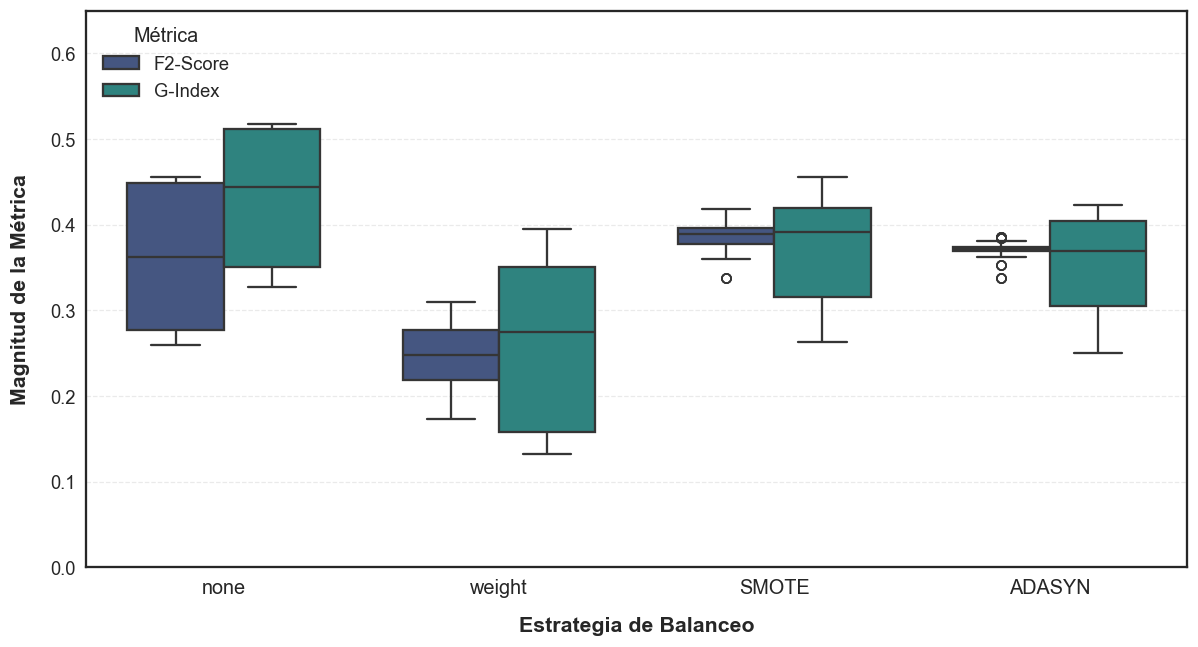

In [76]:
plot_balancing_comparison_dual(
    df=df_gnb_results, 
    metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'],           
    y_lim=(0.00, 0.65)                           
)

Al analizar la dinámica de optimización para el clasificador Gaussian Naive Bayes, se observa que, si bien el método Grid Search logró establecer un desempeño base competitivo ($F_2 = 0.457$), su implementación resultó en una eficiencia subóptima al no localizar el punto de máximo rendimiento del espacio de búsqueda. Aunque la arquitectura del GNB es inherentemente veloz, el costo acumulado de las $480$ evaluaciones demandó un tiempo de procesamiento que, sin ser prohibitivo, superó al de la optimización dirigida.

En contraste, el optimizador Optuna demostró una superioridad técnica contundente al localizar el máximo absoluto del experimento ($F_2 = 0.461$) en un tiempo significativamente menor, resultando un $31.3\%$ más rápido que el método exhaustivo. Al analizar la eficacia operativa (definida como la razón entre el tiempo de procesamiento y el número de ensayos), la búsqueda bayesiana resultó ser aproximadamente $3.3$ veces más costosa por unidad de evaluación que el Grid Search ($16.45$ s/eval frente a $4.99$ s/eval). No obstante, la inteligencia de búsqueda permitió que Optuna convergiera hacia regiones de alto rendimiento con solo 100 ensayos, mientras que algoritmos como DEAP requirieron $300$ evaluaciones sin lograr convergencia ni resultados superiores ($F_2 = 0.455$). Este comportamiento consolida a la optimización bayesiana como la herramienta de elección, logrando el mejor balance entre la exploración estratégica del espacio de hiperparámetros y la reducción del tiempo total de cómputo.

In [90]:
RESULTS_PATH = ROOT_DIR / "results" / "gnb" / "optimization" / "tabla_bench.csv"

if RESULTS_PATH.exists():
    df_bench = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

optuna_path = ROOT_DIR / "results" / "gnb" / "optimization" / "gnb_optuna_details.csv"

if optuna_path.exists():
    df_optuna = pd.read_csv(optuna_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {optuna_path}")

grid_path = ROOT_DIR / "results" / "gnb" / "optimization" / "gnb_grid_details.csv"

if grid_path.exists():
    df_grid = pd.read_csv(grid_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {grid_path}")

In [91]:
df_bench = df_bench.rename(columns={'execution_time_sec': 'execution_time_sec','best_score_center': 'best_score'})
columnas_requeridas = ['optimization_method', 'execution_time_sec', 'total_evaluations', 'best_score', 'early_stopped']
df_bench = df_bench[columnas_requeridas]
display_optimization_benchmark(df_bench)

Método de Optimización,Tiempo,Evaluaciones Totales,Mejor Score (F2),Convergencia
Grid Search,00:39:53,480,0.457,---
Búsqueda Aleatoria,02:00:15,300,0.457,---
Optuna,00:27:25,100,0.461,Sí
DEAP,00:54:48,300,0.455,No


Al analizar los resultados de la búsqueda exhaustiva para el Gaussian Naive Bayes, se observa que las configuraciones de mayor rendimiento requirieron una reducción drástica de dimensionalidad a solo 25 componentes de PCA. Es relevante señalar que este mismo límite inferior fue el preferido por el modelo k-NN, lo que sugiere que ambas arquitecturas comparten una vulnerabilidad crítica ante la alta dimensionalidad; mientras que en el k-NN el ruido degrada la métrica de distancia, en el GNB este distorsiona la estimación de las densidades de probabilidad al intentar ajustar distribuciones en espacios de gran volumen. Esta convergencia hacia un espacio de características altamente filtrado, sumado a un suavizado de varianza conservador y el uso de la estrategia de decisión MAP, indica que el éxito del clasificador radica en operar sobre descriptores simplificados y ortogonales, logrando maximizar su capacidad discriminativa bajo sus propios supuestos paramétricos.

In [92]:
df_grid_copy = df_grid.iloc[:, 0:8].copy()
display_detailed_metrics(df_grid_copy, sort_by='F2', rename_cols={'use_weight_in_fit': 'Use weight',
                                                'var_smoothing': 'Smoothing', 'n_components': 'PCA', 
                                                                  'decision_strategy': 'Estrategia',
                                                                  'primary': 'F2', 'f1_score': 'F1', 'g_index':'Índice G'})

Use weight,Smoothing,Estrategia,PCA,F2,F1,Índice G
0,0.001,map,25,0.457 ± 0.038,0.424 ± 0.032,0.520 ± 0.056
1,0.001,map,25,0.457 ± 0.038,0.424 ± 0.032,0.520 ± 0.056
1,0.001,map,50,0.455 ± 0.038,0.420 ± 0.031,0.518 ± 0.050
0,0.001,map,50,0.455 ± 0.038,0.420 ± 0.031,0.518 ± 0.050
1,1e-09,map,25,0.455 ± 0.038,0.423 ± 0.031,0.519 ± 0.056


En cuanto a Optuna, los resultados evidenciaron una convergencia hacia la misma arquitectura de baja dimensionalidad (25 componentes), diferenciándose únicamente por una sutil variación en el parámetro de suavizado (*Smoothing*). Debido a la naturaleza estocástica y la precisión en la búsqueda de este algoritmo, dicho ajuste infinitesimal en el épsilon permitió un incremento marginal en los puntajes de rendimiento frente al Grid Search. No obstante, esta coincidencia reafirma que el modelo ha alcanzado un estado de estabilidad donde las variaciones paramétricas solo representan ganancias residuales, consolidando esta configuración como el techo operativo del clasificador.

In [93]:
df_optuna_copy = df_optuna.iloc[:, 0:8].copy()
display_detailed_metrics(df_optuna_copy, sort_by='F2', rename_cols={'use_weight_in_fit': 'Use weight',
                                                'var_smoothing': 'Smoothing', 'n_components': 'PCA', 
                                                                  'decision_strategy': 'Estrategia',
                                                                   'primary': 'F2', 'f1_score': 'F1', 'g_index':'Índice G'})

PCA,Smoothing,Use weight,Estrategia,F2,F1,Índice G
25,0.00571054,0,map,0.461 ± 0.040,0.426 ± 0.034,0.524 ± 0.058
50,0.00862186,1,map,0.459 ± 0.042,0.421 ± 0.037,0.526 ± 0.054
50,0.00924733,1,map,0.458 ± 0.043,0.420 ± 0.037,0.526 ± 0.054
25,0.00182523,1,map,0.458 ± 0.039,0.424 ± 0.032,0.521 ± 0.057
25,2.9152e-10,1,map,0.455 ± 0.038,0.423 ± 0.031,0.519 ± 0.056


Al analizar la dinámica de Optuna, se observa una convergencia técnica significativa con los resultados de la búsqueda exhaustiva, localizando una configuración óptima que mantiene la reducción a $25$ componentes de PCA y un suavizado de varianza de $0.006$. Esta coincidencia en la elección de una baja dimensionalidad, sumada a un ajuste de regularización más preciso que el permitido por los saltos discretos del Grid Search, sugiere que el clasificador posee una región de máxima eficiencia bien definida. La superioridad de la optimización bayesiana radica, por tanto, en su capacidad para localizar estos "puntos dulces" paramétricos con una eficiencia operativa superior, ratificando el máximo global en una fracción del tiempo y consolidándose como la estrategia más robusta para la configuración del Gaussian Naive Bayes en este pipeline.

Para verificar la capacidad de generalización del modelo, se contrastó la configuración ganadora frente a una arquitectura alternativa, también identificada durante la exploración de Optuna, mediante su evaluación en la muestra de prueba independiente.

In [ ]:
modelo_gnb = get_model('gaussian_nb')
configs_gnb = [
    {
        "name": "GNB_PCA25_Smooth_Low",
        "params": {
            'pca__n_components': 25,
            'clf__var_smoothing': 0.00571054,
            'clf__use_weight_in_fit': False,
            'decision_strategy': 'map',
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_gaussian" 
    },
    {
        "name": "GNB_PCA50_Smooth_High_Weighted",
        "params": {
            'pca__n_components': 50,
            'clf__var_smoothing': 0.00862186,
            'clf__use_weight_in_fit': True,
            'decision_strategy': 'map',
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_gaussian" 
    }
]

resultados_gnb = {}

for cfg in configs_gnb:
    evaluator = Evaluator(train_set_paths=train_set_paths, test_set_paths=test_set_paths,
        estimator=modelo_gnb, feature_cols=FEATURE_COLS_CLEAN, target_col=TARGET_COL, label_mapping=LABEL_MAPPING)

    evaluator.fit(best_params=cfg['params'], scaler_type=cfg['scaler'], samples_for_train=40000, 
                  export_path=f"models/{cfg['name']}.joblib")

    train_res = evaluator.get_full_probabilities(evaluator.train_set_paths, "Train Global")
    test_res = evaluator.get_full_probabilities(evaluator.test_set_paths, "Test Global")
    resultados_gnb[cfg['name']] = {'thresholds': evaluator.best_thresholds_, 'train': train_res, 'test': test_res}

In [98]:
EVAL_PATH_GNB = ROOT_DIR / "results" / "gnb" / "evaluation"
eval_memory_gnb = {}
load_eval_data(EVAL_PATH_GNB / "gnb_thresholds.csv", "thresholds")

evaluation_files_gnb = [
    ("prob_25_train", "prob_GNB_PCA25_Smooth_Low_train.csv"),
    ("prob_25_test",  "prob_GNB_PCA25_Smooth_Low_test.csv"),
    ("prob_50_weight_train", "prob_GNB_PCA50_Smooth_High_Weighted_train.csv"),
    ("prob_50_weight_test",  "prob_GNB_PCA50_Smooth_High_Weighted_test.csv")
]

for key, filename in evaluation_files_gnb:
    load_eval_data(EVAL_PATH_GNB / filename, key)

[CARGADO] thresholds                | Registros: 2
[CARGADO] prob_25_train             | Registros: 862737
[CARGADO] prob_25_test              | Registros: 370034
[CARGADO] prob_50_weight_train      | Registros: 862737
[CARGADO] prob_50_weight_test       | Registros: 370034


Al analizar el desempeño del Gaussian Naive Bayes en el conjunto de prueba independiente, los resultados revelan que la arquitectura con una reducción agresiva a 25 componentes alcanzó una mayor capacidad de discriminación respecto a la obtenida por la configuración de mayor dimensionalidad y ajuste de pesos ($\Delta AUC = +0.036$). Esta divergencia sugiere que la validez diagnóstica del GNB en el corpus TUSZ depende críticamente de la parsimonia en la entrada; al operar en un espacio de baja dimensionalidad, el modelo logra modelar densidades de probabilidad más nítidas y menos contaminadas por el ruido latente, optimizando la segregación de los eventos ictales frente a arquitecturas más complejas o sobreparametrizadas.


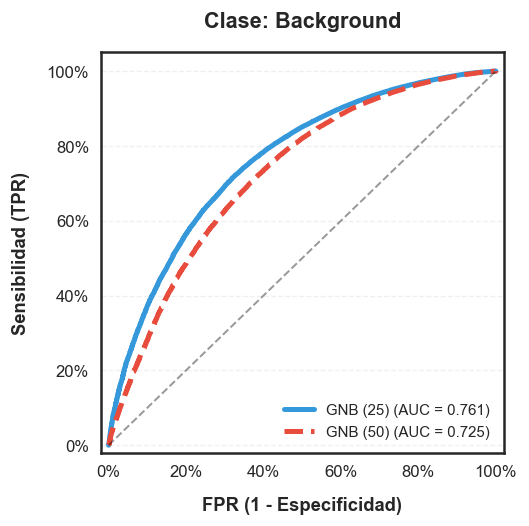

In [107]:
plot_roc_comparison(
    df_m1=eval_memory['prob_25_test'], 
    df_m2=eval_memory['prob_50_weight_test'], 
    name_m1="GNB (25)", 
    name_m2="GNB (50)",
    focus_class=[0], figsize=(4.5, 4.5), legend_size=9
)

Esta tendencia se mantuvo de manera consistente en las otras clases del corpus. Al evaluar el desempeño en las categorías Focal y Generalizada, la arquitectura de 25 componentes preservó ventajas operativas frente a la configuración de 50 componentes ($\Delta AUC = +0.027$ y $ \Delta AUC = +0.044 $, respectivamente). Estas observaciones sugieren que la reducción drástica de dimensionalidad favorece la discriminación de diversos tipos de crisis, siendo especialmente notable el margen obtenido en la clase Generalizada.


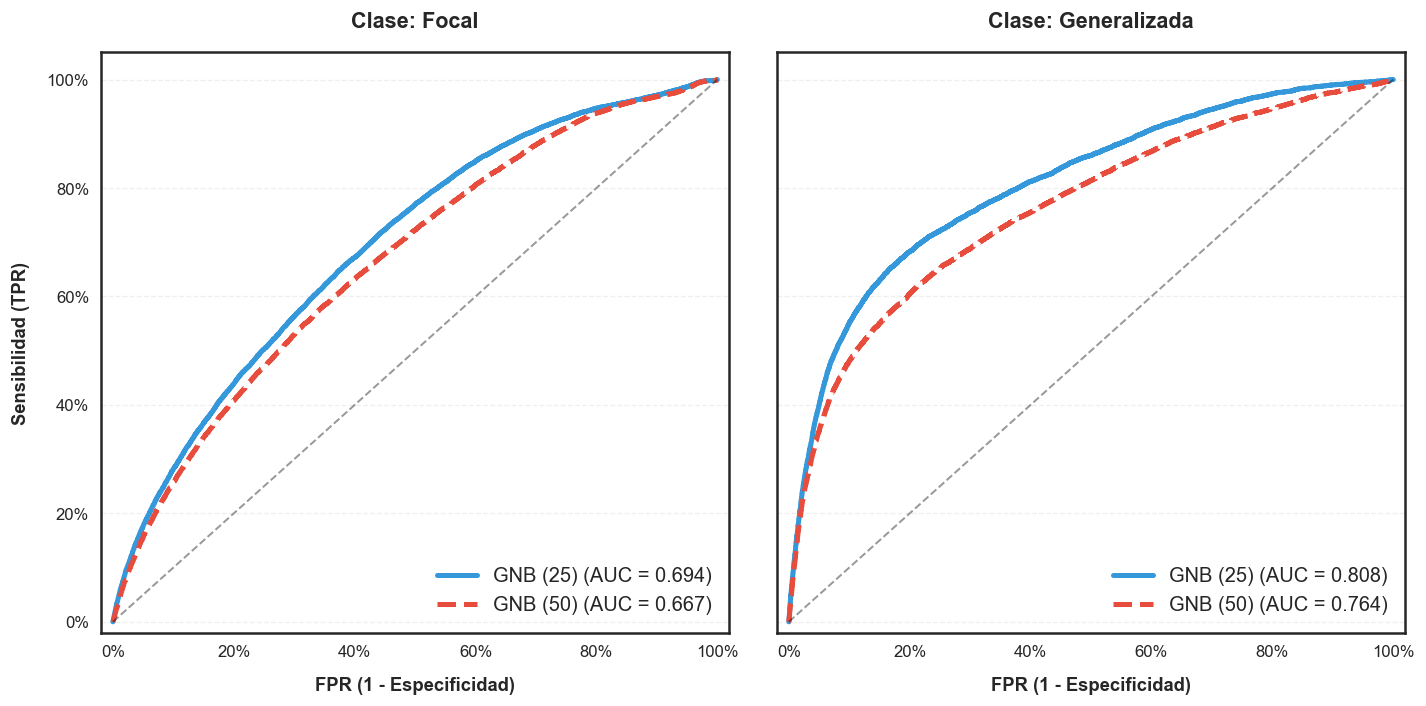

In [108]:
plot_roc_comparison(
    df_m1=eval_memory['prob_25_test'], 
    df_m2=eval_memory['prob_50_weight_test'], 
    name_m1="GNB (25)", 
    name_m2="GNB (50)",
    focus_class=[1,2], figsize=(12, 6), legend_size=12
)

La formalización estadística mediante el test de DeLong confirma que las diferencias en la capacidad discriminativa a favor de la arquitectura de 25 componentes son significativas en las tres categorías evaluadas ($p < 0.001$). Al contrastar estos resultados, se observa que el incremento en la dimensionalidad y el ajuste de pesos no solo no aportan ventajas operativas, sino que degradan sistemáticamente el área bajo la curva. Es fundamental destacar que esta configuración de baja dimensionalidad fue identificada de manera consistente tanto por el Grid Search como por Optuna, lo que ratifica la existencia de una región de máxima eficiencia bien definida para el clasificador bayesiano. Por tanto, se prioriza esta estructura parsimoniosa, ya que ofrece un equilibrio superior entre sensibilidad y especificidad, garantizando una identificación de actividad ictal más robusta al minimizar la captura de ruido latente en el espectro de la señal.

In [109]:
compare_models_DeLong(
    df_m1=eval_memory['prob_25_test'], 
    df_m2=eval_memory['prob_50_weight_test'], 
    rename_cols={'Modelo 1': 'GNB (25)', 'Modelo 2': 'GNB (50)'},
    n_boot=1000
)

Clase,GNB (25),GNB (50),Diferencia,SE,Z,p,LB,UB
Background,0.761,0.725,0.036,0.0009,40.604,<0.001***,0.035,0.038
Focal,0.694,0.667,0.027,0.0009,29.747,<0.001***,0.025,0.029
Generalizada,0.808,0.764,0.044,0.0015,28.340,<0.001***,0.041,0.047


Tras consolidar la arquitectura del clasificador, se procedió a examinar la sensibilidad del sistema ante variaciones en los umbrales de decisión. A diferencia de otros modelos evaluados, se observó que mientras el Índice G mantiene una tendencia al alza ($\Delta G = +0.049$), el $F_2$-Score experimenta una degradación crítica al intentar priorizar la equidad predictiva ($\Delta F_2 = -0.081$). Esta discrepancia sugiere que, en el caso del GNB, la optimización hacia el Índice G impone un costo excesivo en la recuperación de eventos ictales, comprometiendo la sensibilidad del modelo en favor de una distribución de errores más equilibrada. Por consiguiente, para estudiar en mayor detalle los efectos de estos umbrales, se analizan las correspondientes matrices de confusión.

In [110]:
display_clinical_results(
    df_prob = eval_memory['prob_25_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "GNB_PCA25_Smooth_Low"
)

Configuración,F2-Score (max),G-Index (max),Tau Focal,Tau Gen
Optimizado para F2,0.4463,0.5218,0.5829,0.5336
Optimizado para G-Index,0.3649,0.5700,0.4919,0.3231


Al analizar la matriz de confusión optimizada bajo el criterio del $F_2$-Score frente a la predicción estándar (MAP), se identifica un compromiso crítico en la seguridad diagnóstica del clasificador. Dado que la omisión de segmentos con crisis representa un riesgo clínico sustancial, el incremento de los falsos negativos en esta configuración resulta evidente: las crisis focales erróneamente clasificadas como fondo casi se triplican ($\Delta = +30.8\%$), mientras que en las crisis generalizadas la tasa de omisión se multiplica por más de 2.5 ($\Delta = +22.1\%$).

Este desplazamiento de las fronteras de decisión sugiere que, a pesar de la optimización paramétrica, el modelo prioriza la especificidad del Background ($\Delta = +24.9\%$) a costa de una pérdida drástica de sensibilidad ante eventos epilépticos, lo que compromete significativamente su viabilidad operativa para el monitoreo automatizado de pacientes.

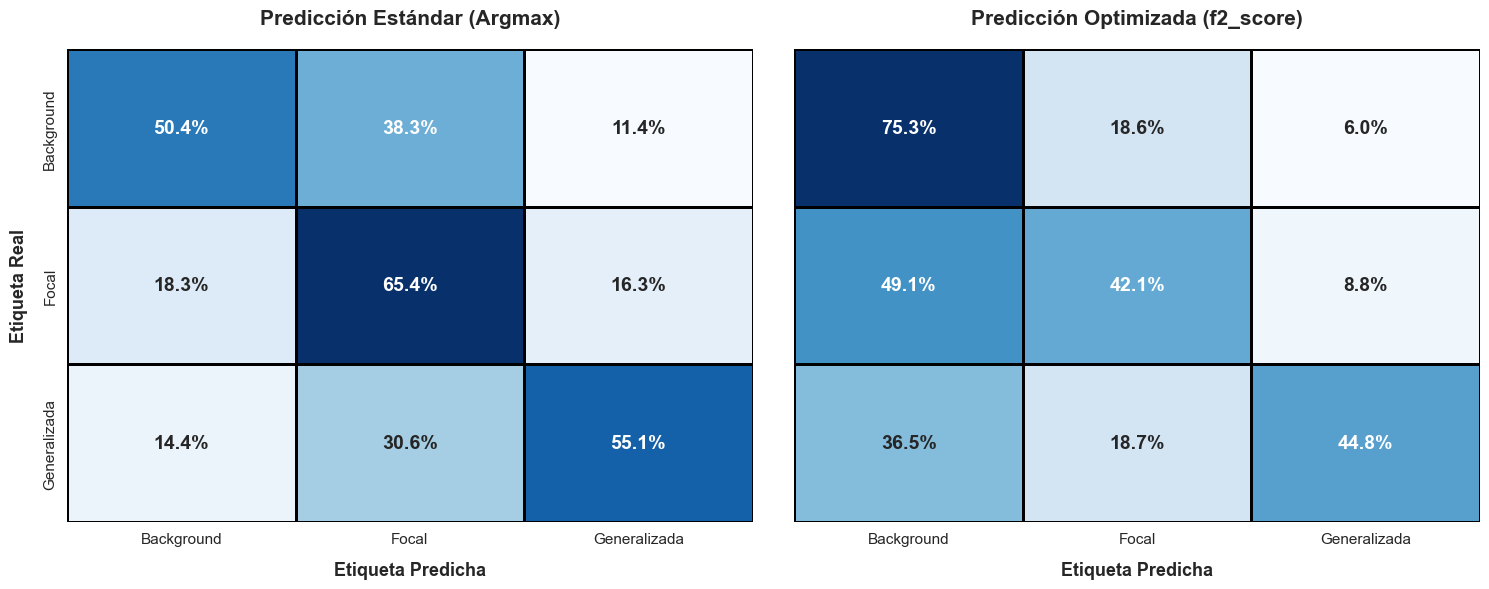

In [112]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_25_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "GNB_PCA25_Smooth_Low",
    metric_type = 'f2_score'
)

Al analizar la matriz de confusión optimizada bajo el criterio del Índice G, se identifica un balance de riesgo clínico bidireccional que cuestiona la rentabilidad de alterar el umbral estándar. Mientras que la configuración logra una mejora marginal en la detección de crisis generalizadas al reducir su omisión hacia el fondo ($\Delta = -2.1\%$), este beneficio se ve neutralizado por un incremento sustancial en los falsos negativos de las crisis focales ($\Delta = +5.1\%$). Este desplazamiento de las fronteras de decisión sugiere que el ajuste hacia la equidad distributiva del Índice G erosiona la sensibilidad ante eventos localizados a cambio de una ganancia leve en la especificidad del background ($\Delta = +3.7\%$). En consecuencia, se concluye que para el GNB este ajuste no representa una ventaja diagnóstica neta, resultando preferible la estabilidad de la predicción estándar para evitar comprometer la detección de eventos focales.

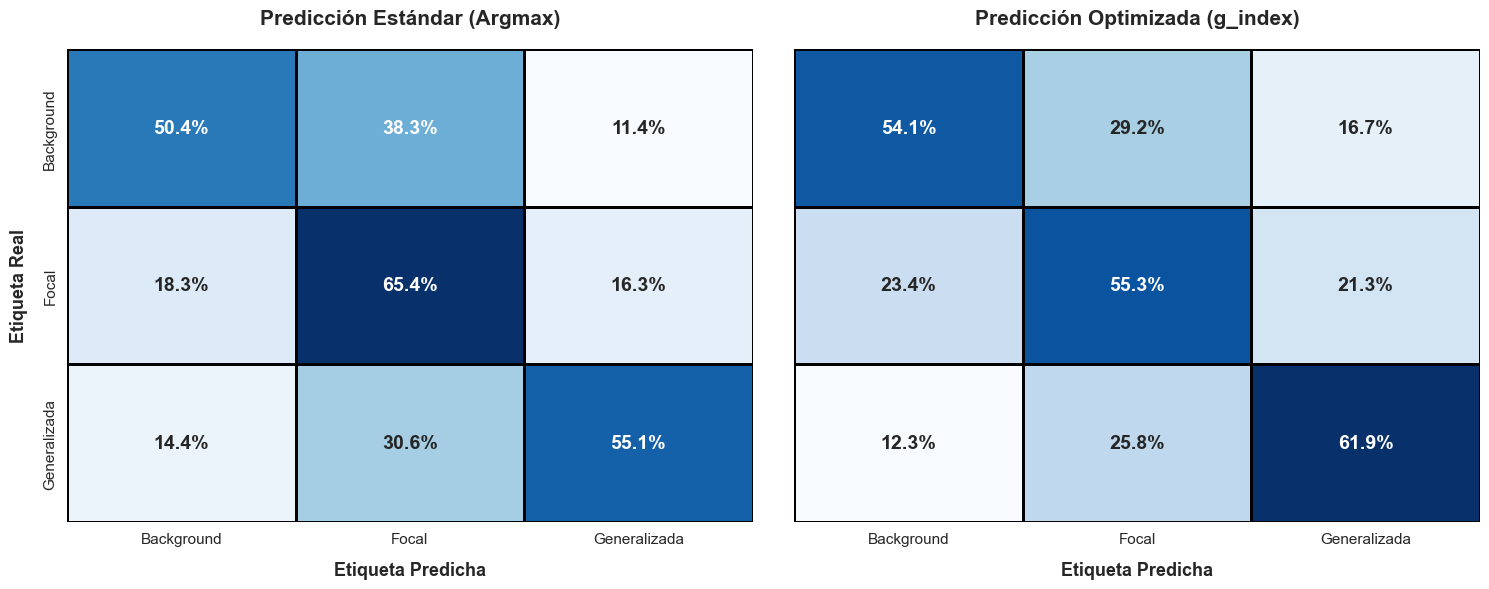

In [113]:
plot_confusion_comparison(
   df_prob = eval_memory['prob_25_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "GNB_PCA25_Smooth_Low",
    metric_type = 'g_index'
)

Para concluir el análisis del Gaussian Naive Bayes, se presentan los índices de ajuste obtenidos bajo el umbral óptimo, consolidando su caracterización operativa definitiva. Este clasificador se posiciona como la arquitectura más eficiente de la etapa inicial del estudio, superando el desempeño de la Regresión Logística y el k-NN ($\Delta AUC \approx +0.014$ respecto al promedio de modelos base). Es relevante destacar que la configuración seleccionada responde a la convergencia técnica entre los métodos de Grid Search y Optuna, los cuales identificaron un punto de máxima parsimonia en la reducción de dimensionalidad que permite al modelo operar con alta fidelidad probabilística sin sacrificar la estabilidad del sistema.

In [114]:
display_model_summary(
    df_train = eval_memory['prob_25_train'], 
    df_test = eval_memory['prob_25_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "GNB_PCA25_Smooth_Low", 
    scorer = scorer, 
    metric_opt = 'argmax',
    overfit_threshold = 0.1
)

Métrica,Entrenamiento,Prueba,Diferencia
Accuracy,0.661,0.639,0.023
Precision,0.474,0.394,0.080
Recall,0.559,0.558,0.001
Specificity,0.782,0.777,0.005
G-Index,0.551,0.554,0.003
F1-Score,0.489,0.373,0.116†
F2-Score,0.521,0.416,0.105†
ROC-AUC,0.768,0.754,0.014
PR-AUC,0.518,0.399,0.118†


A diferencia de todas las arquitecturas evaluadas previamente, el GNB destaca por ser el modelo menos afectado por la variabilidad entre pacientes, exhibiendo una estabilidad excepcional con una discrepancia mínima entre las fases de entrenamiento y prueba ($\Delta AUC = -0.010$ y $\Delta F_2 = -0.011$). Además de esta robustez estructural, el modelo alcanzó la menor tasa de falsos negativos de la familia de clasificadores iniciales, garantizando una mayor seguridad diagnóstica al minimizar la omisión de eventos críticos frente al fondo. En definitiva, la simplicidad de sus supuestos paramétricos actúa como un regulador natural contra el sobreajuste, consolidando al GNB como una base de referencia altamente competitiva y fiable para el monitoreo de señales EEG complejas.

## Arbol de decisión

Como cuarto componente del análisis, y primer aproximación basada en estructuras de árboles, se integra el algoritmo de árboles de decisión (*Decision Tree*, DT) para explorar la segmentación jerárquica del espacio de características y la inducción de reglas univariantes discretas. A diferencia de los benchmarks previos, este enfoque no paramétrico permite aislar la contribución individual de las componentes espectrales y temporales, capturando fronteras de decisión ortogonales que mapean de forma directa la variabilidad morfológica intrínseca de las señales EEG.

La configuración del espacio de búsqueda responde a la necesidad de mitigar la susceptibilidad intrínseca del estimador hacia el sobreajuste y la inestabilidad estructural ante el ruido estocástico. Por ello, la exploración delimita un régimen de crecimiento parsimonioso restringiendo la profundidad máxima ($\le 10$), al tiempo que parametriza umbrales estrictos de partición en nodos y tamaños mínimos en hojas para suavizar las fronteras de decisión. Asimismo, el espacio de búsqueda evalúa el impacto de la reducción de dimensionalidad mediante PCA frente al espacio original, contrasta criterios de impureza basados en Gini y la entropía de Shannon, e integra técnicas de sobremuestreo sintético (SMOTE y ADASYN) y balanceo por pesos, buscando maximizar la robustez del modelo en la discriminación de los estados clínicos.

In [ ]:
modelo_dt = get_model('decision_tree', random_state=42)

espacios_de_busqueda_dt = {
    'grid': {
        'pca__n_components': [None, 100, 200, 500, 800],
        'clf__max_depth': [3, 5, 10],
        'clf__min_samples_leaf': [1, 10, 50],
        'clf__min_samples_split': [2, 20, 100],
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_features': [None, 'sqrt', 'log2'],
        'balancing': ['none', 'weight_balanced', 'SMOTE', 'ADASYN']
    }
}

trainer_dt = Trainer(df_map=df_map_fold, train_set_paths=train_set_paths,
    estimator=modelo_dt, scoring_func=metrica_optimizacion, secondary_scoring_funcs=metricas_secundarias,
    feature_cols=FEATURE_COLS_CLEAN, target_col=TARGET_COL, label_mapping=LABEL_MAPPING)

dict_tablas_dt, df_bench_dt, dict_conv_dt = trainer_dt.fit(methods=['grid'], spaces=espacios_de_busqueda_dt,
    samples_per_fold=40000, scaler_type='quantile_uniform', seed=42, checkpoint_dir=checkpoint_path_dt,
    checkpoint_level='balancing')

In [163]:
RESULTS_PATH = ROOT_DIR / "results"/ "arbol" / "dt_balancing_results.csv"

if RESULTS_PATH.exists():
    df_dt_results = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

La evaluación descriptiva de las métricas $F_2$ para el clasificador DT reveló variaciones significativas en función de la estrategia de balanceo y la configuración de preprocesamiento espacial. El clasificador base registró una alta sensibilidad a la técnica de balanceo; mientras que en el espacio original sin mitigación el desempeño fue deficiente ($F_2 \approx 0.396$), la implementación de un esquema de penalización por pesos permitió alcanzar los niveles más altos de eficacia del espectro evaluado ($F_2 \approx 0.442$). En cuanto a las técnicas de sobremuestreo, ADASYN mostró un rendimiento estable aunque inferior ($F_2 \approx 0.406$), siendo superado de manera sistemática por SMOTE, el cual alcanzó los valores de eficacia más altos de este grupo de mitigación ($F_2 \approx 0.440$). Este comportamiento sugiere que, en modelos basados en particiones jerárquicas, la generación de muestras sintéticas en las fronteras de decisión mediante SMOTE resulta más efectiva que el enfoque de ADASYN, el cual podría estar introduciendo ruido en regiones críticas del espacio de características del corpus TUSZ.

In [168]:
names = {'max_depth': 'Prof Máx.','Criterion': 'Criterio', 'min_samples_split': 'Mín. Div', 
    'min_samples_leaf': 'Mín. Hoja', 'n_components': 'PCA'}
display_balancing_comparison(df_dt_results, metric='F2', sort_by='weight', rename_cols = names)

criterion,Prof Máx.,max_features,Mín. Hoja,Mín. Div,PCA,none,weight,SMOTE,ADASYN
gini,10,None,50,100,None,0.396 ± 0.020,0.442 ± 0.020,0.421 ± 0.021,0.394 ± 0.026
gini,10,None,50,2,None,0.396 ± 0.020,0.442 ± 0.020,0.421 ± 0.021,0.394 ± 0.026
gini,10,None,50,20,None,0.396 ± 0.020,0.442 ± 0.020,0.421 ± 0.021,0.394 ± 0.026
gini,10,None,1,20,100,0.434 ± 0.017,0.438 ± 0.019,0.439 ± 0.019,0.406 ± 0.016
gini,10,None,10,20,100,0.415 ± 0.016,0.437 ± 0.018,0.440 ± 0.019,0.406 ± 0.016


Con el propósito de validar estadísticamente las hipótesis derivadas del análisis descriptivo, se ejecutó una prueba ómnibus de Kruskal-Wallis que reveló un efecto global estadísticamente significativo pero de magnitud pequeña ($H = 128.252, p < 0.001, \varepsilon^2 = 0.039$) del método de balanceo sobre la distribución de los rangos de desempeño del clasificador DT. Complementariamente, la presencia de heterocedasticidad significativa observada en las distribuciones indica que las estrategias de mitigación no solo desplazan la tendencia central de la métrica $F_2$, sino que también impactan la variabilidad y consistencia del desempeño del modelo ante las diversas configuraciones jerárquicas del espacio de búsqueda.

El análisis de las comparaciones múltiples, centrado en la magnitud del efecto, matiza la ventaja operativa de los esquemas de mitigación frente a la configuración basal (none). Se observó un tamaño de efecto pequeño al contrastar el modelo base con la penalización por pesos (weight, $r = 0.209$) y una relevancia baja frente a SMOTE ($r = 0.148$), mientras que la diferencia respecto a ADASYN resultó prácticamente despreciable ($r = 0.059$). Esta dinámica se esclarece al evaluar el contraste directo entre los dos enfoques más eficientes, weight y SMOTE, el cual no reveló diferencias estadísticas significativas ($p = 0.164, r = 0.035$). En conclusión, mientras que ADASYN exhibe un rendimiento limitado debido a la posible inducción de ruido en las fronteras de partición, las estrategias de ponderación por pesos y sobremuestreo por SMOTE se consolidan como alternativas técnicamente equivalentes que superan de forma sistemática tanto al escenario sin balanceo como al esquema adaptativo ($r = 0.234$ y $r = 0.184$ frente a ADASYN, respectivamente).

In [171]:
df_clean = df_dt_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

Con el propósito de recolectar mayor evidencia empírica sobre los efectos de los diferentes métodos para abordar el desbalance de clases, se extendió el análisis analítico hacia la evaluación del Índice $G$. A diferencia de las sutiles variaciones registradas en la métrica $F_2$, la distribución de la equidad predictiva reveló una brecha crítica y penalizada para la configuración basal sin mitigación (*none*), cuyo rendimiento resultó severamente deficiente ($G \approx 0.231$). No obstante, la incorporación de cualquier estrategia de compensación algorítmica o estocástica indujo un incremento sustancial y generalizado en la métrica; la implementación del esquema de penalización por pesos (*weight*) en el espacio original restauró la sensibilidad del árbol hasta alcanzar el valor más alto del espectro ($G \approx 0.483$). En lo que respecta al sobremuestreo sintético, tanto SMOTE ($G \approx 0.463$) como ADASYN ($G \approx 0.454$) exhibieron una recuperación robusta y cercana al óptimo penalizado. 

In [169]:
names = {'max_depth': 'Prof Máx.','Criterion': 'Criterio', 'min_samples_split': 'Mín. Div', 
    'min_samples_leaf': 'Mín. Hoja', 'n_components': 'PCA'}
display_balancing_comparison(df_dt_results, metric='G', sort_by='weight', rename_cols = names)

criterion,Prof Máx.,max_features,Mín. Hoja,Mín. Div,PCA,none,weight,SMOTE,ADASYN
gini,10,None,50,20,None,0.231 ± 0.038,0.483 ± 0.041,0.463 ± 0.033,0.454 ± 0.038
gini,10,None,50,100,None,0.231 ± 0.038,0.483 ± 0.041,0.463 ± 0.033,0.454 ± 0.038
gini,10,None,50,2,None,0.231 ± 0.038,0.483 ± 0.041,0.463 ± 0.033,0.454 ± 0.038
entropy,10,None,10,100,800,0.279 ± 0.018,0.476 ± 0.016,0.441 ± 0.020,0.440 ± 0.018
gini,10,None,50,2,100,0.259 ± 0.034,0.476 ± 0.028,0.451 ± 0.021,0.465 ± 0.017


Con el propósito de corroborar formalmente estas tendencias distributivas, se ejecutó una prueba ómnibus de Kruskal-Wallis sobre el Índice $G$, la cual, en marcado contraste con la sutil variabilidad registrada en la métrica $F_2$, detectó un efecto global estadísticamente significativo y de gran magnitud ($H = 1658.101, p < 0.001, \varepsilon^2 = 0.511$). Este veredicto confirma que la equidad diagnóstica del árbol de decisión experimenta una reestructuración crítica dependiendo de la estrategia de mitigación seleccionada. 

El análisis de comparaciones múltiples valida esta premisa al revelar tamaños de efecto masivos al contrastar la configuración basal frente a todos los esquemas de compensación activos, evidenciando el severo aislamiento predictivo del modelo sin balancear frente a la penalización por pesos ($r = 0.856$), así como ante las variantes estocásticas de sobremuestreo (SMOTE, $r = 0.835$; ADASYN, $r = 0.773$). Por el contrario, al evaluar las dinámicas internas entre los métodos de tratamiento, las discrepancias operativas se reducen drásticamente; aunque el enfoque por pesos mantiene una sutil ventaja estadística sobre SMOTE ($r = 0.082$) y ADASYN ($r = 0.101$), la relevancia empírica de estas diferencias es baja, mientras que el contraste directo entre ambas técnicas de sobremuestreo sintético no exhibe significancia alguna ($r = 0.024$).

In [172]:
tabla_posthoc(df_clean, metric_col='g_index_center')

En conjunto, la evidencia estadística determina la necesidad de implementar técnicas de mitigación del desbalance de clases en el clasificador de árbol de decisión. Si bien la penalización por pesos y el sobremuestreo sintético mediante SMOTE emergen como las mejores alternativas operativas debido a su impacto positivo en las métricas de evaluación, se selecciona la estrategia de ajuste de pesos como la configuración óptima para el pipeline. Esta decisión se fundamenta en su consistencia en el conjunto de los resultados y en su eficiencia algorítmica; al modificar directamente la función de pérdida durante el entrenamiento, el método de pesos evita la generación estocástica de nuevas muestras en espacios de alta dimensionalidad, reduciendo el costo computacional y garantizando una mayor estabilidad operativa.


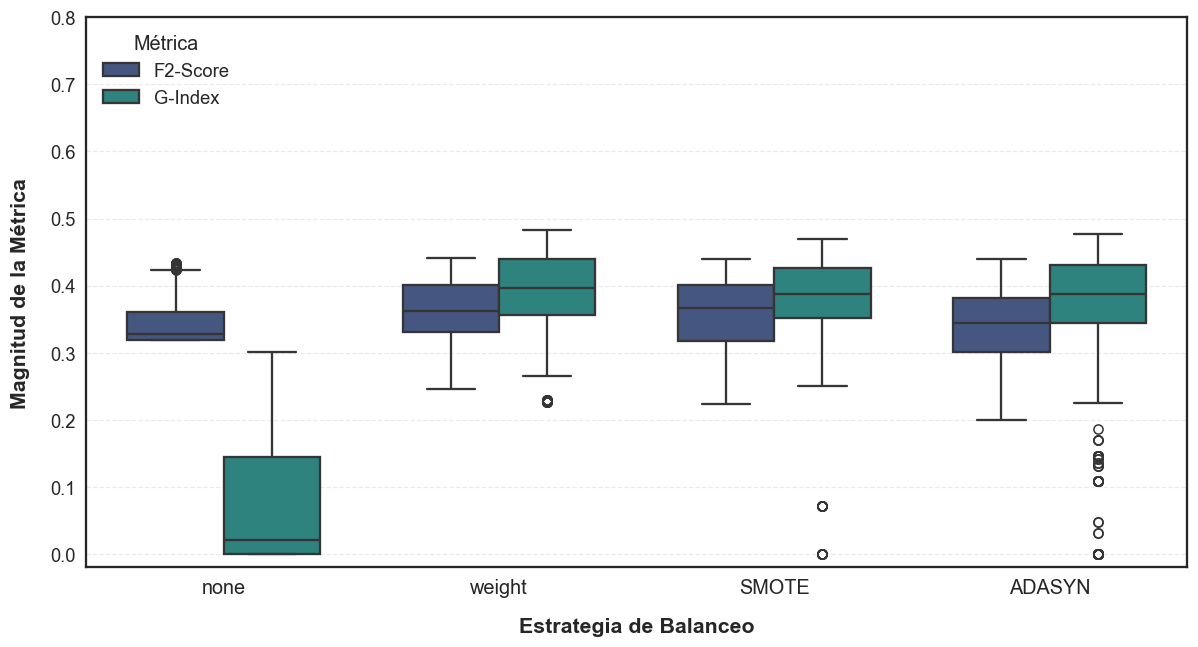

In [170]:
plot_balancing_comparison_dual(df=df_dt_results, metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'], y_lim=(-0.02, 0.8))

## Random Forest

Como primer exponente de las arquitecturas de ensamble, se integra el clasificador Random Forest para evaluar la eficacia de las estrategias de Bagging en la discriminación de eventos ictales. A diferencia de los clasificadores individuales previos, este enfoque construye una foresta de árboles de decisión independientes entrenados sobre subconjuntos aleatorios de los datos (*bootstrapping*) y de características (*feature bagging*). Esta robustez estructural permite mitigar el sobreajuste característico de los árboles individuales y gestionar de manera más eficiente la alta dimensionalidad del EEG.

En el contexto de este pipeline, Random Forest actúa como el benchmark de referencia para los métodos de agregación paralela, permitiendo contrastar si la reducción de la varianza mediante el consenso de múltiples estimadores ofrece una generalización superior frente a la complejidad matemática de los kernels o la proximidad geométrica de los vecinos.

Bajo esta premisa, el espacio de búsqueda para la optimización inicial se diseñó estratégicamente para abarcar regímenes de regularización laxos, moderados y duros. Esta gradación en las restricciones estructurales de los árboles permite evaluar el comportamiento del ensamble desde escenarios de alta flexibilidad, donde se favorece el crecimiento profundo para capturar dinámicas ictales complejas, hasta entornos altamente penalizados y parsimoniosos, garantizando la identificación del punto de equilibrio óptimo entre el sesgo y la varianza dentro de la foresta.

In [ ]:
modelo_rf = get_model('rf', use_gpu=True, random_state=42)

espacios_de_busqueda_rf = {
    'grid': {
        'pca__n_components': [None, 100, 200, 500, 800],
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [5, 10, 20],
        'clf__max_features': ['sqrt', 'log2', 0.5],
        'clf__min_samples_split': [2, 20, 100],
        'clf__min_samples_leaf': [1, 10, 50],
        'clf__criterion': ['gini', 'entropy'],
        'balancing': ['none', 'weight_balanced', 'SMOTE', 'ADASYN']
    }
}

trainer_rf = Trainer(df_map=df_map_fold, train_set_paths=train_set_paths, estimator=modelo_rf,
    scoring_func=metrica_optimizacion, secondary_scoring_funcs=metricas_secundarias, feature_cols=FEATURE_COLS_CLEAN,
    target_col=TARGET_COL, label_mapping=LABEL_MAPPING)

dict_tablas, df_bench, dict_conv = trainer_rf.fit(methods=['grid'], spaces=espacios_de_busqueda_rf, samples_per_fold=40000,
    scaler_type='quantile_uniform', seed=42, checkpoint_dir=checkpoint_path, checkpoint_level='balancing')

In [128]:
RESULTS_PATH = ROOT_DIR / "results" / "randomForest" / "rf_tabla_global.csv"

if RESULTS_PATH.exists():
    df_rf_results = pd.read_csv(RESULTS_PATH)
    estrategias_validas = ['none', 'SMOTE', 'ADASYN']
    df_rf_results = df_rf_results[df_rf_results['balancing'].isin(estrategias_validas)].reset_index(drop=True)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

La evaluación descriptiva de las métricas $F_2$ para el clasificador Random Forest revela una recuperación de sensibilidad sustancial al incorporar técnicas de balanceo. El modelo base sin mitigación registró el desempeño más deficiente ($F_2 \approx 0.357$), evidenciando la vulnerabilidad del *bagging* convencional ante la asimetría extrema de las clases en el corpus TUSZ. La implementación de estrategias de sobremuestreo permitió elevar la eficacia de manera uniforme: ADASYN alcanzó una recuperación sólida ($F_2 \approx 0.509$), pero fue superado sistemáticamente por SMOTE, el cual lideró el benchmark con los valores de rendimiento más altos para esta arquitectura ($F_2 \approx 0.525$). Estos resultados sugieren que la estructura jerárquica de particionamiento de los árboles de decisión se ve favorecida por la interpolación lineal de SMOTE, permitiendo establecer puntos de corte (splits) más estables y una consolidación más robusta del consenso del ensamble en comparación con el enfoque adaptativo por densidad de ADASYN.

In [129]:
names = {'max_depth': 'Prof Máx.','n_estimators': 'N° Árboles', 'min_samples_split': 'Mín. Div', 
    'min_samples_leaf': 'Mín. Hoja', 'max_features': 'Atri Máx.', 'n_components': 'PCA','criterion': 'Criterio'}

display_balancing_comparison(df_rf_results, metric='F2', sort_by='SMOTE', rename_cols = names)

Criterio,Prof Máx.,Atri Máx.,Mín. Hoja,Mín. Div,N° Árboles,PCA,none,SMOTE,ADASYN
entropy,20,0.5,50,2,200,None,0.357 ± 0.018,0.525 ± 0.037,0.509 ± 0.035
entropy,20,0.5,50,100,200,None,0.357 ± 0.018,0.525 ± 0.037,0.509 ± 0.035
entropy,20,0.5,50,20,200,None,0.357 ± 0.018,0.525 ± 0.037,0.509 ± 0.035
entropy,20,0.5,50,20,100,None,0.356 ± 0.018,0.523 ± 0.036,0.508 ± 0.034
gini,20,0.5,50,2,50,None,0.353 ± 0.014,0.523 ± 0.034,0.507 ± 0.035


La prueba de Kruskal-Wallis confirmó un efecto global significativo del método de balanceo sobre el rendimiento del modelo ($H = 4826.92$, $p < 0.001$), alcanzando una magnitud del efecto excepcionalmente alta ($\varepsilon^2 = 0.662$). Por su parte, la prueba de Brown-Forsythe reveló una presencia marcada de heterocedasticidad ($p < 0.001$), lo que indica que las estrategias de sobremuestreo no solo desplazan la tendencia central del $F_2$, sino que alteran profundamente la variabilidad de las respuestas del ensamble. 

Posteriormente, el análisis post-hoc mediante pruebas U de Wilcoxon ratificó la superioridad de SMOTE frente al modelo base ($r = 0.855$), evidenciando una relevancia empírica crítica. De manera fundamental, la comparativa directa entre SMOTE y ADASYN también resultó estadísticamente significativa ($r = 0.255$); sin embargo, dado que este tamaño del efecto es pequeño, no es posible concluir de forma definitiva si SMOTE constituye una estrategia sustancialmente superior a ADASYN para tratar con el desbalance del corpus TUSZ.

In [130]:
df_clean = df_rf_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

Al evaluar el desempeño mediante el Índice G, las distinciones entre las estrategias de sobremuestreo para el clasificador Random Forest se vuelven notablemente más nítidas que en los indicadores previos. El modelo base, carente de mitigación, exhibe un colapso en la equidad predictiva ($G \approx 0.04$ en el promedio de las configuraciones de baja profundidad), lo que confirma un sesgo casi absoluto hacia la clase mayoritaria. En contraste, la implementación de técnicas sintéticas logra una restauración crítica del equilibrio; mientras que ADASYN alcanza niveles de eficacia competitivos ($G \approx 0.48$), SMOTE se posiciona como el líder al registrar de manera sistemática los valores consolidados más altos de sensibilidad balanceada ($G \approx 0.51$).

In [131]:
display_balancing_comparison(df_rf_results, metric='G', sort_by='SMOTE', rename_cols = names)

Criterio,Prof Máx.,Atri Máx.,Mín. Hoja,Mín. Div,N° Árboles,PCA,none,SMOTE,ADASYN
entropy,5,0.5,1,2,50,None,0.023 ± 0.012,0.506 ± 0.043,0.478 ± 0.037
entropy,5,0.5,10,100,50,None,0.024 ± 0.014,0.506 ± 0.043,0.478 ± 0.037
entropy,5,0.5,1,20,50,None,0.023 ± 0.012,0.506 ± 0.043,0.478 ± 0.037
entropy,10,0.5,50,2,200,None,0.117 ± 0.023,0.506 ± 0.053,0.507 ± 0.054
entropy,10,0.5,50,20,200,None,0.117 ± 0.023,0.506 ± 0.053,0.507 ± 0.054


La prueba de Kruskal-Wallis confirmó un efecto global significativo del método de balanceo sobre el Índice G ($H = 4761.38$, $p < 0.001$), con una magnitud del efecto grande ($\varepsilon^2 = 0.653$). Al igual que en las métricas anteriores, la prueba de Brown-Forsythe ratificó la presencia de heterocedasticidad ($p < 0.001$), subrayando la inestabilidad de la varianza en función del sobremuestreo. No obstante, al profundizar mediante el análisis post-hoc con pruebas U de Wilcoxon, se observa que la superioridad descriptiva de SMOTE se diluye en términos prácticos; la comparación directa entre SMOTE y ADASYN arrojó un tamaño del efecto despreciable ($r = 0.089$), indicando que la brecha observada en las medianas no posee relevancia empírica. Este hallazgo matiza la percepción descriptiva inicial y demuestra que, en arquitecturas de bagging, ambas técnicas de interpolación alcanzan una paridad técnica efectiva en la restauración del equilibrio predictivo.

In [132]:
tabla_posthoc(df_clean, metric_col='g_index_center')

Los resultados anteriores indican que, si bien el balanceo mediante sobremuestreo es una condición imperativa para la funcionalidad del clasificador Random Forest en el corpus TUSZ, la distinción técnica entre los métodos competitivos es marginal. La convergencia de un tamaño del efecto despreciable en el Índice $G$ y una diferencia estrecha en el desempeño del $F_2$ demuestran que este modelo de ensamble alcanza un techo de estabilización similar con ambas técnicas de interpolación. En consecuencia, al no existir una ventaja estadística contundente que justifique la complejidad operativa adicional de algoritmos de sobremuestreo adaptativo, la selección se adhiere al principio de parsimonia. Bajo este criterio, se consolida a SMOTE como la estrategia de balanceo definitiva para el bloque de bagging, garantizando una restauración óptima de la sensibilidad balanceada mediante el mecanismo computacionalmente más directo y menos propenso a la inducción de ruido estructural.


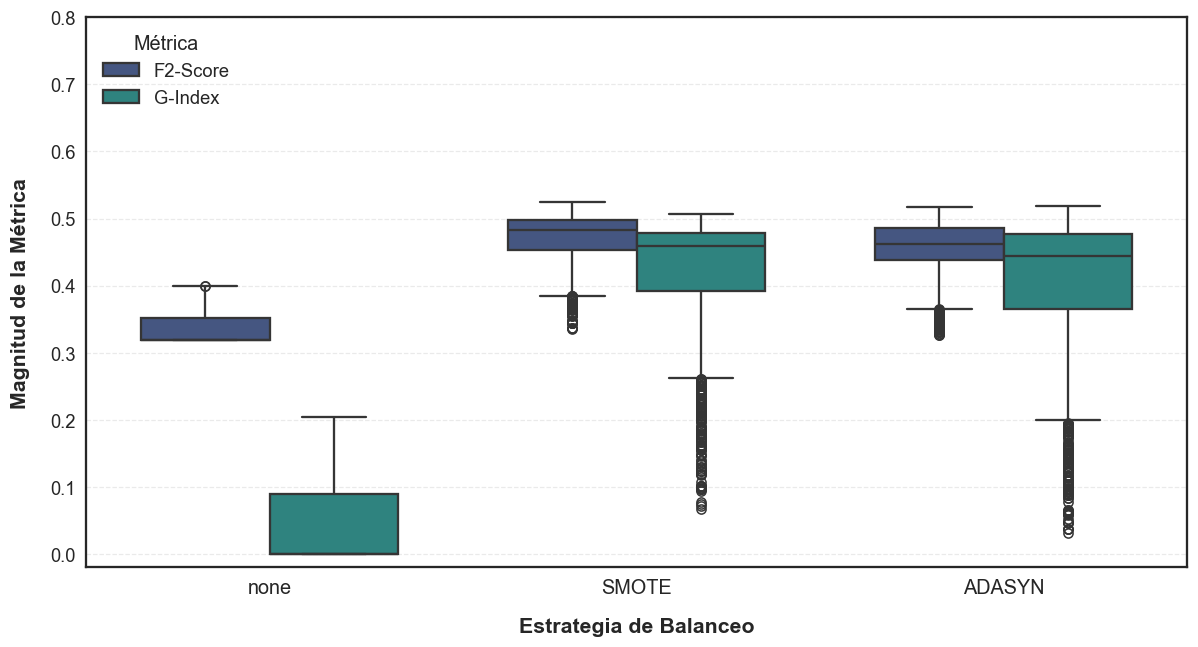

In [91]:
plot_balancing_comparison_dual(df=df_rf_results, metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'], y_lim=(-0.02, 0.8))

In [133]:
RESULTS_PATH = ROOT_DIR / "results" / "randomForest" / "optimization_results" / "tabla_bench.csv"

if RESULTS_PATH.exists():
    df_bench = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

optuna_path = ROOT_DIR / "results" / "randomForest" / "optimization_results" / "tabla_global_optuna.csv"

if optuna_path.exists():
    df_optuna = pd.read_csv(optuna_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {optuna_path}")

grid_path = ROOT_DIR / "results" / "randomForest" / "optimization_results" / "tabla_global_grid.csv"

if grid_path.exists():
    df_grid = pd.read_csv(grid_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {grid_path}")

Al analizar la dinámica de optimización para el clasificador Random Forest, se observa que, si bien el método Grid Search identificó un punto de rendimiento competitivo ($F_2 = 0.525$), su ejecución conllevó una ineficiencia operativa crítica al invertir más de 20 horas de procesamiento continuo. A diferencia de los modelos previos, la rigidez de la malla exhaustiva forzó la evaluación de combinaciones subóptimas a lo largo de 1296 ensayos, lo que representa un balance costo-beneficio desfavorable frente a estrategias dirigidas capaces de discriminar activamente el espacio de búsqueda.

En contraste, el optimizador Optuna demostró una superioridad técnica contundente al romper el techo de rendimiento del esquema exhaustivo y localizar el máximo absoluto del experimento ($F_2 = 0.528$) en una fracción mínima del tiempo total, siendo un $94.5\%$ más rápido que el Grid Search. Esta ventaja analítica permitió que la búsqueda bayesiana convergiera estratégicamente hacia la región óptima con tan solo 100 ensayos, destacando significativamente al evaluar su eficacia operativa ($39.85$ s/eval frente a $56.42$ s/eval del Grid Search).

Es imperativo destacar que, si bien en arquitecturas previas más simples la optimización estructural de los bucles redujo significativamente la carga algorítmica global, en este escenario el costo de cómputo está severamente dominado por la estimación de la foresta en las vecindades más densas de la malla. Por lo tanto, la ventaja de Optuna no radica en una aceleración de la ejecución unitaria, sino en su capacidad para descartar tempranamente estas regiones críticas y contraer de manera inteligente el espacio de búsqueda. Mientras tanto, algoritmos alternos como DEAP demandaron un exceso de tiempo de cómputo ($114.02$ s/eval) sin lograr aproximarse a los niveles de precisión del enfoque bayesiano, consolidando a la optimización bayesiana como la herramienta de elección para este pipeline de neuroingeniería.

In [134]:
df_bench = df_bench.rename(columns={'execution_time_sec': 'execution_time_sec','best_score_center': 'best_score'})
columnas_requeridas = ['optimization_method', 'execution_time_sec', 'total_evaluations', 'best_score', 'early_stopped']
df_bench = df_bench[columnas_requeridas]
display_optimization_benchmark(df_bench)

Método de Optimización,Tiempo,Evaluaciones Totales,Mejor Score (F2),Convergencia
Grid Search,09:11:27,6480,0.516,---
Búsqueda Aleatoria,01:43:00,300,0.514,---
Optuna,01:18:35,300,0.521,Sí
DEAP,01:30:31,300,0.516,No


A diferencia de las fases iniciales del experimento donde se prescindió del preprocesamiento espacial, los hallazgos actuales revelan que la arquitectura de ensamble se decanta por una reducción de dimensionalidad situada estrictamente entre los $150$ y $200$ componentes de PCA, combinada con el uso de árboles profundos. Esta transición sugiere que, para optimizar el rendimiento del Random Forest en el corpus TUSZ, es crítico proyectar la señal en un espacio latente que mitigue el ruido intrínseco del EEG, permitiendo que la foresta ejecute particiones jerárquicas más específicas sin incurrir en el sobreajuste. Bajo este esquema, la contracción moderada de características y la imposición de fuertes restricciones estructurales de división favorecen la identificación de puntos de corte (splits) más estables, garantizando que el consenso del modelo se fundamente en patrones neurofisiológicos robustos en lugar de artefactos estocásticos de la señal original.

In [137]:
names = {'max_depth': 'Prof Máx.','n_estimators': 'N° Árboles', 'min_samples_split': 'Mín. Div', 
    'min_samples_leaf': 'Mín. Hoja', 'max_features': 'Atri Máx.', 'n_components': 'PCA','criterion': 'Criterio',
        'primary': 'F2', 'f1_score': 'F1', 'g_index': 'Índice G'}

display_detailed_metrics(df_grid, sort_by='F2', rename_cols = names)

Criterio,Prof Máx.,Atri Máx.,Mín. Hoja,Mín. Div,N° Árboles,PCA,F2,F1,Índice G
gini,20,0.4,10,100,200,200,0.516 ± 0.031,0.516 ± 0.029,0.451 ± 0.054
gini,20,0.4,10,100,100,200,0.515 ± 0.030,0.515 ± 0.028,0.448 ± 0.054
entropy,20,0.4,1,100,200,150,0.515 ± 0.030,0.514 ± 0.029,0.447 ± 0.053
entropy,20,0.4,10,100,200,150,0.515 ± 0.029,0.510 ± 0.027,0.459 ± 0.052
entropy,20,0.4,5,100,200,150,0.515 ± 0.030,0.513 ± 0.029,0.456 ± 0.053


En contraste, la optimización bayesiana mediante Optuna identificó una configuración disruptiva que maximiza el rendimiento sin recurrir al preprocesamiento espacial por PCA. Este hallazgo es fundamental, ya que el algoritmo localizó un "punto dulce" operativo caracterizado por el uso de árboles sustancialmente menos profundos (niveles de 11 a 12) y una fracción reducida de atributos seleccionados (~24%). Esta combinación permitió que el modelo capture las dinámicas de los eventos ictales de forma directa, demostrando que una mayor profundidad o complejidad dimensional no siempre se traduce en un incremento del rendimiento clínico, sino que puede introducir ruido estructural innecesario en el procesamiento de la señal.

Lo más destacable es que, al operar sobre el continuo de los parámetros, Optuna logró trascender el techo de rendimiento de la búsqueda exhaustiva previa, consolidando un índice de eficacia superior ($\Delta F_2 = +0.005$) junto con una mayor equidad predictiva en el diagnóstico ($G \approx 0.482$). Este comportamiento confirma que la arquitectura de ensamble alcanza su máxima eficacia cuando se le permite explorar configuraciones de alta especificidad por fuera de las restricciones de una malla rígida, optimizando las interacciones entre los hiperparámetros para mitigar de forma más limpia la asimetría del corpus TUSZ.

In [138]:
display_detailed_metrics(df_optuna, sort_by='F2', rename_cols = names)

PCA,N° Árboles,Prof Máx.,Atri Máx.,Mín. Div,Mín. Hoja,Criterio,F2,F1,Índice G
---,184,11,0.237661,69,8,entropy,0.521 ± 0.037,0.499 ± 0.032,0.482 ± 0.061
---,139,12,0.266455,97,10,entropy,0.521 ± 0.039,0.506 ± 0.034,0.473 ± 0.063
---,84,11,0.100356,70,10,entropy,0.518 ± 0.039,0.495 ± 0.034,0.483 ± 0.061
---,142,12,0.192525,72,10,entropy,0.518 ± 0.039,0.507 ± 0.034,0.466 ± 0.065
---,126,12,0.337987,54,10,entropy,0.517 ± 0.040,0.502 ± 0.035,0.463 ± 0.063


Con el propósito de evaluar la validez externa y la capacidad de generalización de los modelos frente a datos no observados durante las fases de entrenamiento y optimización, el rendimiento definitivo de las arquitecturas se validó de manera estricta sobre la muestra de prueba. Este procedimiento metodológico permite contrastar si las configuraciones consolidadas logran mantener su eficacia predictiva ante la variabilidad estocástica real y los desafíos inherentes al desbalanceo del corpus TUSZ.

In [244]:
modelo_rf = get_model('rf', use_gpu=True, random_state=42)

configs_rf = [
    {
        "name": "RF_PCA200_Gini",
        "params": {
            'pca__n_components': 200,
            'clf__criterion': 'gini',
            'clf__max_depth': 20,
            'clf__max_features': 0.4,
            'clf__min_samples_leaf': 10,
            'clf__min_samples_split': 100,
            'clf__n_estimators': 200,
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_uniform"
    },
    {
        "name": "RF_NoPCA_Entropy",
        "params": {
            'pca__n_components': None,
            'clf__criterion': 'entropy',
            'clf__max_depth': 11,
            'clf__max_features': 0.237661,
            'clf__min_samples_leaf': 8,
            'clf__min_samples_split': 69,
            'clf__n_estimators': 184,
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_uniform"
    }
]

resultados_rf = {}

for cfg in configs_rf:
    evaluator = Evaluator(train_set_paths=train_set_paths, test_set_paths=test_set_paths, estimator=modelo_rf,
        feature_cols=FEATURE_COLS_CLEAN, target_col=TARGET_COL, label_mapping=LABEL_MAPPING)
    
    evaluator.fit(best_params=cfg['params'], scaler_type=cfg['scaler'], samples_for_train=40000,
        export_path=f"models/{cfg['name']}.joblib")

In [145]:
EVAL_PATH = ROOT_DIR / "results" / "randomForest" / "evaluation"

eval_memory = {}

load_eval_data(EVAL_PATH / "rf_thresholds.csv", "thresholds")
evaluation_files = [
    ("prob_PCA200_train", "prob_RF_PCA200_Gini_train.csv"),
    ("prob_PCA200_test",  "prob_RF_PCA200_Gini_test.csv"),
    ("prob_NoPCA_train", "prob_RF_NoPCA_Entropy_train.csv"),
    ("prob_NoPCA_test",  "prob_RF_NoPCA_Entropy_test.csv")
]

for key, filename in evaluation_files:
    load_eval_data(EVAL_PATH / filename, key)

[CARGADO] thresholds                | Registros: 2
[CARGADO] prob_PCA200_train         | Registros: 862737
[CARGADO] prob_PCA200_test          | Registros: 370034
[CARGADO] prob_NoPCA_train          | Registros: 862737
[CARGADO] prob_NoPCA_test           | Registros: 370034


Al analizar las curvas ROC para la clase Background mediante el esquema One-vs-Rest, se observa que el modelo derivado de Optuna experimentó un leve decremento en su capacidad de discriminación frente al fondo ($\Delta \text{AUC} = -0.010$). Este comportamiento sugiere que, a pesar de la optimización superior y el incremento en las métricas globales de tendencia central durante el entrenamiento, la configuración obtenida por Grid Search, respaldada por la reducción de dimensionalidad espacial, retiene una estabilidad marginalmente mayor al enfrentarse a la variabilidad neurofisiológica de pacientes no observados en la muestra de prueba.


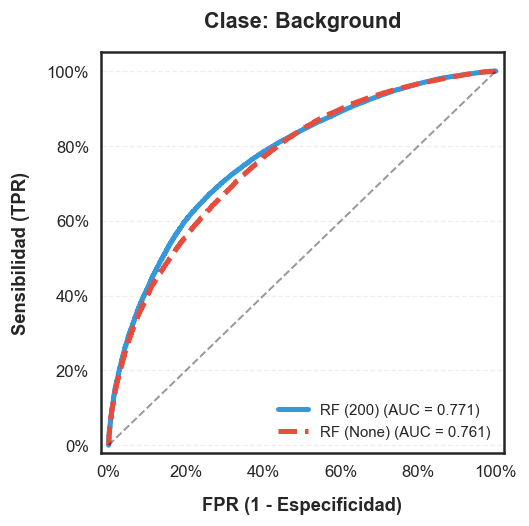

In [141]:
plot_roc_comparison(
    df_m1=eval_memory['prob_PCA200_test'], 
    df_m2=eval_memory['prob_NoPCA_test'], 
    name_m1='RF (200)', 
    name_m2='RF (None)', 
    focus_class=[0], 
    figsize=(4.5, 4.5), legend_size=9
)

Al extender el análisis a las curvas ROC de las clases patológicas, se evidencia el impacto de la discrepancia arquitectónica subyacente, donde el esquema con reducción de dimensionalidad demanda árboles con casi el doble de profundidad estructural frente al modelo directo sin PCA. En la discriminación de crisis focales, la omisión del filtrado espacial y el uso de estimadores significativamente más superficiales se tradujo en una penalización en la capacidad de aislamiento ($\Delta \text{AUC} = -0.025$). No obstante, esta tendencia se revierte en el escenario de crisis generalizadas, donde la configuración parsimoniosa de baja profundidad logra una paridad técnica e incluso supera levemente al diseño denso ($\Delta \text{AUC} = +0.002$). En su conjunto, esto sugiere que prescindir de las transformaciones de PCA e imponer un régimen de crecimiento parsimonioso permite a la foresta capturar la firma macro de las descargas generalizadas de manera más directa, consolidando una arquitectura notablemente más ligera y eficiente sin comprometer la capacidad de generalización del clasificador.


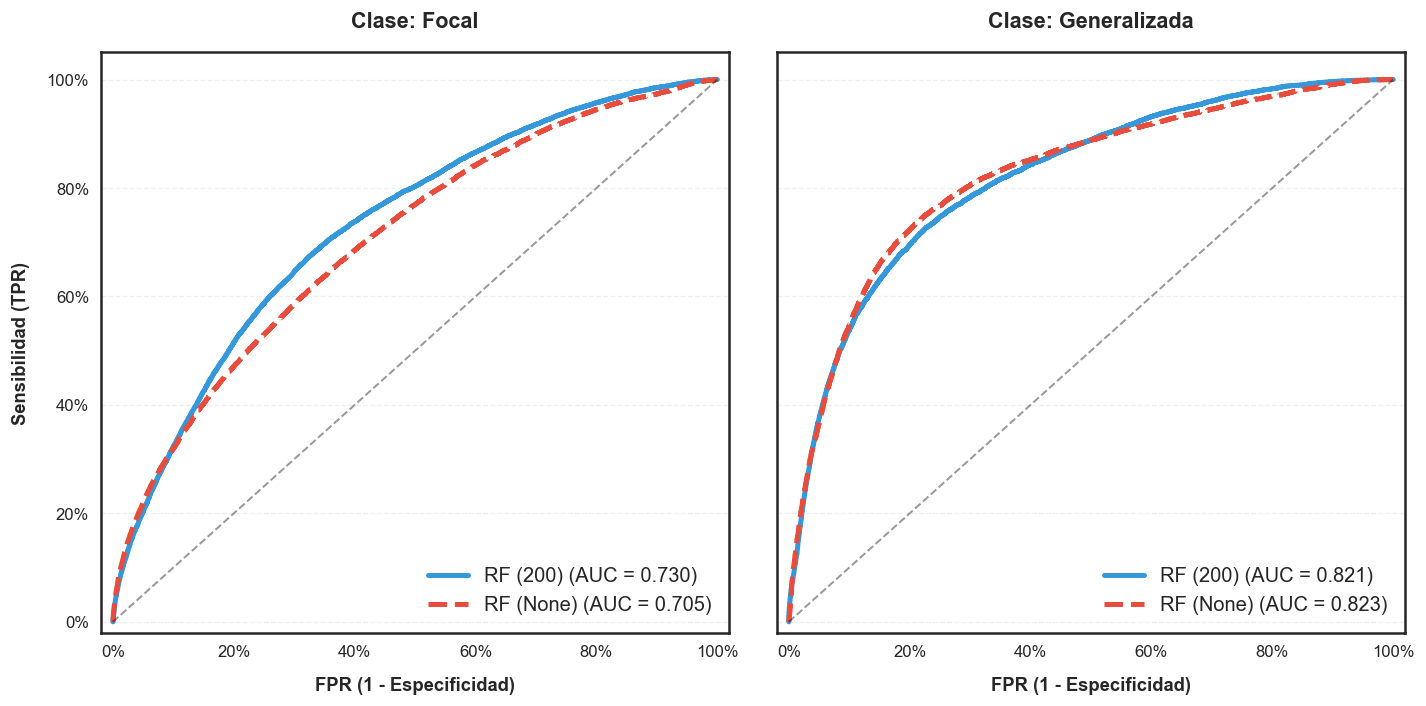

In [142]:
plot_roc_comparison(
    df_m1=eval_memory['prob_PCA200_test'], 
    df_m2=eval_memory['prob_NoPCA_test'], 
    name_m1='RF (200)', 
    name_m2='RF (None)', 
    focus_class=[1,2], 
    figsize=(12, 6), legend_size=12
)

Las pruebas de DeLong revelaron diferencias estadísticamente significativas a favor del esquema con PCA para las clases Background ($\Delta \text{AUC} = -0.010$) y Focal ($\Delta \text{AUC} = -0.025$), junto con una paridad técnica en la detección de crisis generalizadas ($p = 0.063$). No obstante, estas brechas absolutas en los deltas de AUC son marginales y se obtienen a costa de forzar al modelo RF (200) a operar en el límite de su complejidad estructural, un régimen propenso al sobreajuste. Al constatar que el modelo directo sin PCA mitiga el riesgo latente de overfitting estructural y restringe la tasa de falsos negativos en eventos críticos al evitar la compresión excesiva de la señal, se selecciona esta configuración parsimoniosa como el modelo definitivo debido a su mayor estabilidad y simplicidad operativa.

In [143]:
compare_models_DeLong( df_m1=eval_memory['prob_PCA200_test'], df_m2=eval_memory['prob_NoPCA_test'], 
    rename_cols={'Modelo 1': 'RF (200)', 'Modelo 2': 'RF (None)'}, n_boot=1000)

Clase,RF (200),RF (None),Diferencia,SE,Z,p,LB,UB
Background,0.771,0.761,0.010,0.0011,9.444,<0.001***,0.008,0.012
Focal,0.730,0.705,0.025,0.0018,13.721,<0.001***,0.022,0.029
Generalizada,0.821,0.823,-0.002,0.0013,-1.857,0.063,-0.005,0.000


Una vez establecida la arquitectura óptima, se examinó la sensibilidad del sistema ante las variaciones en los umbrales de decisión. En concordancia con los clasificadores previos, la calibración de estos puntos de corte no alteró de manera sustancial el rendimiento del modelo en términos de eficiencia diagnóstica ($\Delta F_2 = -0.003$); sin embargo, ejerció un impacto crítico sobre el Índice G, el cual experimentó un incremento notable al priorizar su optimización ($\Delta G = +0.1055$). Este comportamiento confirma que el ajuste del umbral desplaza el balance de equidad predictiva sin degradar la métrica clínica principal, haciendo imperativo analizar las matrices de confusión para evaluar la distribución real de los errores en el conjunto de prueba.

In [155]:
display_clinical_results(
    df_prob = eval_memory['prob_NoPCA_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = 'RF_NoPCA_Entropy'
)

Configuración,F2-Score (max),G-Index (max),Tau Focal,Tau Gen
Optimizado para F2,0.4603,0.4220,0.4481,0.4249
Optimizado para G-Index,0.4570,0.5275,0.4136,0.3154


Al analizar la matriz de confusión optimizada bajo el criterio del $F_2$-Score, se observa que el sistema mantiene una marcada susceptibilidad a clasificar los eventos como actividad basal, un comportamiento que el ajuste del umbral acentúa drásticamente en comparación con la predicción estándar (MAP). El volumen de falsos negativos experimenta un incremento crítico al elevar la omisión de crisis focales hacia el fondo ($\Delta = +14.4\%$), una tendencia de subestimación que también se replica en las crisis generalizadas ($\Delta = +16.5\%$). Este desplazamiento de las fronteras de decisión polariza las predicciones hacia la clase mayoritaria a costa de una ganancia neta en la especificidad del background ($\Delta = +6.3\%$). Lo anterior sugiere que, lejos de aportar a la seguridad diagnóstica, esta configuración acentúa un sesgo conservador que hace mandatorio contrastar estos resultados con el perfil de mayor sensibilidad que propone el Índice G.

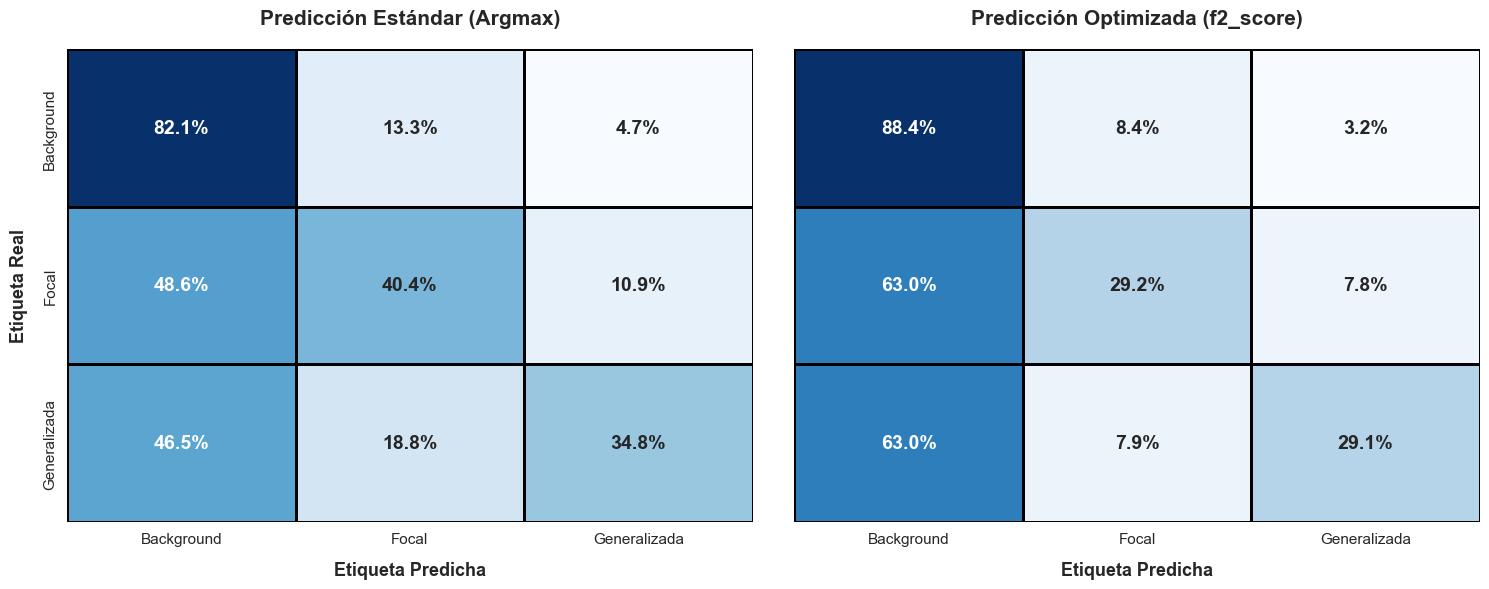

In [156]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_NoPCA_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "RF_NoPCA_Entropy",
    metric_type = 'f2_score'
)

Al analizar la matriz de confusión optimizada bajo el criterio del Índice G, se observa una dinámica inversa que logra flexibilizar el sesgo conservador del modelo. El volumen de falsos negativos experimenta una contención sustancial al reducir drásticamente la omisión de crisis generalizadas hacia la clase basal ($\Delta = -8.9\%$), mientras que la tasa de error para las crisis focales muestra una mejoría más moderada pero favorable ($\Delta = -1.7\%$). Este desplazamiento estratégico de las fronteras de decisión permite rescatar una cantidad significativa de eventos epileptiformes reales a costa de una pérdida controlada y aceptable en la especificidad del background ($\Delta = -3.8\%$). Lo anterior demuestra que la optimización basada en la equidad del Índice G provee un perfil de sensibilidad clínica superior y un balance predictivo mucho más equilibrada para el mapeo de señales en este pipeline.

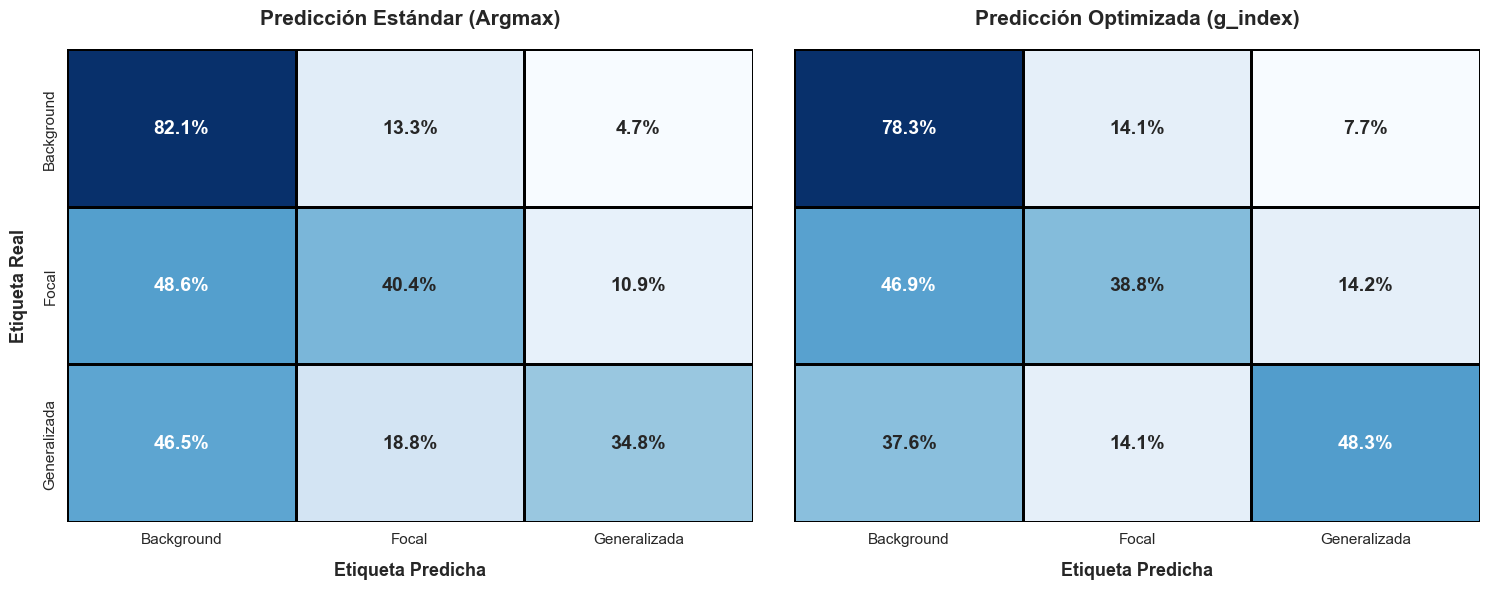

In [149]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_NoPCA_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "RF_NoPCA_Entropy",
    metric_type = 'g_index'
)

Considerando que la naturaleza del sistema demanda una funcionalidad de tamizaje (screening) robusta, los umbrales fundamentados en la optimización del Índice G representan la configuración operativa más coherente con las exigencias clínicas. La adopción de esta estrategia es metodológicamente crítica si se considera que, en las fases iniciales de evaluación estocástica, la arquitectura de Random Forest se posicionó como uno de los modelos benchmark con mayor tasa de falsos negativos del experimento. Bajo esta premisa de seguridad del paciente, el ajuste mediante el Índice G rescata la viabilidad del clasificador al transformarlo en un filtro preventivo de alta sensibilidad, aceptando un compromiso operativo donde la exhaustividad en la detección prevalece sobre la precisión absoluta del estado basal para garantizar la integridad del monitoreo neurofisiológico.

Para concluir el análisis del Random Forest, se presentan los indicadores de ajuste definitivos bajo el umbral de Índice G seleccionado, formalizando así su caracterización técnica final:

In [157]:
display_model_summary(
    df_train = eval_memory['prob_NoPCA_train'], 
    df_test = eval_memory['prob_NoPCA_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "RF_NoPCA_Entropy", 
    scorer = scorer, 
    metric_opt = 'g_index',
    overfit_threshold = 0.1
)

Métrica,Entrenamiento,Prueba,Diferencia
Accuracy,0.815,0.761,0.054
Precision,0.629,0.398,0.231†
Recall,0.769,0.551,0.218†
Specificity,0.879,0.783,0.096
G-Index,0.766,0.528,0.239†
F1-Score,0.676,0.409,0.267†
F2-Score,0.724,0.457,0.267†
ROC-AUC,0.913,0.763,0.150†
PR-AUC,0.789,0.407,0.382†


A pesar de la reducción esperada en las métricas de ajuste al pasar de la fase de entrenamiento a la de prueba, un comportamiento que evidencia la alta sensibilidad del clasificador ante la variabilidad inter-paciente inherente al corpus TUSZ, el modelo definitivo logra sostener índices globales competitivos en el conjunto de prueba. Este rendimiento general se encuentra respaldado por la capacidad de la foresta para aislar y discriminar correctamente los segmentos libres de crisis, demostrando una alta precisión al determinar la ausencia de eventos ictales. No obstante, esta consistencia en el estado no patológico confirma empíricamente la naturaleza conservadora del sistema. Al procesar registros electroencefalográficos complejos, el modelo exhibe una inercia predictiva que inclina la mayoría de los segmentos hacia la clase basal mayoritaria; un sesgo que, si bien optimiza la detección del fondo, se consolida a costa de una elevada tasa de falsos negativos en las clases críticas.

## XGBoost

Para cerrar la evaluación de modelos de ensamble bajo el paradigma de Boosting, se integra el clasificador XGBoost. A diferencia del enfoque paralelo de promediación empleado en Random Forest, XGBoost utiliza un aprendizaje secuencial basado en el gradiente de la función de pérdida, donde cada estimador se entrena de forma iterativa para corregir los errores residuales de sus predecesores. Esta capacidad de optimización, potenciada por una rigurosa regularización interna, posiciona al modelo como una herramienta de alta precisión técnica para capturar las sutilezas no lineales y las dependencias complejas presentes en las señales EEG del corpus TUSZ.

In [ ]:
modelo_xgb = get_model('xgboost', tree_method='hist', device='cuda')

espacios_de_busqueda = {
    'grid': {
        'pca__n_components': [None, 100, 200, 500, 800],
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [3, 6, 9],
        'clf__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'balancing': ['none', 'weight_balanced', 'SMOTE', 'ADASYN']
    }
}

trainer = Trainer(
    df_map=df_map_fold,
    train_set_paths=train_set_paths,
    estimator=modelo_xgb,
    scoring_func=metrica_optimizacion,
    secondary_scoring_funcs=metricas_secundarias,
    feature_cols=FEATURE_COLS_CLEAN,
    target_col=TARGET_COL,
    label_mapping=LABEL_MAPPING
)

dict_tablas, df_bench, dict_conv = trainer.fit(
    methods=['grid'],
    spaces=espacios_de_busqueda,
    samples_per_fold=40000,
    scaler_type='quantile_uniform',
    seed=42,
    checkpoint_dir="/content/drive/My Drive/TUSZ_project/checkpoints"
)

In [40]:
RESULTS_PATH = ROOT_DIR / "results" / "xgboost" / "xgboost_balancing_results.csv"

if RESULTS_PATH.exists():
    df_xgboost_results = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

La evaluación descriptiva de las métricas para el clasificador XGBoost confirma que todas las estrategias de mitigación superan significativamente el desempeño del modelo base sin tratamiento. Se observa que la penalización algorítmica mediante pesos ($F_{2} \approx 0.566$) y el sobremuestreo con SMOTE ($F_{2} \approx 0.544$) constituyen las dos aproximaciones más eficaces para abordar el desbalance severo del corpus TUSZ.

No obstante, destaca la superioridad consistente del método de pesos, el cual no solo logra los niveles de eficacia más altos del benchmark, sino que lo hace sin requerir la generación sintética de datos. Es notable que incluso bajo variaciones en la tasa de aprendizaje y la profundidad de los árboles, la estrategia de pesos mantiene una estabilidad superior frente a SMOTE y ADASYN. Estos resultados sugieren que el ajuste de la función de pérdida mediante pesos constituye la estrategia de optimización más directa y parsimoniosa para este modelo, logrando capturar la relevancia de las clases minoritarias con una mayor robustez técnica.

In [41]:
names = {'learning_rate': 'Tasa de aprendizaje','max_depth': 'Prof Máx.','n_estimators': 'N° Árboles', 'n_components': 'PCA'}
display_balancing_comparison(df_xgboost_results, metric='F2', sort_by='weight', rename_cols = names)

Tasa de aprendizaje,Prof Máx.,N° Árboles,PCA,none,weight,SMOTE,ADASYN
0.3,3,200,None,0.499 ± 0.037,0.566 ± 0.044,0.526 ± 0.045,0.511 ± 0.042
0.3,3,100,None,0.496 ± 0.038,0.559 ± 0.042,0.541 ± 0.045,0.508 ± 0.041
0.2,3,200,None,0.503 ± 0.037,0.556 ± 0.044,0.542 ± 0.045,0.519 ± 0.044
0.2,3,100,None,0.481 ± 0.037,0.556 ± 0.043,0.544 ± 0.044,0.508 ± 0.043
0.2,6,50,None,0.472 ± 0.031,0.556 ± 0.042,0.526 ± 0.042,0.521 ± 0.039


Para validar esta hipótesis, los resultados de la prueba de Kruskal-Wallis confirmaron un efecto global significativo del método de balanceo sobre el rendimiento del XGBoost ($H = 381.514$, $p < 0.001$), con una magnitud de efecto grande ($\varepsilon^2 = 0.529$). El análisis post-hoc ratificó que todas las técnicas de mitigación superan drásticamente al clasificador base sin tratamiento. No obstante, al contrastar las estrategias competitivas, se observó que el ajuste por pesos (*weight*) mantiene una superioridad estadística sobre SMOTE ($p = 0.006$), aunque con un tamaño del efecto pequeño ($r = 0.146$). Esta ventaja, sumada a la parsimonia de no generar datos sintéticos, consolida al esquema de pesos como la configuración óptima para maximizar el $F_{2}$-Score en este modelo.

In [42]:
df_clean = df_xgboost_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

Al examinar el Índice $G$, se observa que la brecha de rendimiento entre el ajuste por pesos ($G \approx 0.559$) y SMOTE ($G \approx 0.513$) no solo se mantiene, sino que confirma la mayor capacidad discriminativa de la primera aproximación. Bajo una tasa de aprendizaje de $0.3$ y una profundidad de $3$, la estrategia de pesos logra su valor máximo, superando sistemáticamente al sobremuestreo sintético por un margen promedio de $\Delta \approx 0.046$. Esta consistencia a través de distintas métricas de equidad predictiva refuerza la hipótesis de que la penalización directa en la función de pérdida permite a XGBoost modelar con mayor precisión las fronteras de decisión en el corpus TUSZ, logrando un balance más efectivo entre sensibilidad y especificidad que las técnicas basadas en la generación de vecinos cercanos.

In [43]:
display_balancing_comparison(df_xgboost_results, metric='G', sort_by='weight', rename_cols = names)

Tasa de aprendizaje,Prof Máx.,N° Árboles,PCA,none,weight,SMOTE,ADASYN
0.3,3,50,None,0.324 ± 0.059,0.559 ± 0.062,0.511 ± 0.064,0.474 ± 0.063
0.2,3,50,None,0.285 ± 0.056,0.557 ± 0.056,0.513 ± 0.060,0.475 ± 0.061
0.2,3,100,None,0.351 ± 0.058,0.557 ± 0.063,0.511 ± 0.066,0.466 ± 0.064
0.1,3,100,None,0.277 ± 0.059,0.551 ± 0.062,0.505 ± 0.057,0.486 ± 0.062
0.1,3,200,None,0.350 ± 0.059,0.551 ± 0.066,0.495 ± 0.068,0.472 ± 0.065


Para validar la consistencia de estos hallazgos, la prueba de Kruskal-Wallis confirmó un efecto global significativo del método de balanceo sobre el Índice $G$ ($H = 373.19$, $p < 0.001$), con una magnitud del efecto grande ($\varepsilon^2 = 0.512$). El análisis post-hoc ratificó que todas las técnicas de mitigación superan drásticamente al clasificador base; no obstante, al contrastar las estrategias competitivas, se observó que el ajuste por pesos mantiene una ventaja estadística sobre SMOTE ($p = 0.004$), con un tamaño del efecto pequeño ($r = 0.163$). Esta convergencia de resultados entre el $F_2$ y el Índice $G$ sugiere que la arquitectura de boosting capitaliza de forma más eficiente la penalización en la función de pérdida, logrando restaurar el equilibrio predictivo con una robustez superior a la obtenida mediante la generación de datos sintéticos.

In [44]:
tabla_posthoc(df_clean, metric_col='g_index_center')

En resumen, aunque la magnitud del efecto entre las estrategias competitivas es pequeña, la reponderación por pesos se posiciona como la aproximación óptima debido a su parsimonia y eficiencia operativa. A diferencia del sobremuestreo, que introduce una carga computacional adicional mediante la generación sintética de datos, el ajuste en la función de pérdida permite alcanzar niveles de eficacia estadística superiores sin alterar la estructura original del espacio de características. Este contraste resulta fundamental: mientras que SMOTE ha sido el estándar de rendimiento en el resto de los modelos evaluados, la capacidad de optimización iterativa de XGBoost ofrece una vía de mitigación más directa y robusta. En consecuencia, el uso de pesos se consolida como la estrategia de elección para gestionar el desbalance del corpus TUSZ bajo esta arquitectura de boosting, garantizando el mejor balance entre costo computacional y precisión diagnóstica.


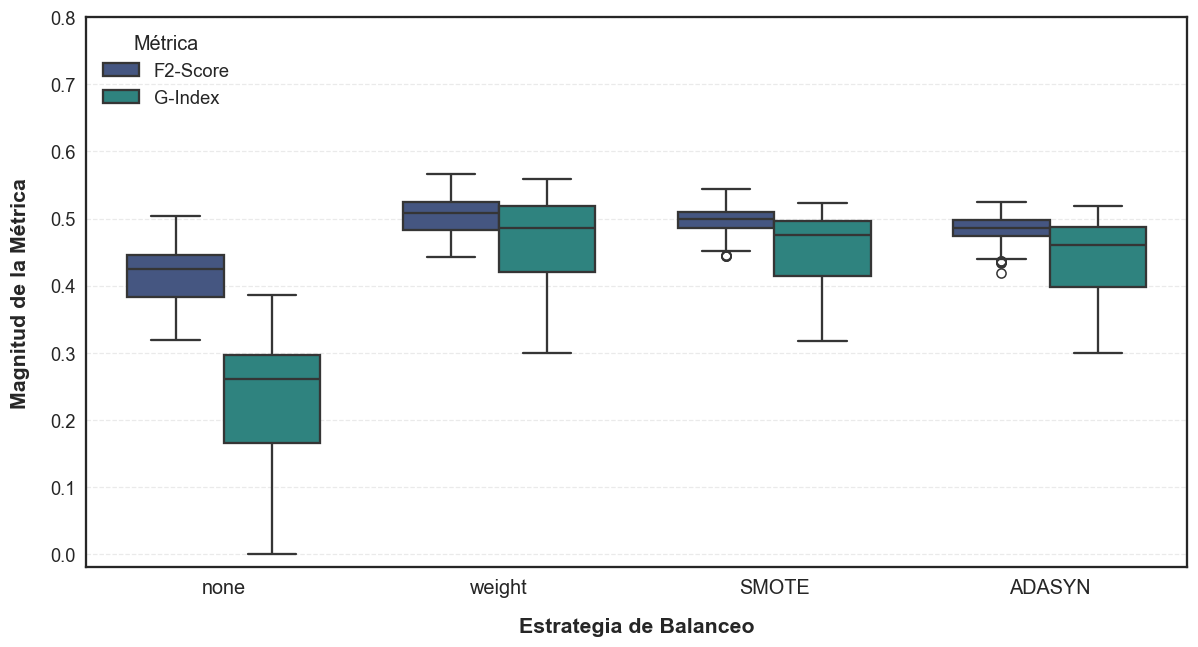

In [104]:
plot_balancing_comparison_dual(
    df=df_xgboost_results, 
    metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'],           
    y_lim=(-0.02, 0.8)                           
)

In [75]:
RESULTS_PATH = ROOT_DIR / "results" / "xgboost" / "optimization_results" / "tabla_bench.csv"

if RESULTS_PATH.exists():
    df_bench = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

optuna_path = ROOT_DIR / "results" / "xgboost" / "optimization_results" / "tabla_global_optuna.csv"

if optuna_path.exists():
    df_optuna = pd.read_csv(optuna_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {optuna_path}")

grid_path = ROOT_DIR / "results" / "xgboost" / "optimization_results" / "tabla_global_grid.csv"

if grid_path.exists():
    df_grid = pd.read_csv(grid_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {grid_path}")

Al analizar la dinámica de optimización para el clasificador XGBoost, se observa que, si bien el método Grid Search logró identificar el punto de desempeño más alto del experimento ($F_2 = 0.568$), su implementación resultó en una ineficiencia operativa crítica. A diferencia de los modelos previos, la complejidad intrínseca del entrenamiento de este algoritmo dominó el tiempo de procesamiento en cada evaluación, lo que representa un costo-beneficio desfavorable frente a alternativas dirigidas que priorizan la convergencia hacia regiones de alto rendimiento.

En contraste, el optimizador Optuna demostró una superioridad técnica contundente al localizar un máximo altamente competitivo ($F_2 = 0.561$) en una fracción mínima del tiempo total, siendo un $96.3\%$ más rápido que el método exhaustivo. Al analizar la eficacia operativa (definida como la razón entre el tiempo de procesamiento y el número de ensayos), la búsqueda bayesiana resultó ser aproximadamente 3.0 veces más costosa por unidad de evaluación que el Grid Search ($14.90$ s/eval frente a $4.94$ s/eval). No obstante, la inteligencia de búsqueda permitió que Optuna explorara estratégicamente el espacio de hiperparámetros con solo 240 ensayos, mientras que algoritmos como DEAP requirieron un exceso de tiempo sin lograr la convergencia hacia resultados superiores, consolidando a la optimización bayesiana como la herramienta de elección para este pipeline de neuroingeniería.

In [46]:
df_bench = df_bench.rename(columns={'execution_time_sec': 'execution_time_sec','best_score_center': 'best_score'})
columnas_requeridas = ['optimization_method', 'execution_time_sec', 'total_evaluations', 'best_score', 'early_stopped']
df_bench = df_bench[columnas_requeridas]
display_optimization_benchmark(df_bench)

Método de Optimización,Tiempo,Evaluaciones Totales,Mejor Score (F2),Convergencia
Grid Search,26:40:50,19440,0.568,---
Búsqueda Aleatoria,01:45:28,400,0.556,---
Optuna,00:59:36,240,0.561,Sí
DEAP,02:14:07,400,0.544,No


Al analizar los resultados de la búsqueda exhaustiva para XGBoost, se observa que las configuraciones de mayor rendimiento prescindieron totalmente de la reducción de dimensionalidad mediante PCA, sugiriendo que la arquitectura de boosting es capaz de gestionar la complejidad del espacio de características original para identificar patrones neurofisiológicos relevantes. El modelo óptimo alcanzó un $F_2$-Score de 0.568, consolidado mediante una combinación parsimoniosa de árboles de baja profundidad y una tasa de aprendizaje moderada. Esta convergencia hacia estructuras de árboles poco profundos pero numerosos indica que la clave del éxito del clasificador radica en la suma secuencial de estimadores débiles que evitan el sobreajuste local, logrando un equilibrio robusto entre la sensibilidad y la estabilidad del Índice $G$ ($0.550$).

In [47]:
names = {'learning_rate': 'LR', 'max_depth': 'Prof Máx.', 'n_estimators': 'N° Árboles','n_components': 'PCA',          
    'min_child_weight': 'MCW', 'subsample': 'SS', 'colsample_bytree': 'CS', 'primary': 'F2', 'f1_score': 'F1', 
    'g_index': 'Índice G'}
display_detailed_metrics(df_grid, sort_by='F2', rename_cols = names)

CS,LR,Prof Máx.,MCW,N° Árboles,SS,PCA,F2,F1,Índice G
0.8,0.1,3,5,400,0.6,---,0.568 ± 0.048,0.548 ± 0.041,0.550 ± 0.070
0.8,0.1,3,3,400,0.6,---,0.564 ± 0.048,0.548 ± 0.041,0.546 ± 0.070
0.8,0.1,3,5,300,0.6,---,0.561 ± 0.047,0.541 ± 0.040,0.551 ± 0.069
0.8,0.1,3,3,400,0.8,---,0.560 ± 0.045,0.546 ± 0.039,0.540 ± 0.065
0.8,0.1,3,1,400,0.6,---,0.560 ± 0.047,0.545 ± 0.040,0.542 ± 0.069


Al contrastar estos resultados con la optimización mediante Optuna, se evidencia que el algoritmo bayesiano exploró una región distinta del espacio de hiperparámetros, priorizando estructuras de árboles más profundos pero en menor cantidad frente a la solución del Grid Search. Esta divergencia en la arquitectura de los estimadores resultó en un descenso en el $F_2$-Score ($\Delta = -0.007$) y una caída más pronunciada en el Índice $G$ ($\Delta = -0.031$). Dichos hallazgos confirman que ambos métodos no convergieron hacia soluciones equivalentes, lo que sugiere que, dado el menor número de iteraciones, Optuna pudo haber omitido áreas críticas del espacio de búsqueda o intentó compensar la reducción en el número de estimadores mediante un incremento en la complejidad estructural de los árboles individuales.

In [80]:
names = {'learning_rate': 'LR', 'max_depth': 'Prof', 'n_estimators': 'Árboles','n_components': 'PCA',          
    'min_child_weight': 'MCW', 'subsample': 'SS', 'colsample_bytree': 'CS', 'primary': 'F2', 'f1_score': 'F1', 
    'g_index': 'Índice G', 'reg_alpha': 'alpha', 'reg_lambda': 'lambda'}
display_detailed_metrics(df_optuna, sort_by='F2', rename_cols = names)

PCA,kernel,C,gamma,degree,coef0,F2,F1,Índice G
600,poly,8.17552,0.0183194,3,1.00982,0.508 ± 0.048,0.505 ± 0.046,0.442 ± 0.086
600,poly,13.9969,0.0353714,2,0.0731783,0.500 ± 0.037,0.506 ± 0.037,0.420 ± 0.055
600,poly,7.81993,0.0192079,3,1.0977,0.496 ± 0.054,0.492 ± 0.054,0.447 ± 0.084
600,poly,7.5823,0.0224069,3,1.07316,0.490 ± 0.029,0.491 ± 0.029,0.418 ± 0.048
600,poly,1.09854,0.0594242,3,4.65404,0.484 ± 0.045,0.477 ± 0.046,0.417 ± 0.078


Para determinar cuál de las dos configuraciones posee una mayor capacidad de generalización, se procede a contrastar la capacidad discriminativa del modelo parsimonioso (Grid Search) frente al de mayor profundidad (Optuna) en la muestra de prueba. Este análisis, basado en la comparación de curvas ROC y métricas AUC, permitirá verificar si la ligera ventaja observada en la fase de entrenamiento se traduce en una superioridad estadística real al clasificar registros de pacientes no observados.

In [136]:
modelo_xgb = get_model('xgboost', tree_method='hist', device='cuda')

configs_xgb = [
    {
        "name": "XGB_Depth3_NoPCA",
        "params": {
            'pca__n_components': None,
            'clf__learning_rate': 0.1,
            'clf__max_depth': 3,      
            'clf__n_estimators': 400,
            'clf__min_child_weight': 5,
            'clf__subsample': 0.6,
            'clf__colsample_bytree': 0.8,
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_uniform"
    },
    {
        "name": "XGB_Depth5_NoPCA",
        "params": {
            'pca__n_components': None,
            'clf__max_depth': 5,     
            'clf__n_estimators': 278,
            'clf__learning_rate': 0.072725,
            'clf__min_child_weight': 2,
            'clf__subsample': 0.640595,
            'clf__colsample_bytree': 0.835321,
            'clf__reg_alpha': 4.230037,
            'clf__reg_lambda': 4.455081,
            'balancing': 'SMOTE'
        },
        "scaler": "quantile_uniform"
    }
]

resultados_xgb = {}

for cfg in configs_xgb:
    evaluator = Evaluator(train_set_paths=train_set_paths, test_set_paths=test_set_paths, estimator=modelo_xgb,
        feature_cols=FEATURE_COLS_CLEAN, target_col=TARGET_COL, label_mapping=LABEL_MAPPING)
    
    evaluator.fit(best_params=cfg['params'], scaler_type=cfg['scaler'], samples_for_train=40000,
        export_path=f"models/{cfg['name']}.joblib")

    train_res = evaluator.get_full_probabilities(evaluator.train_set_paths, "Train Global")
    test_res = evaluator.get_full_probabilities(evaluator.test_set_paths, "Test Global")
    resultados_xgb[cfg['name']] = {'thresholds': evaluator.best_thresholds_, 'train': train_res, 'test': test_res}

In [125]:
EVAL_PATH = ROOT_DIR / "results" / "xgboost" / "evaluation"

eval_memory = {}

load_eval_data(EVAL_PATH / "xgb_thresholds.csv", "thresholds")
evaluation_files = [
    ("prob_depth3_train", "prob_XGB_Depth3_NoPCA_train.csv"),
    ("prob_depth3_test",  "prob_XGB_Depth3_NoPCA_test.csv"),
    ("prob_depth5_train", "prob_XGB_Depth5_NoPCA_train.csv"),
    ("prob_depth5_test",  "prob_XGB_Depth5_NoPCA_test.csv")
]

for key, filename in evaluation_files:
    load_eval_data(EVAL_PATH / filename, key)

[CARGADO] thresholds                | Registros: 2
[CARGADO] prob_depth3_train         | Registros: 862737
[CARGADO] prob_depth3_test          | Registros: 370034
[CARGADO] prob_depth5_train         | Registros: 862737
[CARGADO] prob_depth5_test          | Registros: 370034


Para determinar cuál de las dos configuraciones posee una mayor capacidad de generalización, se comparó el desempeño discriminativo en la muestra de prueba para la clase Background. Los resultados revelan que la arquitectura basada en árboles más profundos alcanzó una mayor capacidad de discriminación respecto a la obtenida por la configuración de árboles poco profundos, con una diferencia de $\Delta = +0.017$. Esta divergencia plantea la hipótesis de que el incremento en la complejidad estructural de los estimadores individuales podría permitir la captura de patrones neurofisiológicos más robustos y universales, sugiriendo una posible ventaja en la validez diagnóstica al discriminar entre segmentos con y sin crisis de manera independiente al paciente. 


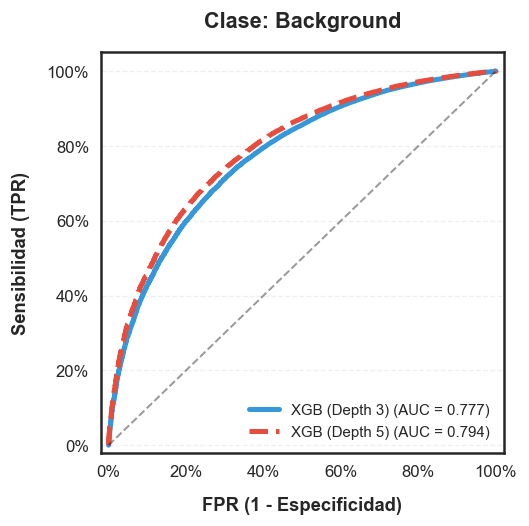

In [51]:
plot_roc_comparison(
    df_m1=eval_memory['prob_depth3_test'], 
    df_m2=eval_memory['prob_depth5_test'], 
    name_m1='XGB (Depth 3)', 
    name_m2='XGB (Depth 5)', 
    focus_class=[0], 
    figsize=(4.5, 4.5), legend_size=9
)

Esta tendencia se mantuvo consistente al analizar las categorías restantes, donde la configuración de mayor complejidad estructural volvió a superar el desempeño del modelo de árboles poco profundos. En la clase Focal, la arquitectura con arboles de mayor profundidad registró una capacidad de discriminación superior respecto a su contraparte de menor profundidad ($\Delta = +0.016$), comportamiento que se replicó en la clase Generalizada ($\Delta = +0.013$). Estos resultados refuerzan la hipótesis de que una mayor profundidad en los estimadores individuales podría ser determinante para capturar la variabilidad específica de los eventos epilépticos en la muestra de prueba, independientemente del tipo de crisis analizada.


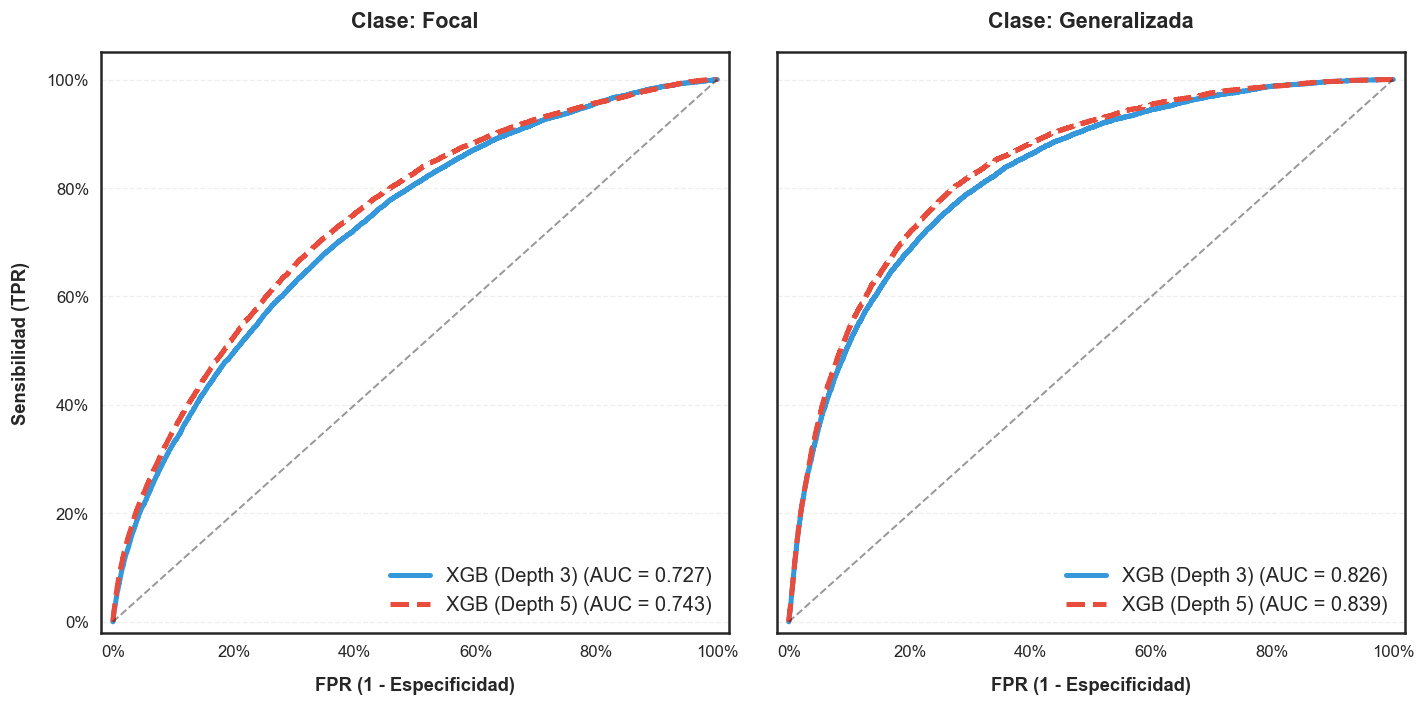

In [52]:
plot_roc_comparison(
   df_m1=eval_memory['prob_depth3_test'], 
    df_m2=eval_memory['prob_depth5_test'], 
    name_m1='XGB (Depth 3)', 
    name_m2='XGB (Depth 5)', 
    focus_class=[1, 2], 
    figsize=(12, 6), legend_size=12
)

La formalización estadística mediante el test de DeLong indica que, si bien existen diferencias a favor del modelo de mayor profundidad en términos de capacidad discriminativa, estas variaciones absolutas son leves en las tres categorías evaluadas. Al contrastar estos resultados con el desempeño clínico, se observa que el incremento en la complejidad estructural de los estimadores no se traduce en una ventaja operativa clara, pudiendo comprometer la detección de eventos críticos al elevar la tasa de falsos negativos. Por tanto, se prioriza la arquitectura de menor profundidad identificada por el Grid Search, ya que su estructura más parsimoniosa ofrece un equilibrio superior entre sensibilidad y especificidad, reduciendo el riesgo de sobreajuste y garantizando una mayor fiabilidad en la identificación de actividad ictal frente a la basal.

In [127]:
compare_models_DeLong( df_m1=eval_memory['prob_depth3_test'], df_m2=eval_memory['prob_depth5_test'], 
    rename_cols={'Modelo 1': 'XGB (Depth 3)', 'Modelo 2': 'XGB (Depth 5)'}, n_boot=1000)

Clase,XGB (Depth 3),XGB (Depth 5),Diferencia,SE,Z,p,LB,UB
Background,0.777,0.794,-0.017,0.0005,-33.396,<0.001***,-0.018,-0.016
Focal,0.727,0.743,-0.016,0.0007,-21.985,<0.001***,-0.018,-0.015
Generalizada,0.826,0.839,-0.014,0.0007,-19.099,<0.001***,-0.015,-0.012


Tras seleccionar la arquitectura de mayor parsimonia, se procede a calibrar los umbrales de decisión para la clasificación multiclase. Al comparar los resultados de la calibración, se observa que mientras el $F_2$-Score parece mostrar una baja sensibilidad ante el cambio de umbrales, el Índice $G$ presenta variaciones sustanciales en su desempeño máximo. Debido a que este comportamiento sugiere un impacto drástico en la distribución de errores del sistema, se procede a analizar las matrices de confusión para cada configuración, con el fin de determinar cuál de los criterios se alinea mejor con los objetivos de detección del proyecto.

In [60]:
display_clinical_results(
    df_prob = eval_memory['prob_depth3_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = 'XGB_Depth3_NoPCA'
)

Configuración,F2-Score (max),G-Index (max),Tau Focal,Tau Gen
Optimizado para F2,0.4624,0.4620,0.3914,0.3900
Optimizado para G-Index,0.4413,0.5315,0.2967,0.2524


Al analizar la matriz de confusión optimizada bajo el criterio del $F_2$-Score, se observa que el sistema mantiene una marcada susceptibilidad a clasificar los eventos como actividad basal, aunque el ajuste del umbral logra mitigar esta tendencia en comparación con la predicción estándar (MAP). El volumen de falsos negativos experimenta una mejoría al reducir la omisión de crisis focales hacia el fondo ($\Delta = -0.4\%$), mientras que la tasa de omisión en crisis generalizadas incrementa levemente ($\Delta = +2.7\%$). Este desplazamiento de las fronteras de decisión permite rescatar eventos clínicos críticos a costa de una pérdida marginal en la especificidad del background ($\Delta = -0.9\%$). Lo anterior sugiere que, si bien esta configuración aporta a la seguridad diagnóstica, el clasificador aún conserva un sesgo conservador que hace necesario contrastar estos resultados con el perfil de mayor sensibilidad que propone el Índice G.

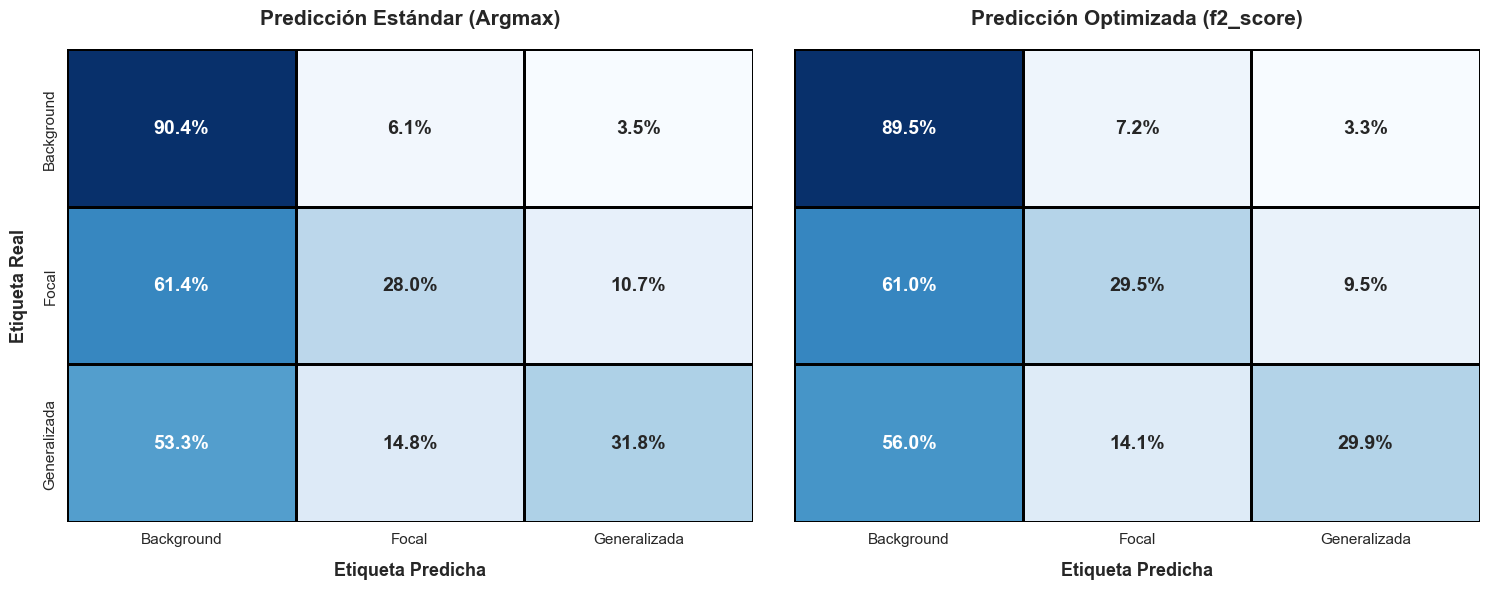

In [126]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_depth5_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "XGB_Depth5_NoPCA",
    metric_type = 'f2_score'
)

Al contrastar estos resultados con la matriz de confusión optimizada bajo el Índice $G$, se evidencia una capacidad superior para rescatar periodos ictales que el criterio de $F_2$ no lograba capturar. Esta configuración reduce de manera mucho más agresiva la tasa de falsos negativos, logrando disminuir la omisión de crisis focales ($\Delta = -18.5 \%$) y de crisis generalizadas ($\Delta = -20.8 \%$). Aunque este ajuste implica una pérdida de especificidad en la clase basal más pronunciada ($\Delta = -11.0 \%$), el beneficio clínico es notable al priorizar la detección de eventos críticos que antes pasaban desapercibidos. 

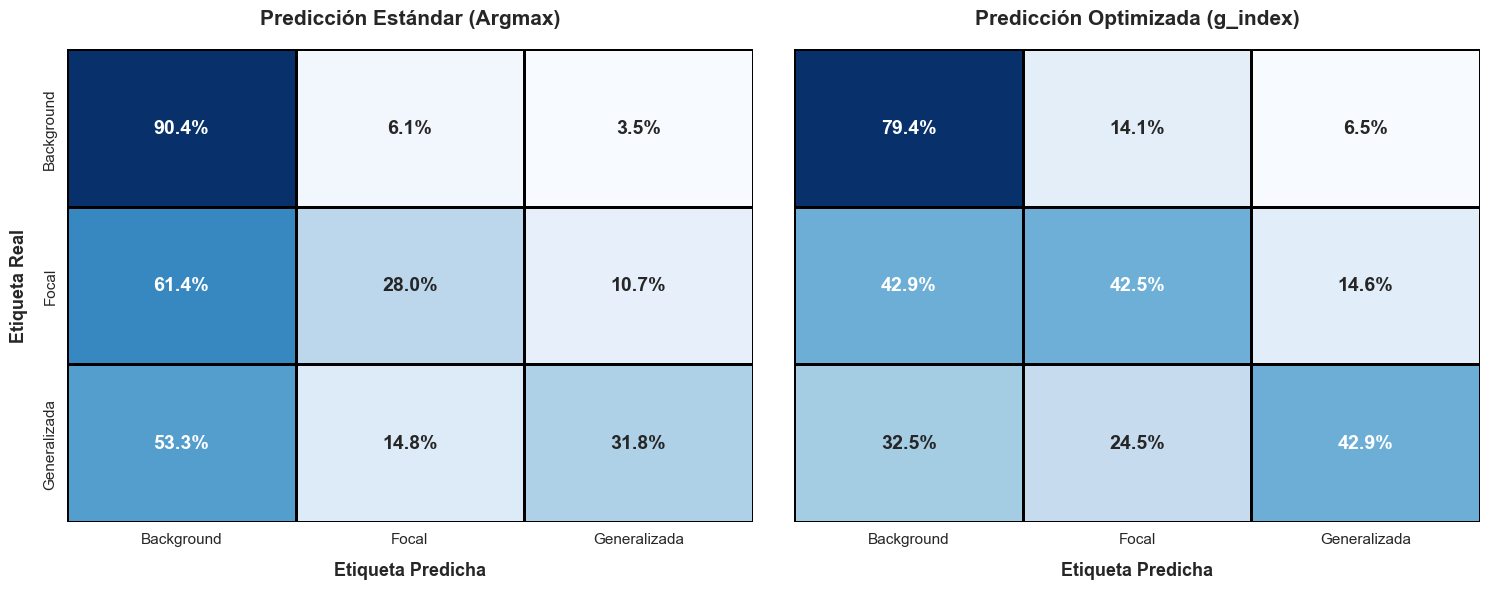

In [59]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_depth5_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "XGB_Depth5_NoPCA",
    metric_type = 'g_index'
)

En conclusión, el ajuste de los umbrales a partir del Índice G resulta mandatorio para que el sistema cumpla con su función de tamizaje (*screening*). Es importante notar que, si bien el XGBoost exhibe un desempeño general ligeramente superior a los modelos previos, su tasa de falsos negativos es mayor a la obtenida con la Regresión Logística o el KNN, lo que sugiere que su ventaja reside fundamentalmente en una mayor capacidad intrínseca para discriminar entre periodos con y sin crisis.

Al priorizar la recuperación de eventos críticos sobre la especificidad basal, esta configuración garantiza que el clasificador actúe como una red de seguridad efectiva, minimizando la omisión de crisis y proporcionando un insumo de alta sensibilidad para la validación clínica posterior. De este modo, se logra un equilibrio donde la potencia discriminativa del modelo se alinea con la necesidad crítica de no perder información vital durante el monitoreo neurológico continuo.

Para finalizar el estudio del rendimiento del XGBoost, a continuación se presentan los índices de ajuste del modelo bajo el umbral seleccionado, consolidando su caracterización operativa definitiva:

In [62]:
display_model_summary(
    df_train = eval_memory['prob_depth3_train'], 
    df_test = eval_memory['prob_depth3_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "XGB_Depth3_NoPCA", 
    scorer = scorer, 
    metric_opt = 'g_index',
    overfit_threshold = 0.1
)

Métrica,Entrenamiento,Prueba,Diferencia
Accuracy,0.798,0.731,0.067
Precision,0.614,0.393,0.220†
Recall,0.761,0.548,0.213†
Specificity,0.877,0.796,0.082
G-Index,0.760,0.531,0.228†
F1-Score,0.662,0.395,0.267†
F2-Score,0.712,0.441,0.271†
ROC-AUC,0.906,0.776,0.130†
PR-AUC,0.771,0.403,0.368†


El análisis de los índices de desempeño revela un clasificador con un comportamiento dual donde la Exactitud y la Especificidad muestran una estabilidad notable en la muestra de prueba ($\Delta < 0.1$), mientras que métricas críticas para la detección como la Sensibilidad ($\Delta = 0.213$) y el Índice G ($\Delta = 0.228$) exhiben brechas de generalización que sugieren una alta sensibilidad a la variabilidad de los eventos ictales en registros no observados. Pese al descenso en la precisión y el PR-AUC, el mantenimiento de un ROC-AUC de 0.776 valida la potencia discriminativa del sistema, consolidando un modelo que, bajo el umbral del Índice G, prioriza la seguridad clínica al actuar como un filtro de alta sensibilidad que minimiza la omisión de crisis, cumpliendo así con las exigencias operativas de una herramienta de tamizaje para el monitoreo neurológico continuo.

## SVM

Como componente final del análisis de clasificadores individuales, se integra el algoritmo de Máquinas de Vectores de Soporte (SVM) para evaluar la separabilidad de las clases mediante la construcción de hiperplanos óptimos en espacios de alta dimensionalidad. Tras haber explorado la robustez de los modelos logísticos, la sensibilidad geométrica del k-NN y la capacidad jerárquica de los algoritmos basados en árboles, incluyendo aproximaciones de *bagging* y *boosting*, el SVM se posiciona como el último benchmark del estudio antes de la transición hacia la arquitectura de ensamble propuesta para el pipeline.

A diferencia de los enfoques previos, este modelo busca maximizar el margen de separación entre estados clínicos, ofreciendo una estructura matemática rigurosa para capturar la variabilidad de las señales EEG mediante funciones kernel. Siguiendo la metodología establecida, el análisis se enfoca en evaluar la efectividad de diversas estrategias de sobremuestreo (*oversampling*), permitiendo identificar si la proyección a espacios de mayor complejidad mejora la resolución de los eventos ictales en el corpus TUSZ.


:::{admonition} Nota Metodológica: Escalabilidad y Restricciones en SVM

:class: note

A diferencia de los modelos basados en árboles o el KNN, las Máquinas de Vectores de Soporte (SVM) presentan una carga computacional significativamente mayor. La complejidad asintótica del entrenamiento de un SVM es típicamente de $O(n_{samples}^2 \cdot n_{features})$ para kernels no lineales, lo que implica que el tiempo de ejecución crece de forma cuadrática respecto al número de muestras. Dado el volumen de datos por pliegue en el corpus TUSZ, este escalado se vuelve prohibitivo para arquitecturas CPU convencionales.

Para mitigar este cuello de botella, el presente estudio utiliza una infraestructura de aceleración basada en GPU NVIDIA L4 y la librería RAPIDS cuML, permitiendo la paralelización del motor *Sequential Minimal Optimization* (SMO). No obstante, es imperativo señalar una restricción técnica importante: mientras que la implementación de Scikit-Learn permite el uso de pesos de clase (*class weights*), la implementación acelerada de cuML para problemas multiclase aún no soporta la ponderación de muestras. En consecuencia, y para mantener la coherencia en la comparativa de rendimiento bajo aceleración por hardware, no se emplean pesos analíticos en este bloque. En su lugar, el modelo se sustenta en las estrategias de sobremuestreo (*oversampling*) para resolver la separabilidad de los estados clínicos en el espacio de Hilbert inducido por los kernels.
:::

In [ ]:
modelo_svc = get_model('svc', use_gpu=True, probability=False, random_state=42)

espacios_de_busqueda_svc = {
    'grid': [
        {
            'pca__n_components': [None, 100, 200, 500],
            'clf__kernel': ['linear'],
            'clf__C': [0.1, 1.0, 10.0],
            'balancing': ['none', 'SMOTE', 'ADASYN']
        },
        {
            'pca__n_components': [None, 100, 200, 500],
            'clf__kernel': ['rbf'],
            'clf__C': [0.1, 1.0, 10.0],
            'clf__gamma': ['scale', 'auto', 0.1, 0.5],
            'balancing': ['none', 'SMOTE', 'ADASYN']
        },
        {
            'pca__n_components': [None, 100, 200, 500],
            'clf__kernel': ['poly'],
            'clf__C': [0.1, 1.0, 10.0],
            'clf__degree': [2, 3],
            'clf__coef0': [0.0, 1.0, 0.5],
            'clf__gamma': ['scale', 'auto'],
            'balancing': ['none', 'SMOTE', 'ADASYN']
        }
    ]
}


trainer_svc = Trainer(df_map=df_map_fold, train_set_paths=train_set_paths, estimator=modelo_svc,
    scoring_func=metrica_optimizacion, secondary_scoring_funcs=metricas_secundarias, feature_cols=FEATURE_COLS_CLEAN,
    target_col=TARGET_COL, label_mapping=LABEL_MAPPING)

dict_tablas, df_bench, dict_conv = trainer_svc.fit(methods=['grid'], spaces=espacios_de_busqueda_svc,
        samples_per_fold=40000, scaler_type='quantile_uniform', seed=42, checkpoint_dir=checkpoint_path,
        checkpoint_level='balancing')

In [63]:
RESULTS_PATH = ROOT_DIR / "results" / "svc" / "svc_balancing_results.csv"

if RESULTS_PATH.exists():
    df_svc_results = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

La evaluación descriptiva de las métricas $F_2$ para el clasificador SVM reveló variaciones significativas en función de la estrategia de balanceo aplicada, manteniendo una jerarquía de desempeño que subraya la complejidad del corpus TUSZ. El clasificador base registró el desempeño más deficiente ($F_2 \approx 0.481$), lo que evidencia que la simple maximización del margen de separación resulta insuficiente ante la predominancia de la clase basal. Por su parte, la implementación de ADASYN mostró una recuperación notable en la representatividad de los eventos de crisis ($F_2 \approx 0.547$), aunque fue superada de manera sistemática por SMOTE, técnica que alcanzó los valores de eficacia más altos en el espectro evaluado ($F_2 \approx 0.560$). Esta diferencia sugiere que, para la geometría del espacio de características del SVM, la generación sintética mediante interpolación lineal resulta más efectiva que la estrategia basada en la densidad local.

In [65]:
display_balancing_comparison(df_svc_results, metric='F2', sort_by='SMOTE', rename_cols = {'kernel': 'Kernel',
    'gamma': 'Gamma','n_components': 'PCA', 'degree' : 'Grado', 'coef0' : 'Sesgo'})

C,Kernel,PCA,Gamma,Sesgo,Grado,none,SMOTE,ADASYN
10.0,poly,None,auto,0.5,3.0,0.486 ± 0.035,0.562 ± 0.034,0.554 ± 0.029
0.1,poly,None,scale,1.0,2.0,0.477 ± 0.032,0.560 ± 0.034,0.545 ± 0.027
0.1,poly,None,scale,0.5,2.0,0.477 ± 0.033,0.559 ± 0.034,0.545 ± 0.027
0.1,poly,None,scale,0.0,2.0,0.475 ± 0.032,0.559 ± 0.034,0.545 ± 0.028
10.0,poly,500,auto,0.5,2.0,0.492 ± 0.036,0.558 ± 0.033,0.547 ± 0.031


Con el propósito de validar estadísticamente las hipótesis derivadas del análisis descriptivo, se ejecutó una prueba ómnibus de Kruskal-Wallis ($H = 131.107$; $p < 0.001$), la cual confirmó un efecto global significativo del método de balanceo sobre el rendimiento del modelo ($\varepsilon^2 = 0.212$). La prueba de Brown-Forsythe reveló la presencia de heterocedasticidad significativa entre los grupos ($p < 0.001$), indicando que las estrategias de balanceo alteran la consistencia del clasificador SVM. 

Tras confirmar estas diferencias, el análisis post-hoc de Wilcoxon ratificó la superioridad de SMOTE frente al modelo base ($r = 0.516$). No obstante, al contrastar SMOTE con ADASYN, si bien se alcanzó significancia estadística ($p = 0.028$), la magnitud del efecto resultó despreciable en términos prácticos ($r = 0.109$). Este hallazgo sugiere que, ante una paridad técnica tan estrecha en la métrica $F_2$, la selección de la estrategia óptima no debe basarse únicamente en el rendimiento nominal, sino que requiere un análisis complementario del Índice G para evaluar el equilibrio real de la sensibilidad y la robustez clínica del modelo.

In [66]:
df_clean = df_svc_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})
tabla_posthoc(df_clean, metric_col='primary_center')

Al desplazar el foco hacia el Índice G, se observa que la distinción entre las estrategias de sobremuestreo se vuelve prácticamente infinitesimal, sugiriendo un techo en la capacidad de recuperación de la sensibilidad balanceada para la arquitectura SVM. Mientras que el modelo base presenta una deficiencia marcada en la equidad predictiva ($ G \approx 0.274$), tanto SMOTE como ADASYN logran estabilizar el Índice G en rangos superiores, alcanzando valores máximos de $0.553$ y $0.554$ respectivamente. La paridad entre ambas técnicas es casi absoluta, con diferencias que no superan las tres milésimas en los promedios de las configuraciones más competitivas ($\Delta < 0.003$).

In [68]:
display_balancing_comparison(df_svc_results, metric='G', sort_by='SMOTE', rename_cols = {'kernel': 'Kernel',
    'gamma': 'Gamma','n_components': 'PCA', 'degree' : 'Grado','coef0' : 'Sesgo'})

C,Kernel,PCA,Gamma,Sesgo,Grado,none,SMOTE,ADASYN
0.1,poly,100,scale,1.0,2.0,0.277 ± 0.053,0.553 ± 0.044,0.549 ± 0.024
0.1,poly,100,scale,0.5,2.0,0.260 ± 0.053,0.552 ± 0.044,0.548 ± 0.025
0.1,poly,200,scale,0.5,2.0,0.258 ± 0.050,0.550 ± 0.051,0.554 ± 0.031
10.0,poly,None,auto,0.0,3.0,0.256 ± 0.042,0.549 ± 0.057,0.545 ± 0.046
10.0,poly,None,auto,0.0,2.0,0.317 ± 0.052,0.548 ± 0.055,0.545 ± 0.042


La validación estadística del Índice G replicó la tendencia observada en la métrica $F_2$, donde la prueba ómnibus de Kruskal-Wallis confirmó un efecto global significativo del método de balanceo ($H = 225.968$; $p < 0.001$) con una magnitud del efecto grande ($\varepsilon^2 = 0.368$). No obstante, el análisis post-hoc mediante pruebas U de Wilcoxon reveló que la distinción entre ADASYN y SMOTE carece de significancia estadística ($p = 0.335$) y presenta un tamaño del efecto nulo ($r = 0.048$). Este hallazgo demuestra que, en términos de equidad predictiva, ambos métodos han alcanzado un techo de rendimiento idéntico para el clasificador SVM, reforzando que la superioridad marginal de SMOTE en el $F_2$ no se traduce en una ventaja competitiva real al evaluar la sensibilidad balanceada.

In [69]:
tabla_posthoc(df_clean, metric_col='g_index_center')

Dada esta paridad técnica, la selección de la estrategia óptima se fundamenta en los principios de parsimonia y economía computacional, consolidando a SMOTE como la técnica predilecta. Al ofrecer una recuperación de eventos equivalente a la de ADASYN, pero con un mecanismo de interpolación lineal más eficiente y menos propenso a la dispersión de ruido en las fronteras de decisión del espacio de Hilbert, SMOTE garantiza una mayor estabilidad operativa sin incrementar la complejidad del preprocesamiento.


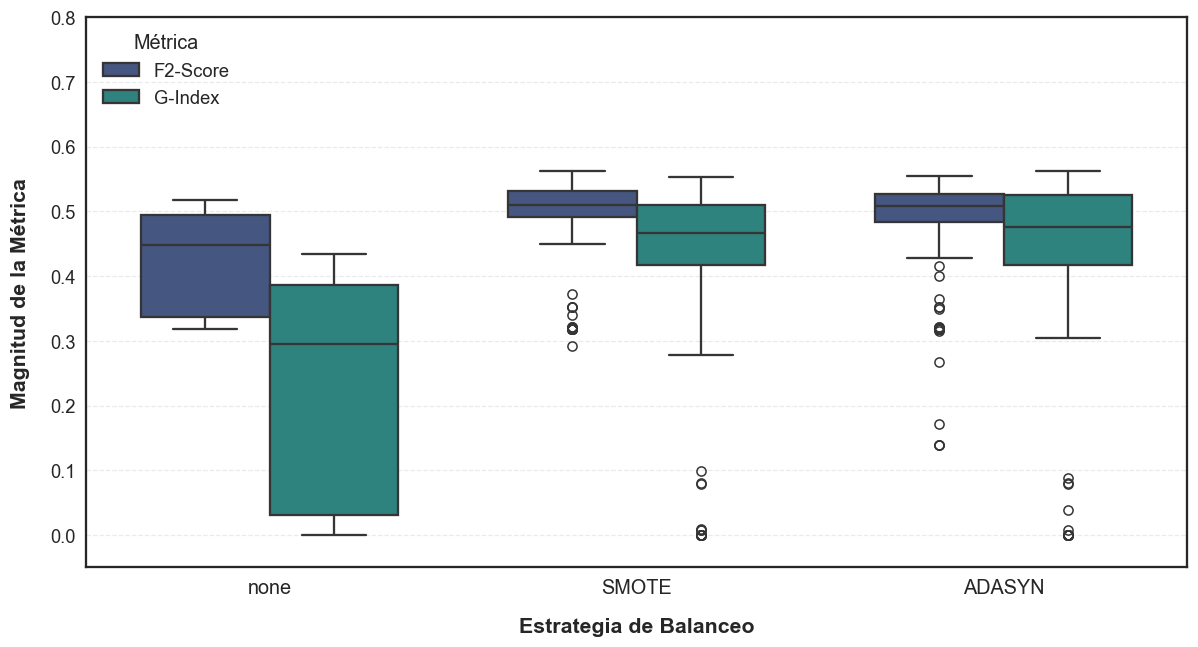

In [72]:
plot_balancing_comparison_dual(df=df_svc_results, metric_cols=['primary_center', 'g_index_center'],
    metric_labels=['F2-Score', 'G-Index'], y_lim=(-0.05, 0.8))

Al analizar la dinámica de optimización para el clasificador SVM, se observa que, si bien el método Grid Search logró identificar el punto de desempeño más alto del experimento ($F_2 = 0.517$), su implementación resultó en una ineficiencia operativa crítica. La complejidad del entrenamiento de este algoritmo bajo una exploración exhaustiva representa un costo-beneficio desfavorable frente a alternativas dirigidas que priorizan la convergencia hacia regiones de alto rendimiento.

En contraste, el optimizador Optuna demostró una superioridad técnica contundente al localizar un máximo altamente competitivo ($F_2 = 0.508$) con una reducción drástica del tiempo total ($\Delta = -90.7\%$). Al analizar la eficacia operativa, la búsqueda bayesiana resultó ser el doble de costosa por unidad de evaluación que el método exhaustivo ($14.31$ s/eval frente a $6.26$ s/eval); no obstante, su capacidad para explorar estratégicamente el espacio de hiperparámetros permitió alcanzar la convergencia con una fracción mínima de ensayos. Por el contrario, algoritmos como DEAP requirieron una inversión temporal considerable sin lograr resultados superiores, consolidando a Optuna como la herramienta de elección para este pipeline de neuroingeniería.

In [77]:
RESULTS_PATH = ROOT_DIR / "results" / "svc" / "optimization_results" / "svc_benchmark_summary.csv"

if RESULTS_PATH.exists():
    df_bench = pd.read_csv(RESULTS_PATH)
else:
    print(f"Error: No se detectó el archivo de resultados en {RESULTS_PATH}")

optuna_path = ROOT_DIR / "results" / "svc" / "optimization_results" / "svc_optuna_details.csv"

if optuna_path.exists():
    df_optuna = pd.read_csv(optuna_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {optuna_path}")

grid_path = ROOT_DIR / "results" / "svc" / "optimization_results" / "svc_grid_details.csv"

if grid_path.exists():
    df_grid = pd.read_csv(grid_path)
else:
    print(f"Error: No se detectó el archivo de resultados en {grid_path}")

In [71]:
df_bench = df_bench.rename(columns={'execution_time_sec': 'execution_time_sec','best_score_center': 'best_score'})
columnas_requeridas = ['optimization_method', 'execution_time_sec', 'total_evaluations', 'best_score', 'early_stopped']
df_bench = df_bench[columnas_requeridas]
display_optimization_benchmark(df_bench)

Método de Optimización,Tiempo,Evaluaciones Totales,Mejor Score (F2),Convergencia
Grid Search,11:07:46,6400,0.517,---
Búsqueda Aleatoria,02:40:56,400,0.508,---
Optuna,01:02:00,260,0.508,Sí
DEAP,01:24:11,400,0.473,No


Al analizar los resultados de la búsqueda exhaustiva para el SVM, se observa que las configuraciones de mayor rendimiento requirieron el uso de 800 componentes de PCA, el límite máximo permitido en la exploración. Es relevante destacar que esta configuración se prefirió sobre la opción de prescindir totalmente de la reducción de dimensionalidad, lo que implica que existe una ganancia técnica al aplicar un filtrado de ruido controlado antes de la construcción del hiperplano.

El modelo óptimo alcanzó un $F_2$-Score de 0.517, consolidado mediante una transformación polinómica de bajo grado y un término de sesgo moderado. Esta convergencia indica que el éxito del clasificador radica en su capacidad para mapear las señales hacia espacios de mayor complejidad donde las fronteras no lineales se vuelven separables, logrando un compromiso técnico que estabiliza el desempeño del Índice G ($0.489$). De este modo, el uso del máximo de componentes permitidos actúa como un balance necesario entre la integridad de los datos y la separabilidad de las crisis en el espacio de Hilbert.

In [82]:
names = {'kernel': 'Kernel', 'gamma': 'Gamma','n_components': 'PCA', 'degree' : 'Grado','coef0' : 'Sesgo',
         'primary': 'F2', 'f1_score': 'F1', 'g_index': 'Índice G'}
display_detailed_metrics(df_grid, sort_by='F2', rename_cols = names)

C,Kernel,PCA,Gamma,Sesgo,Grado,F2,F1,Índice G
0.1,poly,800,0.01,1,2,0.517 ± 0.044,0.501 ± 0.037,0.489 ± 0.067
0.1,poly,800,0.01,0.5,2,0.516 ± 0.058,0.486 ± 0.051,0.503 ± 0.099
0.1,poly,800,0.1,1,2,0.508 ± 0.048,0.507 ± 0.050,0.465 ± 0.076
100,poly,800,0.1,1,2,0.507 ± 0.055,0.511 ± 0.055,0.460 ± 0.082
0.1,rbf,600,auto,---,---,0.504 ± 0.061,0.460 ± 0.059,0.476 ± 0.058


Al analizar los resultados obtenidos mediante Optuna, se observa una divergencia clara respecto a la configuración identificada por el método exhaustivo, confirmando que ambas estrategias no convergieron hacia el mismo punto del espacio de hiperparámetros. Mientras que el Grid Search priorizó una mayor dimensionalidad, la optimización bayesiana localizó su mejor rendimiento ($F_2 = 0.508$) utilizando 600 componentes de PCA, lo que sugiere el hallazgo de un balance más eficiente al mitigar el ruido mediante una reducción más agresiva. Esta configuración compensa la menor cantidad de características con una estructura de modelo más compleja, caracterizada por la transición hacia un kernel polinómico de tercer grado y una penalización de error considerablemente más estricta. No obstante, este enfoque orientado a la maximización de la métrica objetivo resultó en un Índice G inferior ($\Delta = -0.047$), indicando que la búsqueda estratégica de Optuna favoreció la resolución de la clase positiva a costa de una ligera pérdida en la equidad predictiva global.

In [83]:
names = {'kernel': 'Kernel', 'gamma': 'Gamma','n_components': 'PCA', 'degree' : 'Grado','coef0' : 'Sesgo',
         'primary': 'F2', 'f1_score': 'F1', 'g_index': 'Índice G'}
display_detailed_metrics(df_optuna, sort_by='F2', rename_cols = names)

PCA,Kernel,C,Gamma,Grado,Sesgo,F2,F1,Índice G
600,poly,8.17552,0.0183194,3,1.00982,0.508 ± 0.048,0.505 ± 0.046,0.442 ± 0.086
600,poly,13.9969,0.0353714,2,0.0731783,0.500 ± 0.037,0.506 ± 0.037,0.420 ± 0.055
600,poly,7.81993,0.0192079,3,1.0977,0.496 ± 0.054,0.492 ± 0.054,0.447 ± 0.084
600,poly,7.5823,0.0224069,3,1.07316,0.490 ± 0.029,0.491 ± 0.029,0.418 ± 0.048
600,poly,1.09854,0.0594242,3,4.65404,0.484 ± 0.045,0.477 ± 0.046,0.417 ± 0.078


Las búsquedas iniciales en la muestra de entrenamiento revelaron métricas levemente inferiores a las de todos los clasificadores comprobados hasta el momento. No obstante, este comportamiento preliminar motivó una investigación más profunda sobre la capacidad de generalización del SVM, asumiendo que su margen de decisión basado en vectores de soporte podría ofrecer una estabilidad superior en datos no observados. Con el objetivo de refinar este análisis, se procedió a evaluar las dos configuraciones con mejor desempeño, identificadas mediante Grid Search y Optuna, en la muestra de prueba independiente, permitiendo contrastar si la complejidad del kernel polinomial compensa la brecha de rendimiento inicial frente a modelos más directos.

In [ ]:
modelo_svc = get_model('svc', use_gpu=True, probability=True, random_state=42, max_iter=5000, tol=1e-3, cache_size=8000)

configs_svc = [
    {
        "name": "SVM_Poly2_PCA800",
        "params": {
            'pca__n_components': 800,
            'model__kernel': 'poly',
            'model__C': 0.1,
            'model__gamma': 0.01,
            'model__degree': 2,
            'model__coef0': 1.0,
            'balancing': 'SMOTE'
        },
        "scaler": "robust"
    },
    {
        "name": "SVM_Poly3_PCA600",
        "params": {
            'pca__n_components': 600,
            'model__kernel': 'poly',
            'model__C': 8.17552,
            'model__gamma': 0.0183194,
            'model__degree': 3,
            'model__coef0': 1.00982,
            'balancing': 'SMOTE'
        },
        "scaler": "robust"
    }
]

resultados_svc = {}

for cfg in configs_svc:
    evaluator = Evaluator(train_set_paths=train_set_paths, test_set_paths=test_set_paths, estimator=modelo_svc,
        feature_cols=FEATURE_COLS_CLEAN, target_col=TARGET_COL, label_mapping=LABEL_MAPPING)

    evaluator.fit(best_params=cfg['params'], scaler_type=cfg['scaler'], samples_for_train=40000, 
                  export_path=f"models/{cfg['name']}.joblib")
    
    train_res = evaluator.get_full_probabilities(evaluator.train_set_paths, "Train Global")
    test_res = evaluator.get_full_probabilities(evaluator.test_set_paths, "Test Global")
    resultados_svc[cfg['name']] = {'thresholds': evaluator.best_thresholds_, 'train': train_res, 'test': test_res}

In [158]:
EVAL_PATH = ROOT_DIR / "results" / "svc" / "evaluation"

eval_memory = {}
load_eval_data(EVAL_PATH / "svc_thresholds.csv", "thresholds")

evaluation_files = [
    ("prob_Poly2_train", "prob_SVM_Poly2_PCA800_train.csv"),
    ("prob_Poly2_test",  "prob_SVM_Poly2_PCA800_test.csv"),
    ("prob_Poly3_train", "prob_SVM_Poly3_PCA600_train.csv"),
    ("prob_Poly3_test",  "prob_SVM_Poly3_PCA600_test.csv")
]

for key, filename in evaluation_files:
    load_eval_data(EVAL_PATH / filename, key)

[CARGADO] thresholds                | Registros: 2
[CARGADO] prob_Poly2_train          | Registros: 862737
[CARGADO] prob_Poly2_test           | Registros: 370034
[CARGADO] prob_Poly3_train          | Registros: 862737
[CARGADO] prob_Poly3_test           | Registros: 370034


Al trasladar el análisis a la muestra de prueba independiente, los resultados confirman que el SVM presenta una capacidad discriminativa sustancialmente inferior a la observada en los clasificadores evaluados previamente. Para la clase Background, los valores de AUC se sitúan en un rango significativamente más bajo lo que indica una proximidad preocupante a la línea de no discriminación estadística.

Asimismo, se observa que la diferencia de rendimiento entre ambas configuraciones polinomiales es ligera ($\Delta \text{AUC} = 0.016$), lo que sugiere que el incremento en la complejidad del hiperplano no logra capturar de manera efectiva la estructura no lineal de las señales EEG en este espacio de características. Estos hallazgos plantean que, a pesar de su robustez teórica, el SVM con kernels polinomiales parece ser insuficiente para manejar la alta variabilidad y el solapamiento de clases inherentes al corpus TUSZ, posicionándose como el modelo con menor utilidad operativa hasta el momento.


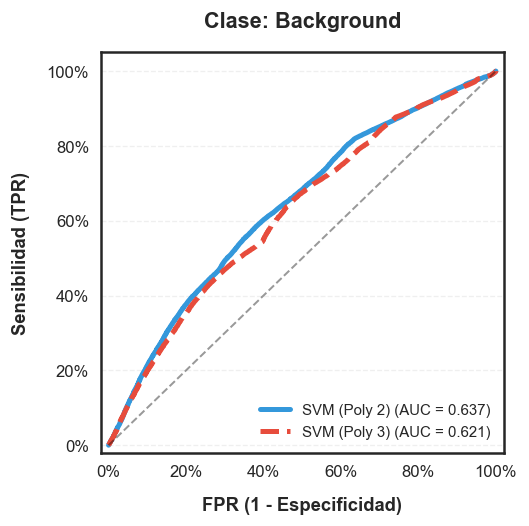

In [159]:
plot_roc_comparison(
    df_m1=eval_memory['prob_Poly2_test'], 
    df_m2=eval_memory['prob_Poly3_test'], 
    name_m1='SVM (Poly 2)', 
    name_m2='SVM (Poly 3)', 
    focus_class=[0], 
    figsize=(4.5, 4.5), legend_size=9
)

Este comportamiento se replica de manera consistente en las categorías Focal y Generalizada, donde el SVM exhibe una capacidad discriminativa muy limitada y transversal a todos los tipos de crisis. En la clase Focal, el rendimiento se estanca en niveles críticos, mientras que en la categoría Generalizada el modelo apenas logra separarse del umbral de clasificación aleatoria. La disparidad entre ambas configuraciones polinomiales resulta insignificante ($\Delta \text{AUC} = 0.016$ y $\Delta \text{AUC} = 0.019$, respectivamente), lo que indica que ni el ajuste del grado del núcleo ni la variación en los componentes de PCA logran mitigar la severa confusión entre los patrones ictal y basal en este modelo.


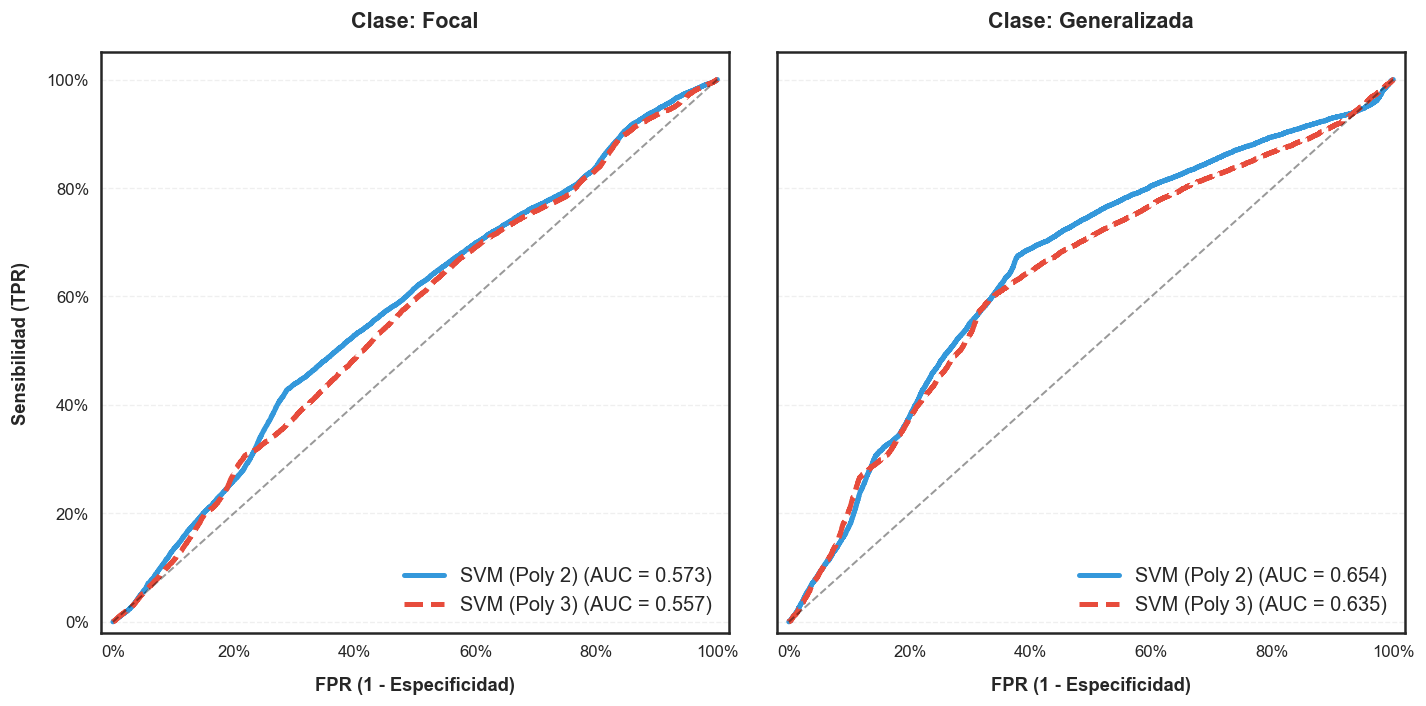

In [160]:
plot_roc_comparison(
    df_m1=eval_memory['prob_Poly2_test'], 
    df_m2=eval_memory['prob_Poly3_test'], 
    name_m1='SVM (Poly 2)', 
    name_m2='SVM (Poly 3)', 
    focus_class=[1, 2], 
    figsize=(12, 6), legend_size=12
)

La formalización estadística mediante el test de DeLong indica que, si bien existen diferencias a favor del núcleo polinomial de grado 2 en términos de capacidad discriminativa, estas variaciones absolutas son marginales en las categorías evaluadas. Al contrastar estos resultados con el desempeño clínico, la prueba estadística respalda las observaciones previas derivadas de las curvas ROC: el incremento en la complejidad estructural de los estimadores no se traduce en una ventaja operativa clara en ninguna de las clases de crisis. Por tanto, se prioriza la arquitectura de menor complejidad identificada por el espacio de búsqueda, reduciendo el riesgo de sobreajuste y garantizando una mayor estabilidad computacional en la discriminación de la actividad ictal frente a la basal.

In [161]:
compare_models_DeLong( df_m1=eval_memory['prob_Poly2_test'], df_m2=eval_memory['prob_Poly3_test'], 
    rename_cols={'Modelo 1': 'SVM (Poly 2)', 'Modelo 2': 'SVM (Poly 3)'}, n_boot=1000)

Clase,SVM (Poly 2),SVM (Poly 3),Diferencia,SE,Z,p,LB,UB
Background,0.637,0.621,0.016,0.0012,13.586,<0.001***,0.013,0.018
Focal,0.573,0.557,0.016,0.0019,8.147,<0.001***,0.012,0.020
Generalizada,0.654,0.635,0.019,0.0019,10.263,<0.001***,0.016,0.023


Tras seleccionar la arquitectura de mayor parsimonia, se procede a calibrar los umbrales de decisión para la clasificación multiclase. Al comparar los resultados de la calibración, se observa que, a diferencia de las marcadas discrepancias registradas en otros modelos, tanto el $F_2$-Score como el Índice $G$ convergen en valores de rendimiento sumamente cercanos y estables a lo largo del proceso de optimización. No obstante, dado que incluso sutiles ajustes en los umbrales pueden alterar la distribución interna de los errores del sistema, se procede a analizar las matrices de confusión para cada configuración, con el fin de determinar cuál de los criterios se alinea mejor con los objetivos de detección del proyecto.

In [176]:
display_clinical_results(
    df_prob = eval_memory['prob_Poly2_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = 'SVM_Poly2_PCA800'
)

Configuración,F2-Score (max),G-Index (max),Tau Focal,Tau Gen
Optimizado para F2,0.3176,0.4139,0.4402,0.5437
Optimizado para G-Index,0.2975,0.4230,0.3825,0.4664


El análisis de la matriz de confusión derivada del umbral $F_2$ confirma el rendimiento deficiente de esta configuración dentro del espectro experimental. La evaluación macro del mapa de clasificación evidencia que la proporción de segmentos correctamente asignados a sus clases respectivas es críticamente baja, reflejando una incapacidad estructural para aislar los patrones patológicos. Lejos de optimizar la sensibilidad diagnóstica, la calibración basada en el criterio $F_2$ acentúa el colapso predictivo del sistema al incrementar la tasa de falsos negativos ($\Delta = +8.9 \%$ para la crisis focales y $\Delta= +11.6 \%$ para las generalizadas), donde la mayoría de los eventos de crisis se confunden de forma sistemática con el fondo electroencefalográfico basal. Este comportamiento demuestra que la modificación del umbral bajo esta métrica resulta contraproducente para el estimador, comprometiendo la viabilidad operativa del modelo para la detección de actividad ictal en el corpus TUSZ.

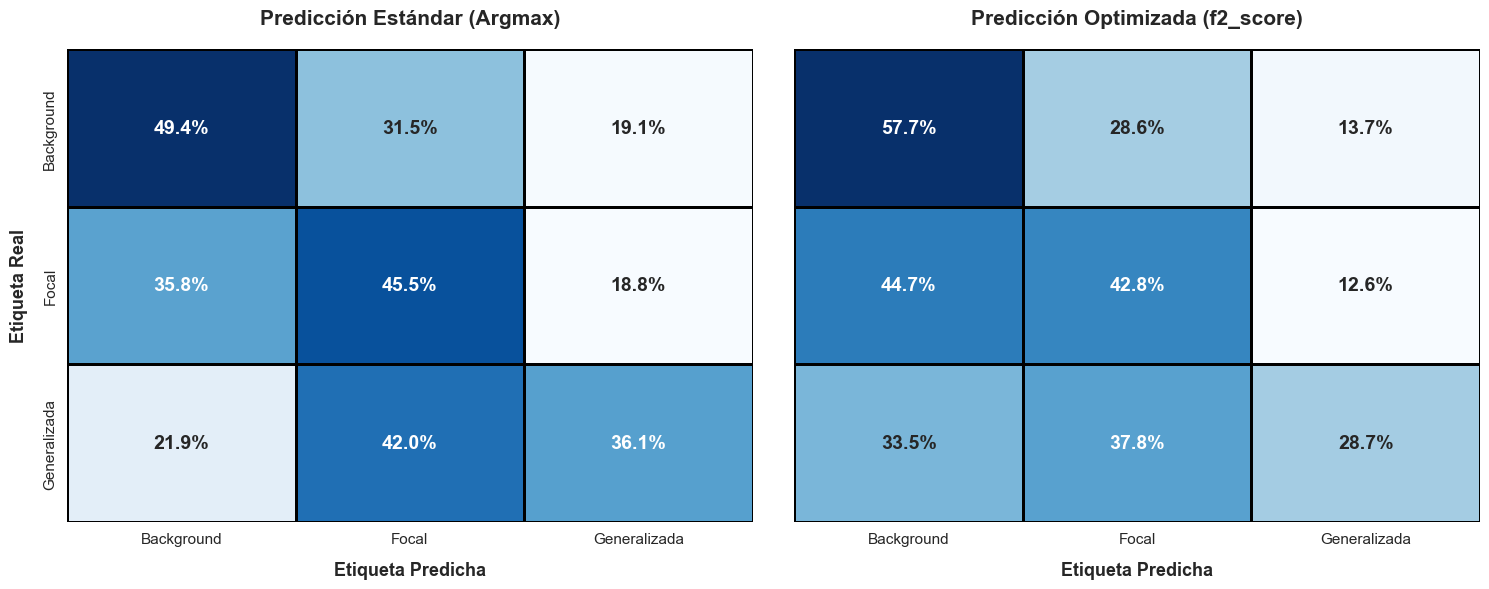

In [177]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_Poly2_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "SVM_Poly2_PCA800",
    metric_type = 'f2_score'
)

Esta tendencia al incremento de los falsos negativos y a la degradación del rendimiento a nivel de paciente se observó de manera consistente al emplear el umbral calibrado mediante el Índice $G$. El análisis de la matriz de confusión correspondiente revela que la proporción de clasificaciones correctas se mantiene en niveles mínimos para ambas clases de crisis. Al igual que con el criterio $F_2$, la evaluación a nivel de paciente bajo el Índice $G$ propicia una alta omisión de eventos focales y generalizados, los cuales son asignados erróneamente al estado basal. Este comportamiento confirma que ambas estrategias de calibración de umbrales reproducen el mismo patrón de error, consolidando una elevada tasa de falsos negativos que limita la utilidad práctica del clasificador en este escenario.

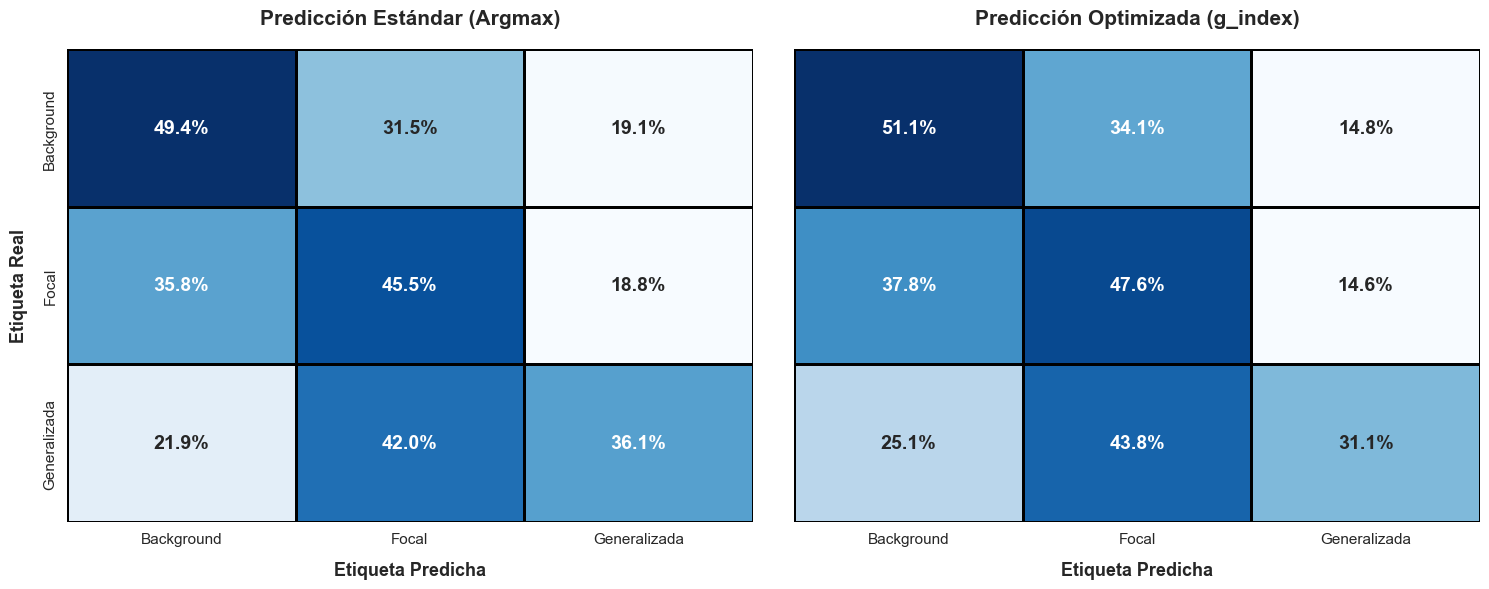

In [178]:
plot_confusion_comparison(
    df_prob = eval_memory['prob_Poly2_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "SVM_Poly2_PCA800",
    metric_type = 'g_index'
)

or consiguiente, priorizando la seguridad de los pacientes y con el objetivo de mitigar el riesgo clínico asociado a la omisión de crisis, se descarta el desplazamiento manual de las fronteras de decisión y se decide mantener la estrategia de umbrales por defecto de la arquitectura. Con esta determinación operativa, concluye la fase de calibración y se culmina la sección presentando las métricas de ajuste globales obtenidas por el modelo.

In [180]:
display_model_summary(
    df_train = eval_memory['prob_Poly2_train'], 
    df_test = eval_memory['prob_Poly2_test'], 
    df_thresholds = eval_memory['thresholds'], 
    model_name = "SVM_Poly2_PCA800", 
    scorer = scorer, 
    metric_opt = 'argmax',
    overfit_threshold = 0.1
)

Métrica,Entrenamiento,Prueba,Diferencia
Accuracy,0.584,0.585,0.001
Precision,0.400,0.351,0.049
Recall,0.462,0.423,0.039
Specificity,0.725,0.712,0.013
G-Index,0.448,0.406,0.042
F1-Score,0.399,0.304,0.095
F2-Score,0.424,0.322,0.103†
ROC-AUC,0.654,0.621,0.033
PR-AUC,0.388,0.348,0.040


La evaluación analítica de la tabla de rendimiento global para la máquina de soporte vectorial (SVM) revela un comportamiento diferenciado respecto a los modelos basados en árboles. A diferencia de las estructuras jerárquicas, el SVM muestra una alta consistencia entre las fases de entrenamiento y prueba, evidenciando una ausencia casi total de sobreajuste. No obstante, esta estabilidad operativa coincide con un techo de rendimiento limitado; métricas críticas para el contexto clínico, tales como la sensibilidad (*Recall*) y el área bajo la curva (AUC), registran valores sustancialmente menores a los alcanzados por las arquitecturas previas. Este patrón sugiere que, si bien el espacio de características regularizado por el SVM previene la degradación general del modelo en validación, la naturaleza del núcleo polinomial resulta insuficiente para separar con eficacia la complejidad transicional de las señales electroencefalográficas en el corpus TUSZ.

## Modelo Original

In [ ]:
# 1. Limpieza y preparación de datos
df_clean = df_xgboost_results.copy()
df_clean['balancing'] = df_clean['balancing'].replace({'weight_balanced': 'weight'})

# 2. Construcción de grupos (todas las categorías)
groups = []
labels = []

for name, group in df_clean.groupby('balancing'):
    values = group['primary_center'].dropna()
    if len(values) > 0:
        groups.append(values)
        labels.append(name)

# VALIDACIÓN: Verificar que haya al menos 2 grupos
if len(groups) < 2:
    print(f"Error: Grupos insuficientes. Total grupos válidos: {len(groups)}")
else:
    # 3. Prueba No Paramétrica (Kruskal-Wallis)
    stat_kw, p_val_kw = stats.kruskal(*groups)

    # 4. Medianas por grupo
    medianas = {label: group.median() for label, group in zip(labels, groups)}

    # 5. Tamaño del efecto (epsilon cuadrado)
    n = sum(len(g) for g in groups)
    k = len(groups)
    epsilon_sq = (stat_kw - k + 1) / (n - k)

    # 6. Prueba de Homocedasticidad (Brown-Forsythe)
    stat_bf, p_val_bf = stats.levene(*groups, center='median')

    # --- SALIDA DE RESULTADOS ---
    print(f"{' ANÁLISIS ESTADÍSTICO DE BALANCEO ':*^60}")
    print(f"Grupos analizados: {k} | Total muestras: {n}")
    print("-" * 60)

    print(f"MEDIANAS ($F_2$):")
    for label in labels:
        print(f"  > {label}: {medianas[label]:.4f} (n={len(df_clean[df_clean['balancing']==label])})")

    print("-" * 60)
    print(f"PRUEBA DE KRUSKAL-WALLIS:")
    print(f"  > Estadístico H: {stat_kw:.3f}")
    print(f"  > p-value:       {p_val_kw:.4e}")

    print("-" * 60)
    print(f"MAGNITUD DEL EFECTO (ε²):")
    print(f"  > epsilon²: {epsilon_sq:.3f} ", end="")

    if epsilon_sq < 0.01:
        print("(Muy pequeño)")
    elif epsilon_sq < 0.08:
        print("(Pequeño)")
    elif epsilon_sq < 0.26:
        print("(Mediano)")
    else:
        print("(Grande)")

    print("-" * 60)
    print(f"PRUEBA DE BROWN-FORSYTHE:")
    print(f"  > Estadístico:   {stat_bf:.3f}")
    print(f"  > p-value:       {p_val_bf:.4e}")
    print(f"  > Resultado:     {'Varianzas Iguales' if p_val_bf > 0.05 else 'Heterocedasticidad'}")

    print("-" * 60)
    print(f"INTERPRETACIÓN GLOBAL:")
    if p_val_kw < 0.05:
        print("  > Existen diferencias estadísticamente significativas entre los grupos.")
        print("  > Se recomienda realizar un análisis post-hoc (Dunn).")
    else:
        print("  > No se encontraron diferencias significativas entre los grupos.")

    print("*" * 60)

# Evaluación

In [225]:
# Mapeo de rutas de las predicciones
diccionario_predicciones = {
    "Logit": "results/logit/evaluation/prob_Logit_C1.0_NoPCA_test.csv",
    "KNN": "results/knn/evaluation/prob_KNN_K50_PCA25_Manhattan_test.csv",
    "GNB": "results/gnb/evaluation/prob_GNB_PCA25_Smooth_Low_test.csv",
    "RF": "results/randomForest/evaluation/prob_RF_NoPCA_Entropy_test.csv",
    "XGB": "results/xgboost/evaluation/prob_XGB_Depth3_NoPCA_test.csv",
    "SVM": "results/svc/evaluation/prob_SVM_Poly2_PCA800_test.csv",
}

# Configuración individual de umbrales por estimador
umbrales_dict = {
    "Logit": (0.4264, 0.3574),
    "KNN": 'argmax',
    "GNB": 'argmax',
    "RF": (0.4136, 0.3154),
    "XGB": (0.2967, 0.2524),
    "SVM": 'argmax'
}

metricas_clave = ['Accuracy','Precision','Recall', 'G-Index', 'F1-Score','F2-Score', 'ROC-AUC']

df_test_cross = summarize_performance(
    model_csv_paths=diccionario_predicciones,
    scorer=scorer,
    thresholds_dict=umbrales_dict,
    metrics_to_show=metricas_clave,
    sort_by='g_index', 
    decimals=3
)

Modelo,Accuracy,Precision,Recall,G-Index,F1-Score,F2-Score,ROC-AUC
Logit,0.663,0.381,0.539,0.531,0.360,0.403,0.752
KNN,0.621,0.376,0.530,0.525,0.345,0.384,0.729
GNB,0.639,0.394,0.558,0.554,0.373,0.416,0.754
RF,0.761,0.398,0.551,0.527,0.409,0.457,0.763
XGB,0.731,0.393,0.548,0.531,0.395,0.441,0.776
SVM,0.585,0.351,0.423,0.406,0.304,0.322,0.621



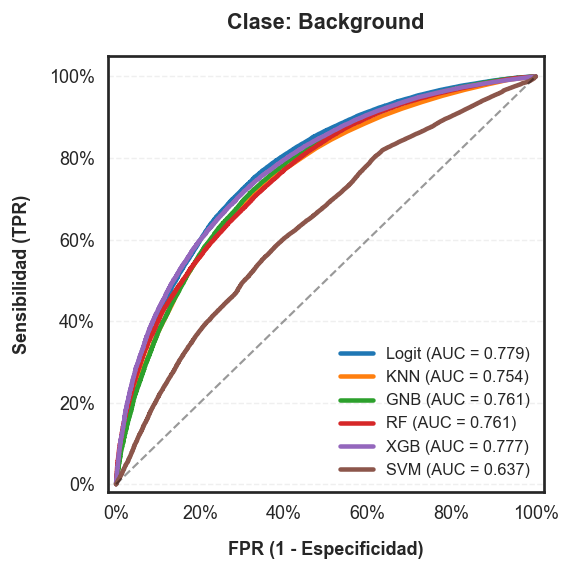

In [229]:
plot_roc_comparison(
    model_csv_paths=diccionario_predicciones,
    focus_class=[0],      
    label_mapping=LABEL_MAPPING, 
    legend_size=9,               
    figsize=(4.5, 4.5)          
)


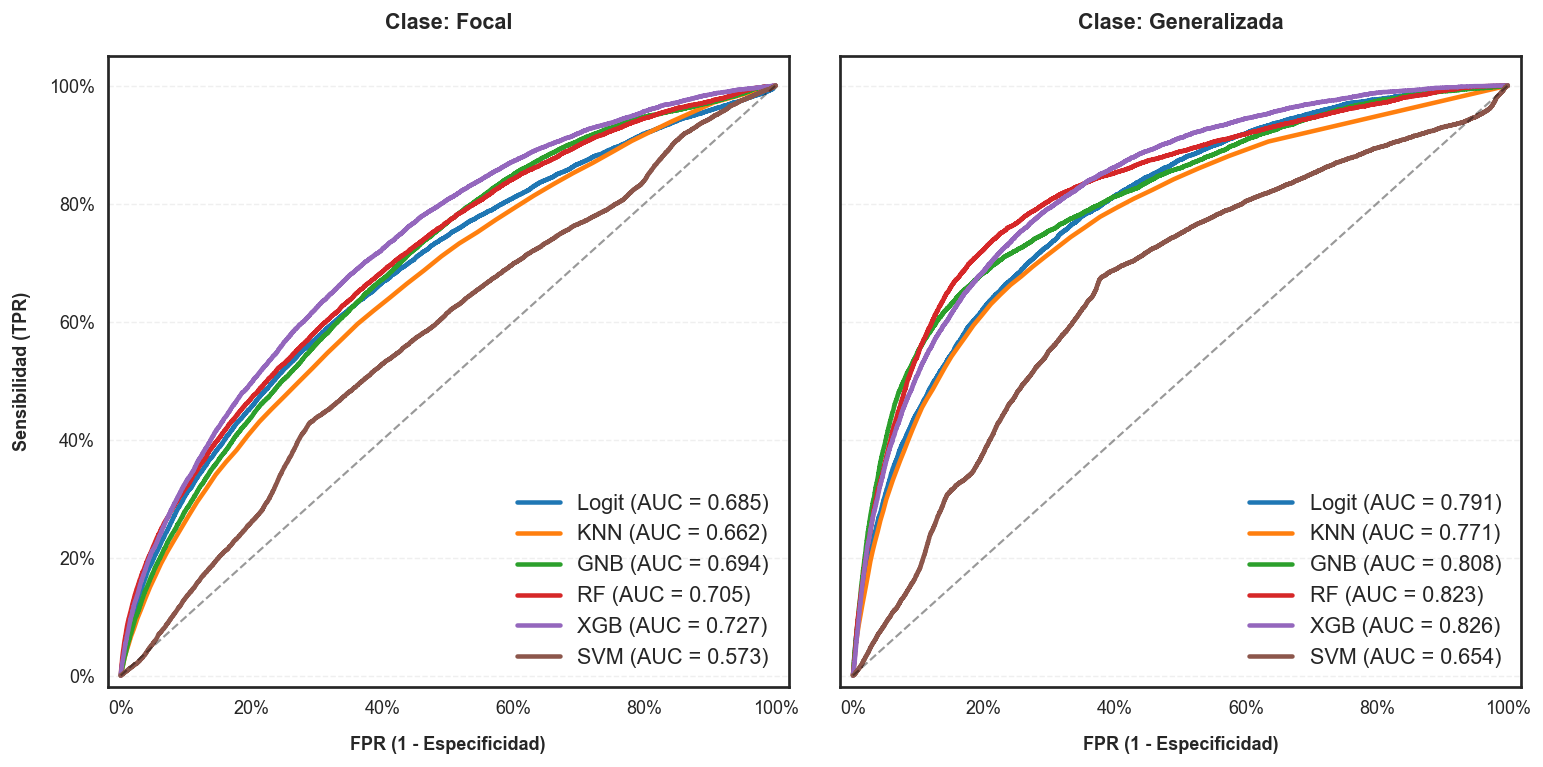

In [230]:
plot_roc_comparison(
    model_csv_paths=diccionario_predicciones,
    focus_class=[1,2],      
    label_mapping=LABEL_MAPPING, 
    figsize=(12, 6), legend_size=12        
)